# Determinants of Remittance Inflows to Sri Lanka: A Time Series Analysis (1994–2025)

**Course:** CS3121 Data Science &nbsp;|&nbsp; **Period:** January 1994 – December 2025 &nbsp;|&nbsp; **Observations:** 384 monthly records

---

## Abstract

This study investigates the macroeconomic and labour migration determinants of remittance inflows to Sri Lanka over a thirty-two-year period (1994–2025). Using 384 monthly observations sourced from the Central Bank of Sri Lanka, the Sri Lanka Bureau of Foreign Employment (SLBFE), and the World Bank, the analysis proceeds through four stages: (i) exploratory data analysis and descriptive statistics; (ii) time series econometrics, including stationarity testing, cointegration analysis, vector autoregression (VAR), and impulse response functions (IRFs); (iii) supervised and unsupervised machine learning; and (iv) short-horizon forecasting via SARIMA and gradient boosting. All correlation and regression analyses are conducted on first-differenced (stationary) series to preclude spurious inference. Structural breaks are tested formally at three historically motivated dates using the Chow test. The analysis finds evidence of cointegration among remittances, the exchange rate, oil prices, inflation, and per capita income, and identifies the USD/LKR exchange rate and oil price as significant short-run Granger-causes of remittance variation.

---

## Methodological Notes

| Enhancement | Rationale |
|---|---|
| Correlation analysis on first-differenced data | Removes spurious time-trend correlation present in non-stationary levels |
| Feature engineering from stationary + lagged series | Eliminates time-trend artefact in machine learning importance estimates |
| STL trend-adjusted shock windows | Ensures pre/post shock comparisons are not confounded by secular trend |
| Formal Johansen cointegration test prior to VAR/VECM selection | Satisfies the theoretical prerequisite for model choice |
| Forecast Error Variance Decomposition (FEVD) | Quantifies the relative contribution of each variable to forecast uncertainty at multiple horizons |
| Rolling 36-month correlation windows | Captures parameter non-constancy and time-varying relationships |
| Chow test at three structural break dates | Formally tests coefficient stability at the 2008 financial crisis, 2020 COVID-19 shock, and 2022 economic crisis |


## 1. Environment Setup

The following cell installs all required Python packages. Uncomment and execute once in a fresh environment before proceeding.

In [2]:
#!pip install adjustText statsmodels scikit-learn matplotlib seaborn pandas numpy scipy -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({ 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14, 'font.size': 14 })
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Time series econometrics: STL decomposition, stationarity tests, VAR, VECM, cointegration
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Machine learning: regression, classification, clustering, model selection, preprocessing
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, silhouette_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ARIMA modelling for univariate time series forecasting
from statsmodels.tsa.arima.model import ARIMA

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
PALETTE = sns.color_palette('tab10')
print('All libraries loaded')

All libraries loaded


## 2. Data Loading and Preparation

The dataset (`SriLanka_Migration_final.csv`) integrates monthly series from three primary sources:

- **Central Bank of Sri Lanka (CBSL):** Monthly remittance inflows (USD millions), USD/LKR exchange rate (`dollar_rate_monthly`), and the Colombo Consumer Price Index (CCPI, base 2021 = 100).
- **Sri Lanka Bureau of Foreign Employment (SLBFE):** Monthly departures disaggregated by skill category (skilled / low-skilled) and gender (male / female), plus annual totals.
- **World Bank World Development Indicators:** Annual GDP per capita at purchasing power parity (PPP, current international USD), interpolated to monthly frequency.

Relevant columns are extracted and renamed to the standard variable names used throughout the notebook. Derived percentage columns (skilled share, gender share) are computed from the raw monthly departure counts. The 2025 remittance series is already interpolated month-by-month in the source dataset.


In [4]:
#from google.colab import files
#uploaded = files.upload()  # Upload SriLanka_Migration_final.csv


In [5]:
df_raw = pd.read_csv('SriLanka_Migration_final.csv', parse_dates=['date'])
df_raw = df_raw.set_index('date').sort_index()

# ── Column extraction and renaming ──────────────────────────────────────────
# Map the merged dataset's column names to the standard names used throughout this notebook.
df = pd.DataFrame(index=df_raw.index)
df['remittances_annual_usd_mn']        = df_raw['remittances_annual_usd_mn']     #  USD Mn/year
df['usdlkr']                    = df_raw['dollar_rate_monthly']      # USD/LKR exchange rate
df['oil_price_usd']             = df_raw['brent_oil_monthly']        # Brent crude oil price (USD/barrel)
df['CCPI']                      = df_raw['CCPI_b2021']                     # Colombo CPI (2021 = 100)                     
df['slbfe_skilled_annual']     = df_raw['slbfe_skilled_annual']
df['slbfe_low_skilled_annual'] = df_raw['slbfe_lowskilled_annual']
df['slbfe_total_annual']        = df_raw['slbfe_total_annual']
df['slbfe_male_annual']         = df_raw['slbfe_male_annual']
df['slbfe_female_annual']       = df_raw['slbfe_female_annual']

# ── Derive percentage shares from annual departure counts ──────────────────
df['slbfe_skilled_pct_annual']     = df['slbfe_skilled_annual']     / df['slbfe_total_annual'] * 100
df['slbfe_low_skilled_pct_annual'] = df['slbfe_low_skilled_annual'] / df['slbfe_total_annual'] * 100
df['slbfe_male_pct_annual']        = df['slbfe_male_annual']        / df['slbfe_total_annual'] * 100
df['slbfe_female_pct_annual']      = df['slbfe_female_annual']      / df['slbfe_total_annual'] * 100

# ── Impute any missing CCPI observations via linear interpolation ────────────
df['CCPI'] = df['CCPI'].interpolate(method='linear')

# ── 2025 remittance interpolation ───────────────────────────────────────────
# The source dataset (SriLanka_Migration.csv) already stores month-by-month
# interpolated remittance values for 2025 (linear ramp from Dec 2024 → Dec 2025).
_rem = df['remittances_annual_usd_mn'].copy().astype(float)
# Verify 2025 values are not flat (forward-filled); if they are, apply time interpolation.
vals_2025 = _rem.loc['2025'].values
if len(set(vals_2025.round(0))) == 1:   # all identical => source still flat => fix it
    for _m in range(1, 12):
        try: _rem[f'2025-{_m:02d}-01'] = float('nan')
        except: pass
    _rem = _rem.interpolate(method='time')
    df['remittances__annual_usd_mn'] = _rem
    print('INFO: 2025 remittances were flat — linear interpolation applied.')
else:
    print('INFO: 2025 remittances already interpolated in source dataset — no fix needed.')
del _rem





INFO: 2025 remittances were flat — linear interpolation applied.


In [6]:
# ── Monthly interpolation of annual series ───────────────────────────────────

# 1. FLOW VARIABLES: Annual totals that must be split into 12 parts
_flow_cols = {
    'remittances_annual_usd_mn': 'remittances_monthly_usd_mn',
    'slbfe_total_annual':         'slbfe_total_monthly',
    'slbfe_skilled_annual':      'slbfe_skilled_monthly',
    'slbfe_lowskilled_annual':   'slbfe_low_skilled_monthly',
    'slbfe_male_annual':         'slbfe_male_monthly',
    'slbfe_female_annual':       'slbfe_female_monthly',
}

# 2. STOCK VARIABLES: Annual snapshots that should be smoothed but NOT divided
_stock_cols = {
    'PPP_annual': 'PPP'
}

# Process Flows (Divide by 12)
for ann_col, mon_col in _flow_cols.items():
    anchor = df_raw[ann_col].copy().astype(float)
    anchor[anchor.index.month != 1] = float('nan')
    df_raw[mon_col] = anchor.interpolate(method='time').bfill()
    df_raw[mon_col] = df_raw[mon_col] / 12.0

# Process Stocks (Interpolate only)
for ann_col, mon_col in _stock_cols.items():
    anchor = df_raw[ann_col].copy().astype(float)
    anchor[anchor.index.month != 1] = float('nan')
    # Smoothing between years without dividing the value
    df_raw[mon_col] = anchor.interpolate(method='time').bfill()

print('Monthly interpolated columns created:')

# Consolidate results into main df
all_interpolated = list(_flow_cols.values()) + list(_stock_cols.values())
for mon_col in all_interpolated:
    df[mon_col] = df_raw[mon_col]
    n_nan = df_raw[mon_col].isna().sum()
    print(f'  {mon_col:<30} — {len(df_raw) - n_nan}/{len(df_raw)} non-null values')

del _flow_cols, _stock_cols, ann_col, mon_col, anchor

Monthly interpolated columns created:
  remittances_monthly_usd_mn     — 384/384 non-null values
  slbfe_total_monthly            — 384/384 non-null values
  slbfe_skilled_monthly          — 384/384 non-null values
  slbfe_low_skilled_monthly      — 384/384 non-null values
  slbfe_male_monthly             — 384/384 non-null values
  slbfe_female_monthly           — 384/384 non-null values
  PPP                            — 384/384 non-null values


In [7]:
# ── Variable dictionary ──────────────────────────────────────────────────────
# Maps dataset column names to descriptive labels used in all figures and tables.
COLS = {
    'remittances_monthly_usd_mn':  'Interpolated Monthly Remittances (USD Mn)',
    'usdlkr':              'USD/LKR Exchange Rate',
    'oil_price_usd':       'Oil Price (USD/barrel)',
    'CCPI':                'CCPI (2021=100)',
    'PPP':                 'GDP per Capita PPP (USD)',
    'slbfe_total_monthly': 'SLBFE Departures (monthly)',
    'slbfe_skilled_pct_annual':   'Skilled Migration %',
}
MACRO_COLS = ['remittances_monthly_usd_mn','usdlkr','oil_price_usd','CCPI','PPP']

# Historically motivated structural break candidates used in event annotation and Chow tests
EVENTS = {
    '2004-12': 'Tsunami',
    '2008-09': '2008 Crisis',
    '2019-04': 'Easter Attacks',
    '2020-03': 'COVID-19',
    '2022-03': '2022 Crisis',
}


In [8]:
df.head()

,remittances_annual_usd_mn,usdlkr,oil_price_usd,CCPI,slbfe_skilled_annual,slbfe_low_skilled_annual,slbfe_total_annual,slbfe_male_annual,slbfe_female_annual,slbfe_skilled_pct_annual,...,slbfe_male_pct_annual,slbfe_female_pct_annual,remittances__annual_usd_mn,remittances_monthly_usd_mn,slbfe_total_monthly,slbfe_skilled_monthly,slbfe_low_skilled_monthly,slbfe_male_monthly,slbfe_female_monthly,PPP
date,,,,,,,,,,,,,,,,,,,,,
1994-01-01,715.192444,49.4595,14.29,14.1362,51344,8824,60168,16377,43791,85.334397,...,27.218787,72.781213,715.192444,59.599370,5014.000000,4278.666667,735.333333,1364.750000,3649.250000,3260.468925
1994-02-01,715.192444,49.1129,13.80,14.3073,51344,8824,60168,16377,43791,85.334397,...,27.218787,72.781213,715.192444,60.206465,5808.965982,4969.782648,839.183333,1574.559132,4234.406849,3276.929168
1994-03-01,715.192444,48.9308,13.82,14.3671,51344,8824,60168,16377,43791,85.334397,...,27.218787,72.781213,715.192444,60.754808,6526.999772,5594.016438,932.983333,1764.064155,4762.935616,3291.796484
1994-04-01,715.192444,48.9251,15.23,14.4793,51344,8824,60168,16377,43791,85.334397,...,27.218787,72.781213,715.192444,61.361903,7321.965753,6285.132420,1036.833333,1973.873288,5348.092466,3308.256727
1994-05-01,715.192444,49.0667,16.19,14.1951,51344,8824,60168,16377,43791,85.334397,...,27.218787,72.781213,715.192444,61.949413,8091.287671,6953.954338,1137.333333,2176.914384,5914.373288,3324.185995


In [9]:
# First-difference transformation to achieve stationarity for all I(1) series
df_diff = df[list(COLS.keys())].diff().dropna()
df_diff.columns = [c + '_diff' for c in df_diff.columns]

print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} cols')
print(f'Range:   {df.index.min().date()} to {df.index.max().date()}')
print(f'Missing values in COLS: {df[list(COLS.keys())].isnull().sum().sum()}')
df.head(3)

Dataset: 384 rows x 21 cols
Range:   1994-01-01 to 2025-12-01
Missing values in COLS: 0


,remittances_annual_usd_mn,usdlkr,oil_price_usd,CCPI,slbfe_skilled_annual,slbfe_low_skilled_annual,slbfe_total_annual,slbfe_male_annual,slbfe_female_annual,slbfe_skilled_pct_annual,...,slbfe_male_pct_annual,slbfe_female_pct_annual,remittances__annual_usd_mn,remittances_monthly_usd_mn,slbfe_total_monthly,slbfe_skilled_monthly,slbfe_low_skilled_monthly,slbfe_male_monthly,slbfe_female_monthly,PPP
date,,,,,,,,,,,,,,,,,,,,,
1994-01-01,715.192444,49.4595,14.29,14.1362,51344,8824,60168,16377,43791,85.334397,...,27.218787,72.781213,715.192444,59.599370,5014.000000,4278.666667,735.333333,1364.750000,3649.250000,3260.468925
1994-02-01,715.192444,49.1129,13.80,14.3073,51344,8824,60168,16377,43791,85.334397,...,27.218787,72.781213,715.192444,60.206465,5808.965982,4969.782648,839.183333,1574.559132,4234.406849,3276.929168
1994-03-01,715.192444,48.9308,13.82,14.3671,51344,8824,60168,16377,43791,85.334397,...,27.218787,72.781213,715.192444,60.754808,6526.999772,5594.016438,932.983333,1764.064155,4762.935616,3291.796484


## 3. Exploratory Data Analysis

This section characterises the distributional and temporal properties of all series prior to formal modelling. Sections 3.1–3.3 examine remittances in isolation; Sections 3.4–3.8 explore cross-variable relationships and demographic composition trends.

### 3.1 Descriptive Statistics

Summary statistics are reported for both levels and first differences. Level statistics describe the long-run central tendency and dispersion of each series. First-difference statistics characterise the month-on-month variation used in all subsequent inferential analyses.

In [10]:
desc = df[list(COLS.keys())].describe().round(2)
desc.columns = list(COLS.values())
print('LEVELS:')
display(desc)

desc_diff = df_diff.describe().round(4)
print('\nFIRST DIFFERENCES (stationary):')
display(desc_diff)

LEVELS:


,Interpolated Monthly Remittances (USD Mn),USD/LKR Exchange Rate,Oil Price (USD/barrel),CCPI (2021=100),GDP per Capita PPP (USD),SLBFE Departures (monthly),Skilled Migration %
count,384.00,384.00,384.00,384.00,384.00,384.00,384.00
mean,337.34,136.49,57.49,71.69,9083.54,18391.84,76.72
std,214.95,77.29,32.01,52.50,4386.23,4919.57,5.59
min,59.60,48.93,9.82,13.40,3260.47,4475.92,66.69
25%,107.78,93.40,26.99,27.88,4518.21,15143.83,73.70
50%,331.49,112.24,57.54,63.29,8205.68,17980.53,76.88
75%,568.74,153.63,78.84,94.79,13576.68,22238.28,80.47
max,673.02,363.94,132.72,200.70,16335.00,26232.17,86.51



FIRST DIFFERENCES (stationary):


,remittances_monthly_usd_mn_diff,usdlkr_diff,oil_price_usd_diff,CCPI_diff,PPP_diff,slbfe_total_monthly_diff,slbfe_skilled_pct_annual_diff
count,383.0000,383.0000,383.0000,383.0000,383.0000,383.0000,383.0000
mean,1.6016,0.6776,0.1260,0.4743,34.1372,50.0070,-0.0191
std,4.7742,5.3767,5.4317,1.5882,38.7790,352.8698,1.1890
min,-12.0496,-35.2094,-25.6500,-3.9000,-99.5438,-1057.2274,-11.8958
25%,0.2794,-0.1023,-2.1550,-0.0800,14.8800,-75.6651,0.0000
50%,0.9609,0.2546,0.6300,0.2713,35.8988,31.0877,0.0000
75%,2.9528,0.8493,3.0650,0.6875,49.9524,123.1481,0.0000
max,15.5936,67.6884,20.1200,18.1000,116.4813,1335.4701,8.5354


### 3.2 Time Series Plots — All Variables

**Figure 1** displays the full 1994–2025 time profile of all seven series. Vertical dashed lines mark four historically significant structural episodes: the 2004 Indian Ocean Tsunami, the 2008–2009 Global Financial Crisis, the 2020 COVID-19 pandemic onset, and the 2022 Sri Lanka economic crisis. Visual inspection motivates the formal structural break tests in Section 4.10.

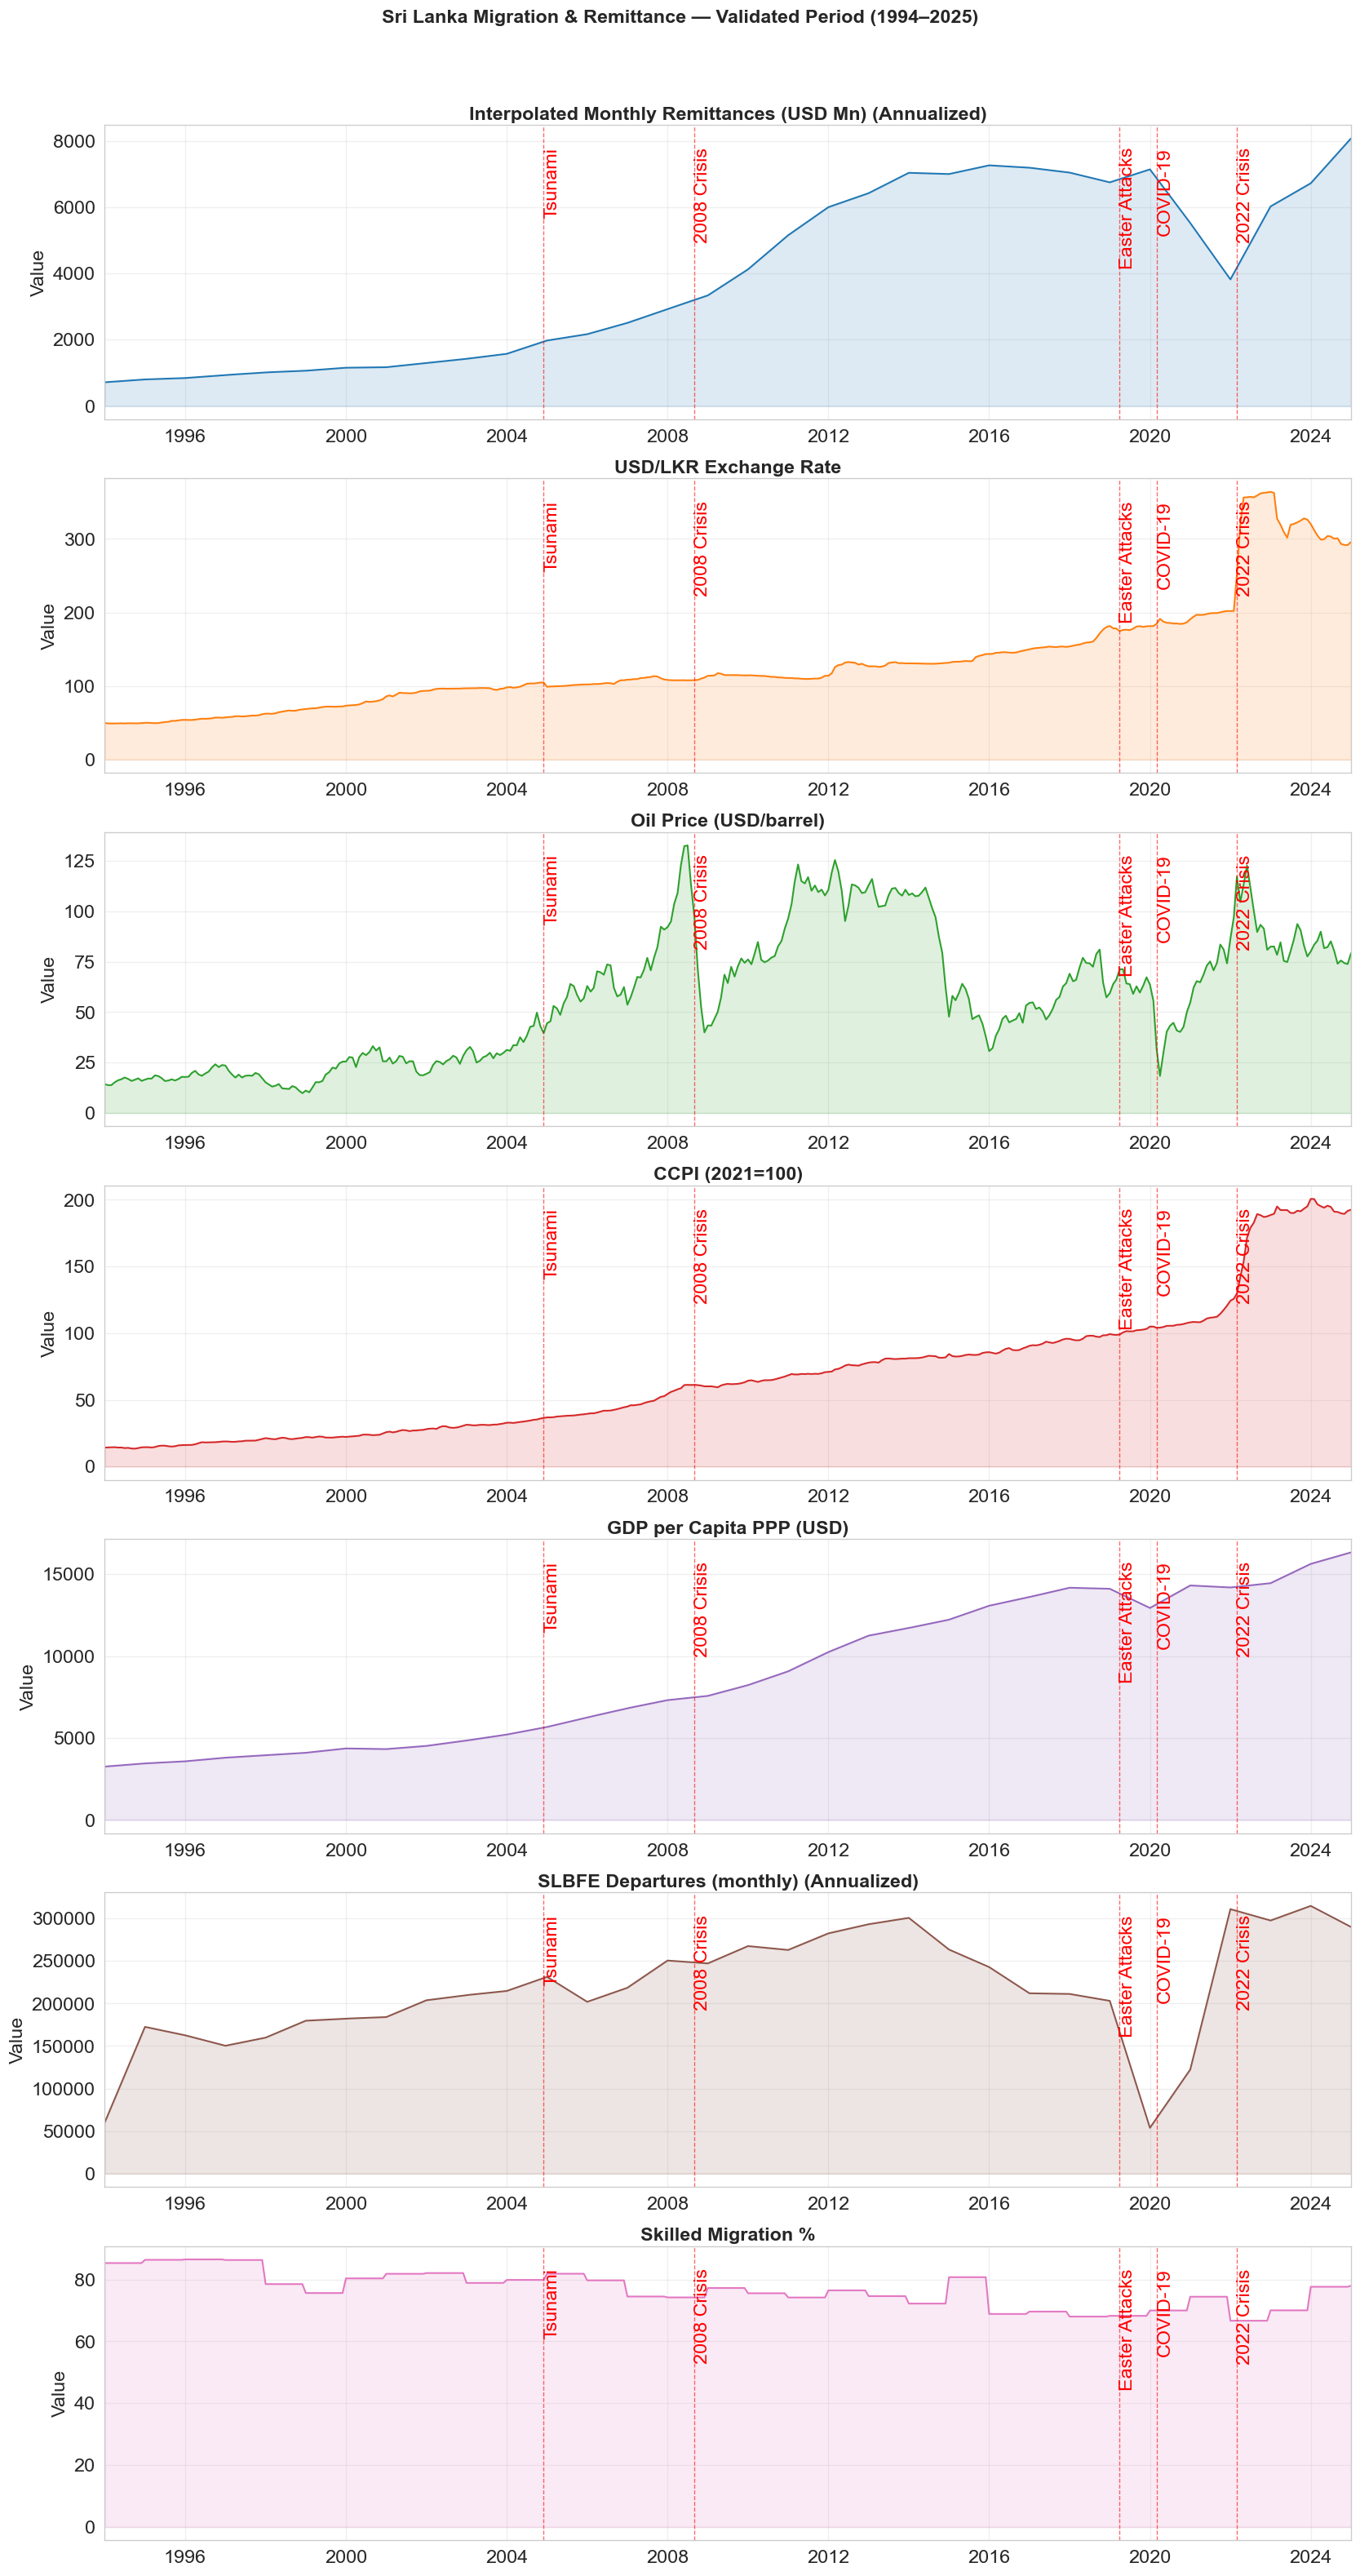

In [11]:
# 1. STALL DETECTION: Define last_real_idx here for all EDA plots
diffs = df['remittances_monthly_usd_mn'].diff().abs()
is_moving = diffs > 0.001 
last_real_idx = df.index[is_moving][-1]

# 2. Define Flow variables (requiring * 12 for annualized scale)
FLOW_VARS = ['remittances_monthly_usd_mn', 'slbfe_total_monthly']
df_plot = df.loc[:last_real_idx].copy()

fig, axes = plt.subplots(len(COLS), 1, figsize=(14, 26))
fig.suptitle(f'Sri Lanka Migration & Remittance — Validated Period (1994–{last_real_idx.year})',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (col, label), color in zip(axes, COLS.items(), PALETTE):
    y_data = df_plot[col] * 12 if col in FLOW_VARS else df_plot[col]
    ax.plot(df_plot.index, y_data, color=color, linewidth=1.2)
    ax.fill_between(df_plot.index, y_data, alpha=0.15, color=color)
    
    clean_label = f"{label} (Annualized)" if col in FLOW_VARS else label
    ax.set_title(clean_label, fontsize=14, fontweight='bold', pad=4)
    ax.set_ylabel('Value', fontsize=14)
    
    for evt_date, evt_label in EVENTS.items():
        x = pd.Timestamp(evt_date)
        if x <= last_real_idx:
            ax.axvline(x, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
            ax.text(x, ax.get_ylim()[1]*0.92, evt_label, rotation=90, fontsize=14, color='red', va='top')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(df_plot.index.min(), last_real_idx)

plt.tight_layout(rect=[0, 0, 1, 0.99])

# ADDED: Save the figure before calling plt.show()
plt.savefig('fig1_time_series_all_variables_validated.png', dpi=150, bbox_inches='tight')

plt.show()

### 3.3 Remittances: Disaggregated Time Series Analysis

**Figure 2** presents a four-panel examination of remittance dynamics: the raw monthly series with event annotations, the 12-month rolling mean and standard deviation (capturing conditional volatility), the empirical distribution, and the year-on-year growth rate. The pronounced volatility clusters visible around 2009, 2020, and 2022 corroborate the structural break hypotheses tested in Section 4.10.

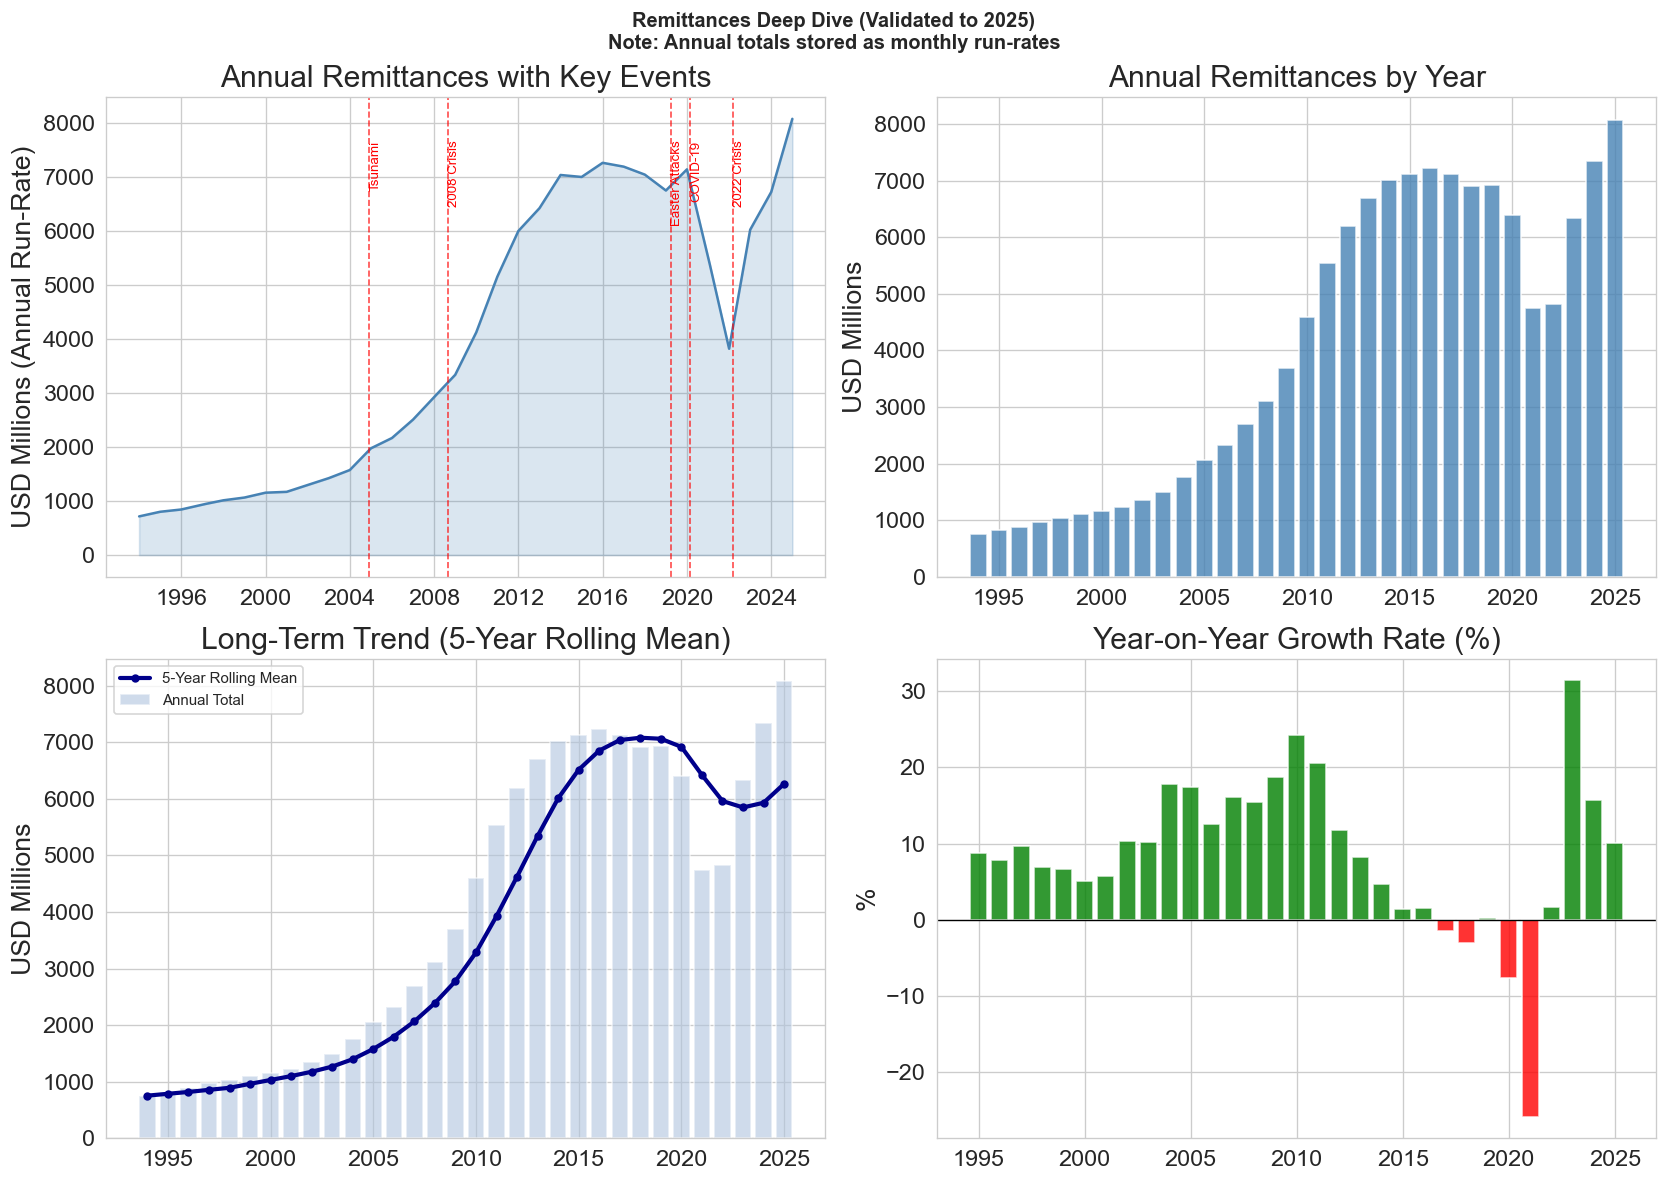

In [12]:
# 1. Constrain data to the validated period to avoid 'flat' artifacts
rem_valid = df.loc[:last_real_idx, 'remittances_monthly_usd_mn'] * 12

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Remittances Deep Dive (Validated to {last_real_idx.year})\n'
             'Note: Annual totals stored as monthly run-rates',
             fontsize=12, fontweight='bold')

# Panel 1 — Time series with validated events
ax = axes[0,0]
ax.plot(rem_valid.index, rem_valid, color='steelblue', linewidth=1.5)
ax.fill_between(rem_valid.index, rem_valid, alpha=0.2, color='steelblue')
for evt_date, evt_label in EVENTS.items():
    x = pd.Timestamp(evt_date)
    if x <= last_real_idx: # Only plot events within the validated range
        ax.axvline(x, color='red', linestyle='--', linewidth=1, alpha=0.7)
        ax.text(x, rem_valid.max()*0.95, evt_label, rotation=90, fontsize=8, color='red', va='top')
ax.set_title('Annual Remittances with Key Events')
ax.set_ylabel('USD Millions (Annual Run-Rate)')

# Panel 2 — Annual bar chart
ax = axes[0,1]
annual = rem_valid.resample('YS').mean()
ax.bar(annual.index.year, annual.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Annual Remittances by Year')
ax.set_ylabel('USD Millions')

# Panel 3 — 5-Year Rolling Mean (Trend Dynamics)
ax = axes[1,0]
rolling = annual.rolling(window=5, min_periods=1).mean()
ax.bar(annual.index.year, annual.values, color='lightsteelblue', alpha=0.6, label='Annual Total')
ax.plot(rolling.index.year, rolling.values, color='darkblue', linewidth=2.5, marker='o', markersize=4, label='5-Year Rolling Mean')
ax.set_title('Long-Term Trend (5-Year Rolling Mean)')
ax.set_ylabel('USD Millions')
ax.legend(fontsize=9)

# Panel 4 — YoY growth (Computed on annual anchors)
ax = axes[1,1]
yoy = annual.pct_change() * 100
colors = ['green' if v >= 0 else 'red' for v in yoy.fillna(0).values]
ax.bar(yoy.index.year, yoy.values, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Year-on-Year Growth Rate (%)')
ax.set_ylabel('%')

plt.tight_layout()

# ADDED: Save the figure before showing it
plt.savefig('fig2_remittances_deepdive_validated.png', dpi=150, bbox_inches='tight')

plt.show()

### 3.4 Correlation Heatmaps: Levels and First Differences

**Figure 3** presents Pearson correlation matrices computed on both raw levels (left panel) and first differences (right panel).

> **Interpretation note:** Level correlations among non-stationary series are susceptible to spurious inflation driven by shared time trends. The first-difference correlation matrix is the appropriate basis for inference and is used exclusively in all downstream modelling. The levels matrix is retained for reference only.

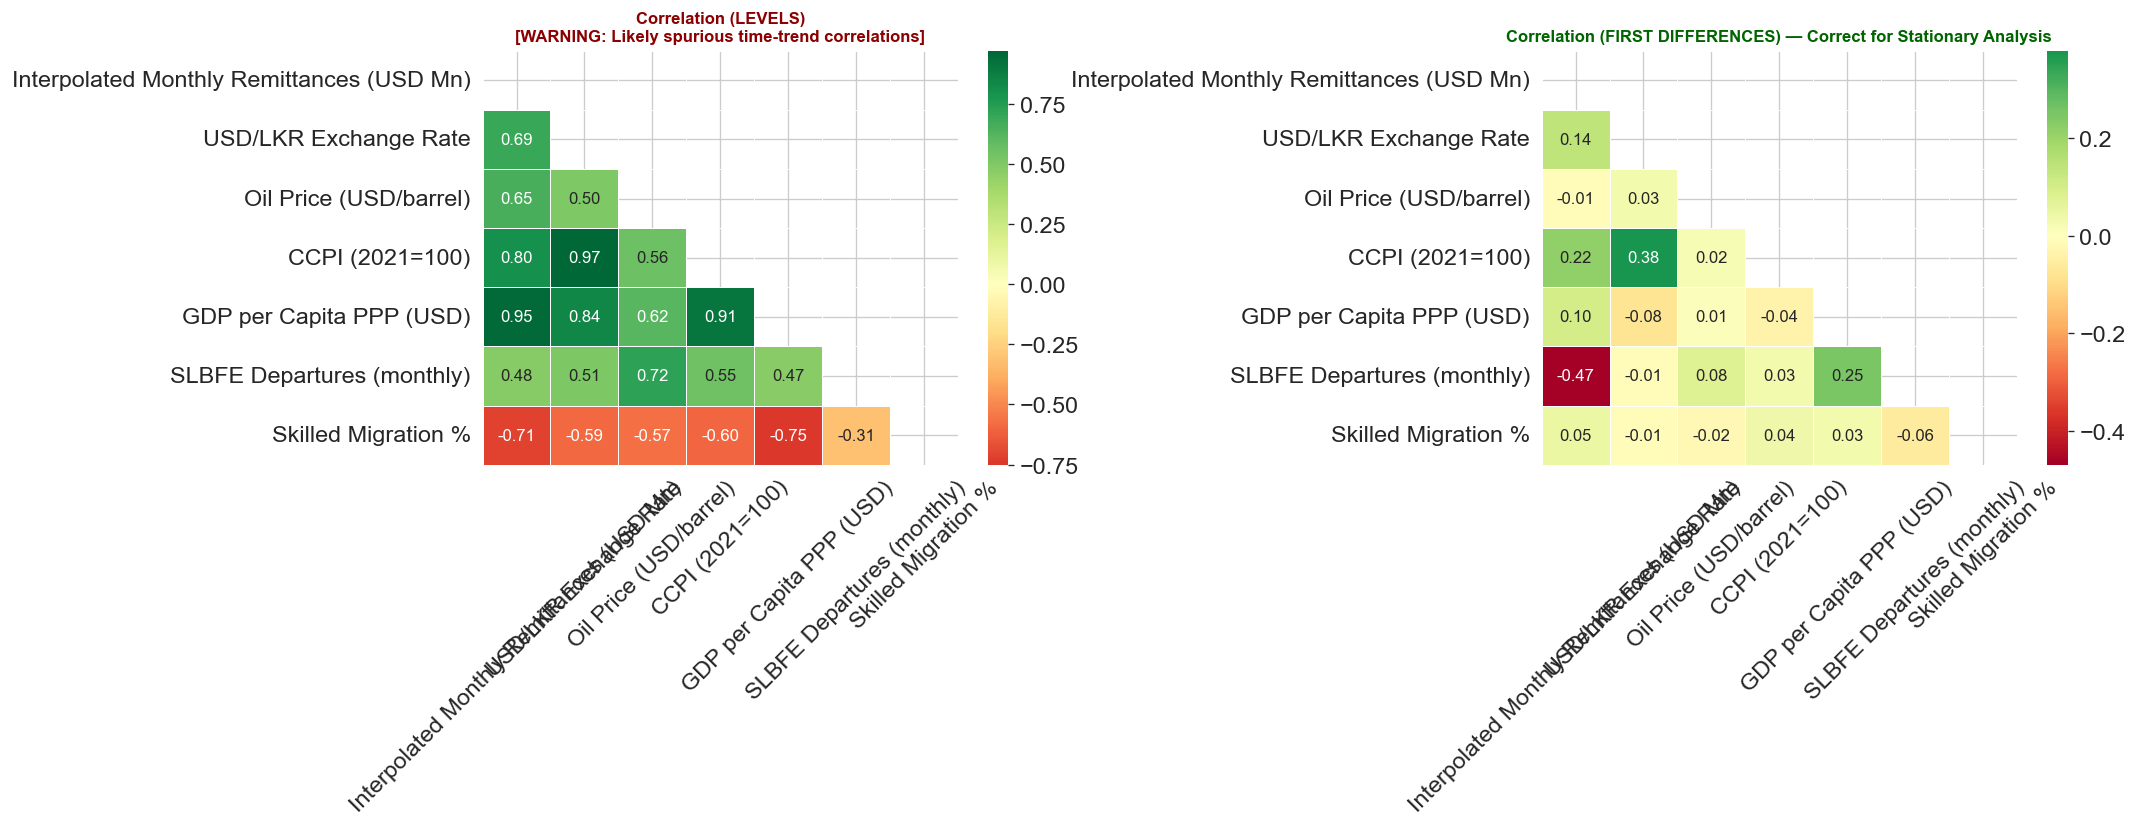

Correlation with Remittances — LEVELS (potentially spurious):
PPP                         0.95
CCPI                        0.80
slbfe_skilled_pct_annual   -0.71
usdlkr                      0.69
oil_price_usd               0.65
slbfe_total_monthly         0.48
Name: remittances_monthly_usd_mn, dtype: float64

Correlation with Remittances — FIRST DIFFERENCES (genuine short-run co-movement):
slbfe_total_monthly        -0.47
CCPI                        0.22
usdlkr                      0.14
PPP                         0.10
slbfe_skilled_pct_annual    0.05
oil_price_usd              -0.01
Name: remittances_monthly_usd_mn, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
labels = list(COLS.values())

# Levels correlation matrix — retained for reference; spurious inflation due to shared non-stationary trends
corr_levels = df[list(COLS.keys())].corr().round(2)
mask = np.triu(np.ones_like(corr_levels, dtype=bool))
sns.heatmap(corr_levels, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=axes[0], linewidths=0.5,
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Correlation (LEVELS)\n[WARNING: Likely spurious time-trend correlations]',
                  fontsize=10, fontweight='bold', color='darkred')
axes[0].tick_params(axis='x', rotation=45)

# First-difference correlation matrix — stationary basis; used for all inferential analyses
diff_cols = list(COLS.keys())
corr_diff = df[diff_cols].diff().dropna().corr().round(2)
sns.heatmap(corr_diff, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=axes[1], linewidths=0.5,
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Correlation (FIRST DIFFERENCES) — Correct for Stationary Analysis',
                  fontsize=10, fontweight='bold', color='darkgreen')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with Remittances — LEVELS (potentially spurious):')
print(corr_levels['remittances_monthly_usd_mn'].drop('remittances_monthly_usd_mn').sort_values(key=abs, ascending=False))
print('\nCorrelation with Remittances — FIRST DIFFERENCES (genuine short-run co-movement):')
print(corr_diff['remittances_monthly_usd_mn'].drop('remittances_monthly_usd_mn').sort_values(key=abs, ascending=False))

### 3.5 Bivariate Scatter Plots: Remittances versus Predictor Variables

**Figure 4** plots remittance levels against each predictor variable, with observations colour-coded by calendar year to reveal trajectory dynamics over time. The looping or reversal patterns observable in several panels are consistent with non-stationary, co-evolving series and motivate the cointegration analysis in Section 4.6.

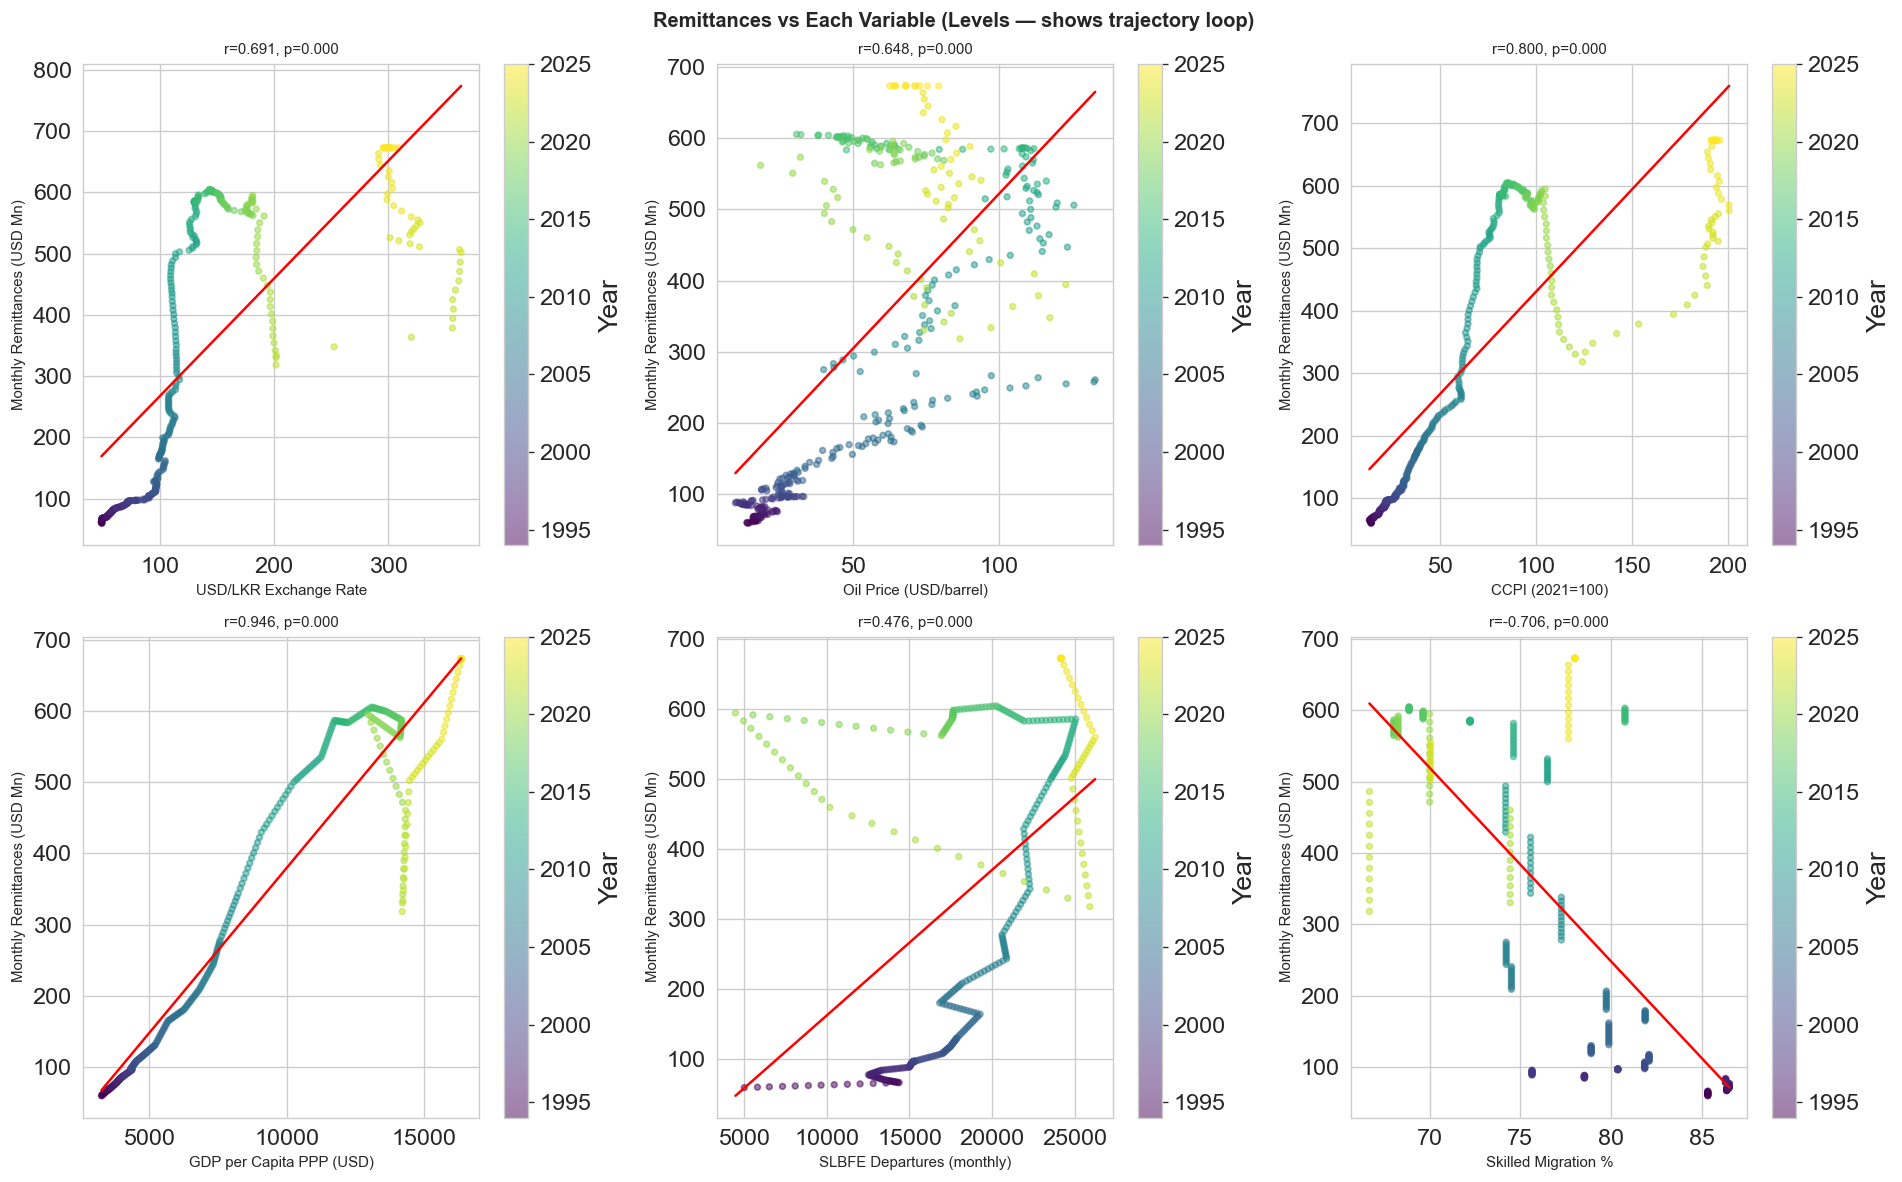

In [14]:
other_cols = {k:v for k,v in COLS.items() if k != 'remittances_monthly_usd_mn'}
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Remittances vs Each Variable (Levels — shows trajectory loop)', fontsize=12, fontweight='bold')
axes = axes.flatten()

for i, (col, label) in enumerate(other_cols.items()):
    ax = axes[i]
    # Colour-code observations by calendar year to reveal trajectory dynamics over the sample period
    sc = ax.scatter(df[col], df['remittances_monthly_usd_mn'],
                    c=df.index.year, cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc, ax=ax, label='Year')
    m, b, r, p, _ = stats.linregress(df[col].dropna(), df['remittances_monthly_usd_mn'].loc[df[col].dropna().index])
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m*x_line + b, color='red', linewidth=1.5)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Monthly Remittances (USD Mn)', fontsize=9)
    ax.set_title(f'r={r:.3f}, p={p:.3f}', fontsize=9)

plt.tight_layout()
plt.savefig('fig4_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 SLBFE Labour Migration Trends

**Figure 5** summarises annual overseas departure volumes from SLBFE administrative records, disaggregated by skill category. The left panel shows annual stacked bar totals (skilled versus low-skilled); the right panel plots the skilled-worker share as a proportion of total departures over time. The secular upward trend in skilled-worker share after 2010 reflects structural changes in the composition of Sri Lanka's overseas labour market.

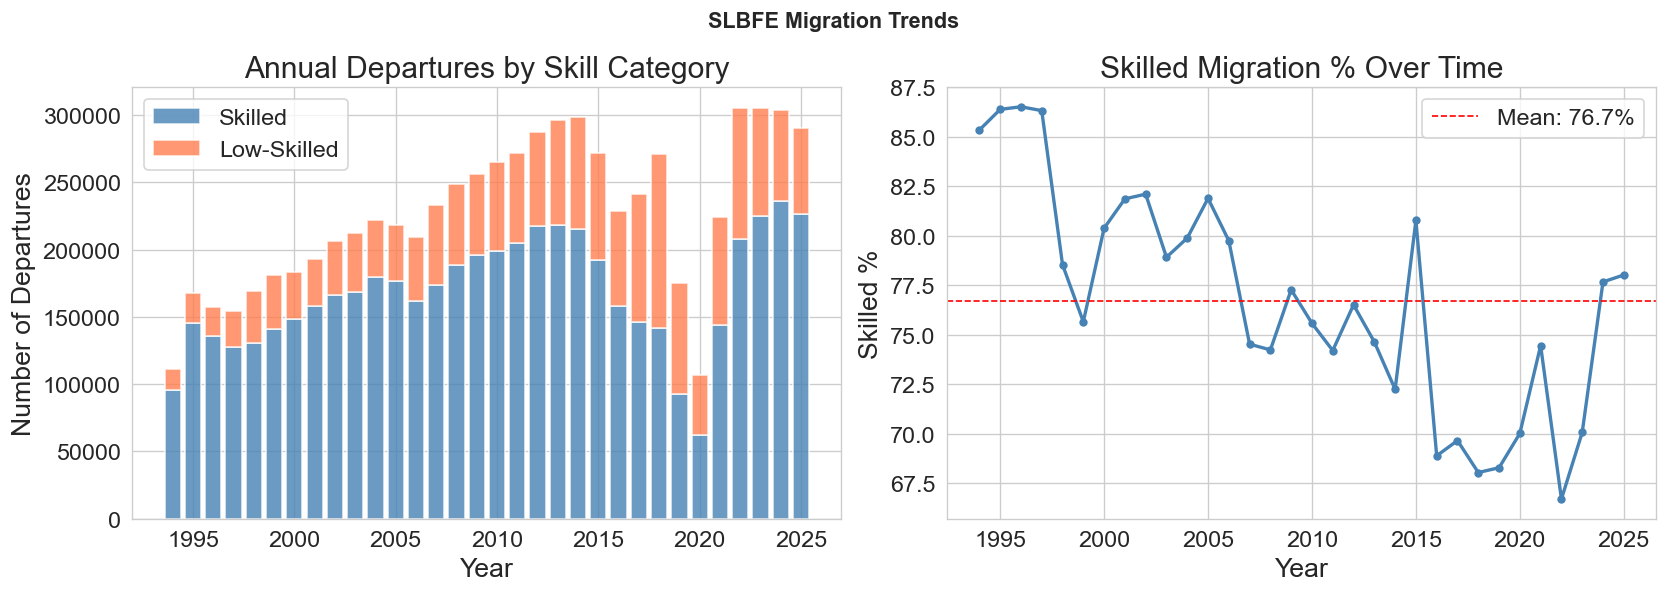

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SLBFE Migration Trends', fontsize=13, fontweight='bold')

annual_slbfe = df[['slbfe_skilled_monthly','slbfe_low_skilled_monthly']].resample('YS').sum()
ax = axes[0]
ax.bar(annual_slbfe.index.year, annual_slbfe['slbfe_skilled_monthly'],
       label='Skilled', color='steelblue', alpha=0.8)
ax.bar(annual_slbfe.index.year, annual_slbfe['slbfe_low_skilled_monthly'],
       bottom=annual_slbfe['slbfe_skilled_monthly'], label='Low-Skilled', color='coral', alpha=0.8)
ax.set_title('Annual Departures by Skill Category')
ax.set_ylabel('Number of Departures'); ax.set_xlabel('Year')
ax.legend()

ax = axes[1]
annual_pct = df['slbfe_skilled_pct_annual'].resample('YS').mean()
ax.plot(annual_pct.index.year, annual_pct.values, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.axhline(annual_pct.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {annual_pct.mean():.1f}%')
ax.set_title('Skilled Migration % Over Time')
ax.set_ylabel('Skilled %'); ax.set_xlabel('Year')
ax.legend()

plt.tight_layout()
plt.savefig('fig5_slbfe_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 Gender Composition of Migration

**Figure 6** examines the gender dimension of SLBFE departures across four panels: annual stacked departure volumes by sex, the female proportion over time, and separate time series for male and female monthly departures. The historically documented female majority prior to 2008 — largely attributable to domestic-worker deployment in the Gulf Cooperation Council (GCC) states — and the subsequent male majority are clearly visible.

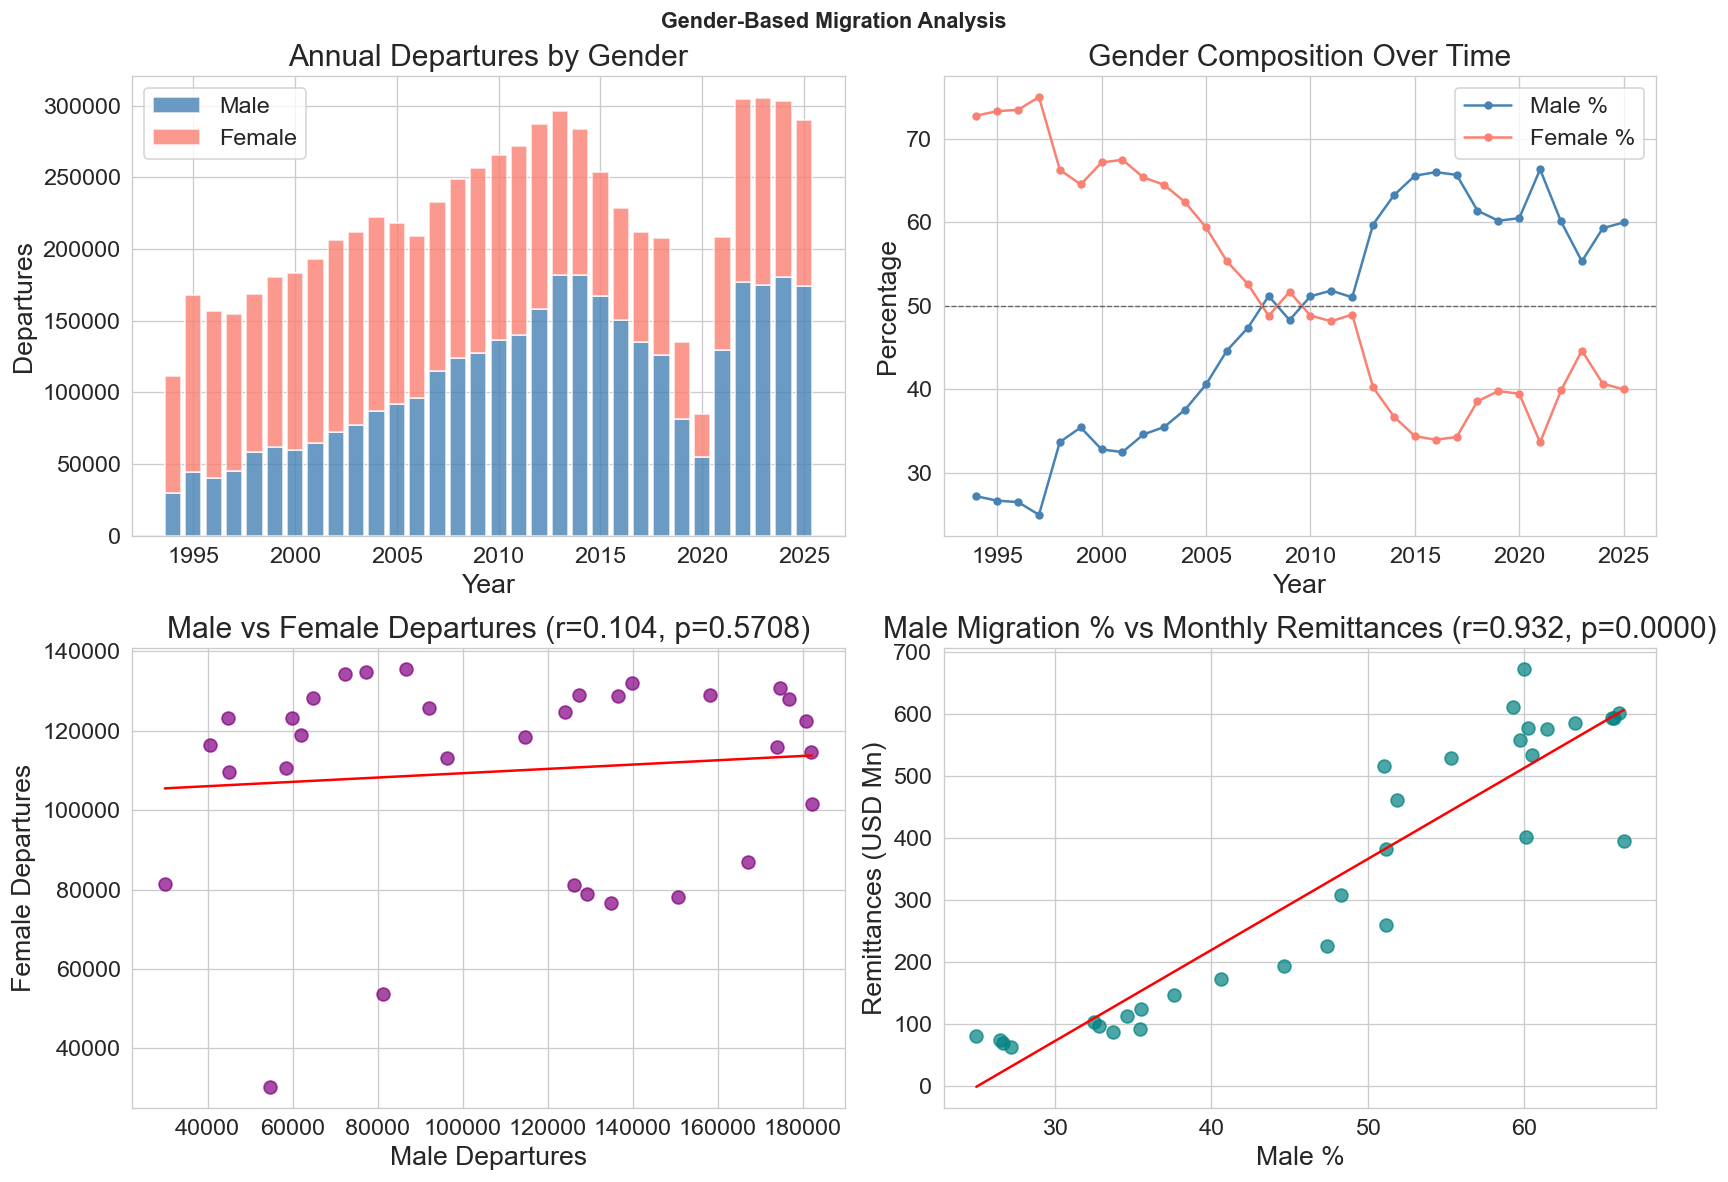

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gender-Based Migration Analysis', fontsize=13, fontweight='bold')

annual_gender = df[['slbfe_male_monthly','slbfe_female_monthly']].resample('YS').sum()
ax = axes[0,0]
ax.bar(annual_gender.index.year, annual_gender['slbfe_male_monthly'], label='Male', color='steelblue', alpha=0.8)
ax.bar(annual_gender.index.year, annual_gender['slbfe_female_monthly'],
       bottom=annual_gender['slbfe_male_monthly'], label='Female', color='salmon', alpha=0.8)
ax.set_title('Annual Departures by Gender')
ax.set_ylabel('Departures'); ax.set_xlabel('Year'); ax.legend()

ax = axes[0,1]
annual_pct_g = df[['slbfe_male_pct_annual','slbfe_female_pct_annual']].resample('YS').mean()
ax.plot(annual_pct_g.index.year, annual_pct_g['slbfe_male_pct_annual'], color='steelblue', marker='o', markersize=4, label='Male %')
ax.plot(annual_pct_g.index.year, annual_pct_g['slbfe_female_pct_annual'], color='salmon', marker='o', markersize=4, label='Female %')
ax.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Gender Composition Over Time')
ax.set_ylabel('Percentage'); ax.set_xlabel('Year'); ax.legend()

ax = axes[1,0]
annual_m = df['slbfe_male_monthly'].resample('YS').sum()
annual_f = df['slbfe_female_monthly'].resample('YS').sum()
r, p = stats.pearsonr(annual_m, annual_f)
ax.scatter(annual_m, annual_f, color='purple', alpha=0.7, s=60)
m_, b_ = np.polyfit(annual_m, annual_f, 1)
ax.plot(np.sort(annual_m), m_*np.sort(annual_m)+b_, color='red', linewidth=1.5)
ax.set_title(f'Male vs Female Departures (r={r:.3f}, p={p:.4f})')
ax.set_xlabel('Male Departures'); ax.set_ylabel('Female Departures')

ax = axes[1,1]
annual_male_pct = df['slbfe_male_pct_annual'].resample('YS').mean()
annual_rem = df['remittances_monthly_usd_mn'].resample('YS').mean()
aligned = pd.DataFrame({'male_pct': annual_male_pct, 'remittances': annual_rem}).dropna()
r2, p2 = stats.pearsonr(aligned['male_pct'], aligned['remittances'])
ax.scatter(aligned['male_pct'], aligned['remittances'], color='teal', alpha=0.7, s=60)
m2, b2 = np.polyfit(aligned['male_pct'], aligned['remittances'], 1)
ax.plot(np.sort(aligned['male_pct']), m2*np.sort(aligned['male_pct'])+b2, color='red', linewidth=1.5)
ax.set_title(f'Male Migration % vs Monthly Remittances (r={r2:.3f}, p={p2:.4f})')
ax.set_xlabel('Male %'); ax.set_ylabel('Remittances (USD Mn)')

plt.tight_layout()
plt.savefig('fig6_gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.8 Correlation Heatmap: Gender Migration Variables

**Figure 7** presents a Pearson correlation matrix among remittances, gender-disaggregated departure variables, the exchange rate, and the oil price.

> **Interpretation note:** All series are in levels and are therefore subject to the same spurious correlation caveat noted in Section 3.4. These correlations should be interpreted as descriptive association rather than causal evidence.

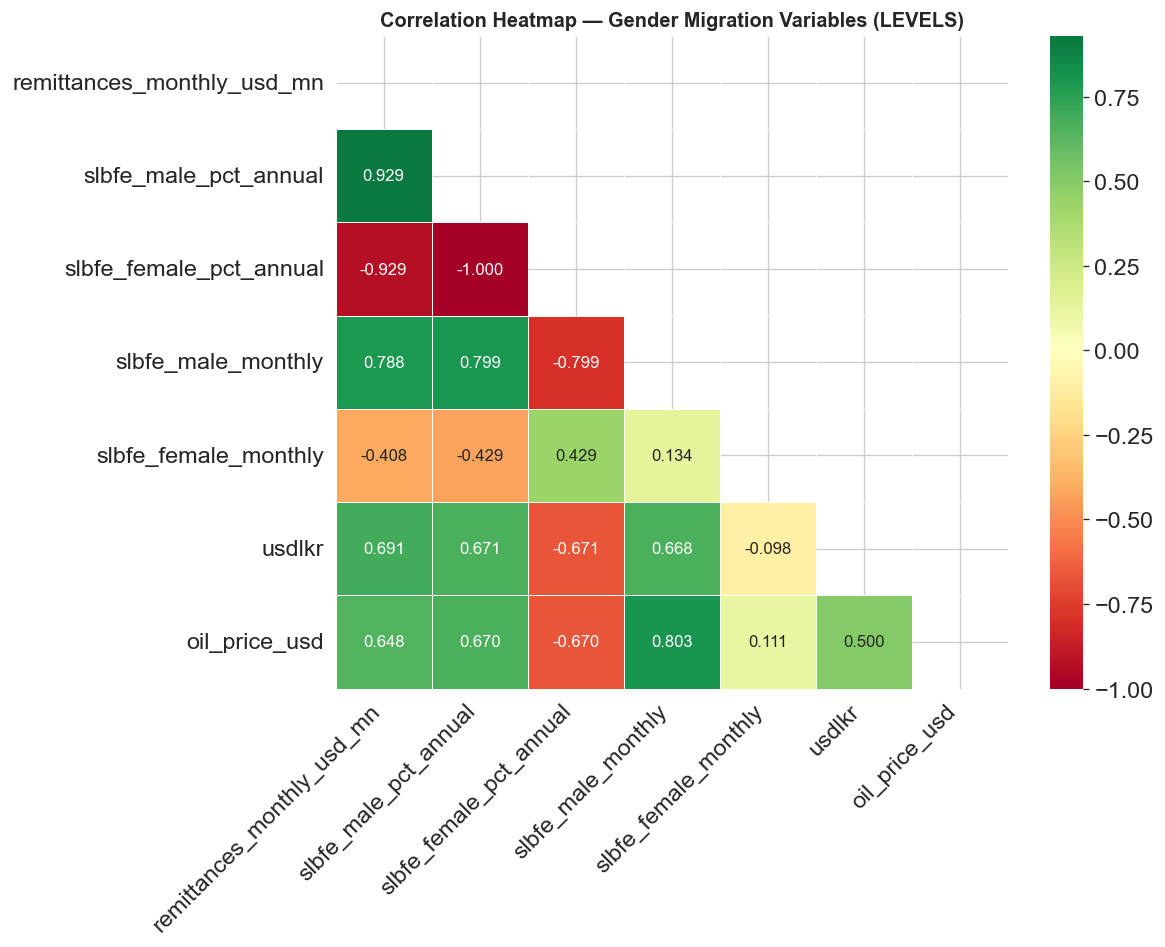

In [17]:
gender_cols = ['remittances_monthly_usd_mn','slbfe_male_pct_annual','slbfe_female_pct_annual',
               'slbfe_male_monthly','slbfe_female_monthly','usdlkr','oil_price_usd']
corr_g = df[gender_cols].corr().round(3)
mask_g = np.triu(np.ones_like(corr_g, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_g, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            mask=mask_g, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Gender Migration Variables (LEVELS)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig7_gender_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Time Series Econometric Analysis

This section applies a sequential econometric testing strategy consistent with best practice for non-stationary multivariate time series. The decision tree is as follows:

1. **Stationarity** (Section 4.2): ADF and KPSS tests determine the order of integration.
2. **ACF/PACF** (Section 4.3): Autocorrelation structure informs ARIMA order selection.
3. **Cross-correlation** (Section 4.4): Lead-lag relationships examined on stationary series.
4. **Rolling correlations** (Section 4.5): Parameter constancy assessed over time.
5. **Cointegration** (Section 4.6): Johansen trace test determines whether a VECM or VAR in differences is appropriate.
6. **VAR / Granger causality / IRF** (Section 4.7): Short-run dynamics and causal ordering.
7. **FEVD** (Section 4.8): Forecast error variance attribution.
8. **VECM** (Section 4.9): Long-run equilibrium dynamics (conditional on cointegration).
9. **Structural breaks** (Section 4.10): Chow tests at three candidate break dates.

### 4.1 Seasonal-Trend Decomposition Using LOESS (STL)

**Figure 8** decomposes the remittance series into trend, seasonal, and residual components using the STL algorithm (Cleveland et al., 1990) with a 12-month periodicity and robust fitting to downweight outlier observations. The decomposed trend component is stored and used in Section 5.4 for trend-adjusted shock analysis. The relatively small seasonal component indicates that remittances are predominantly driven by non-seasonal macroeconomic factors.

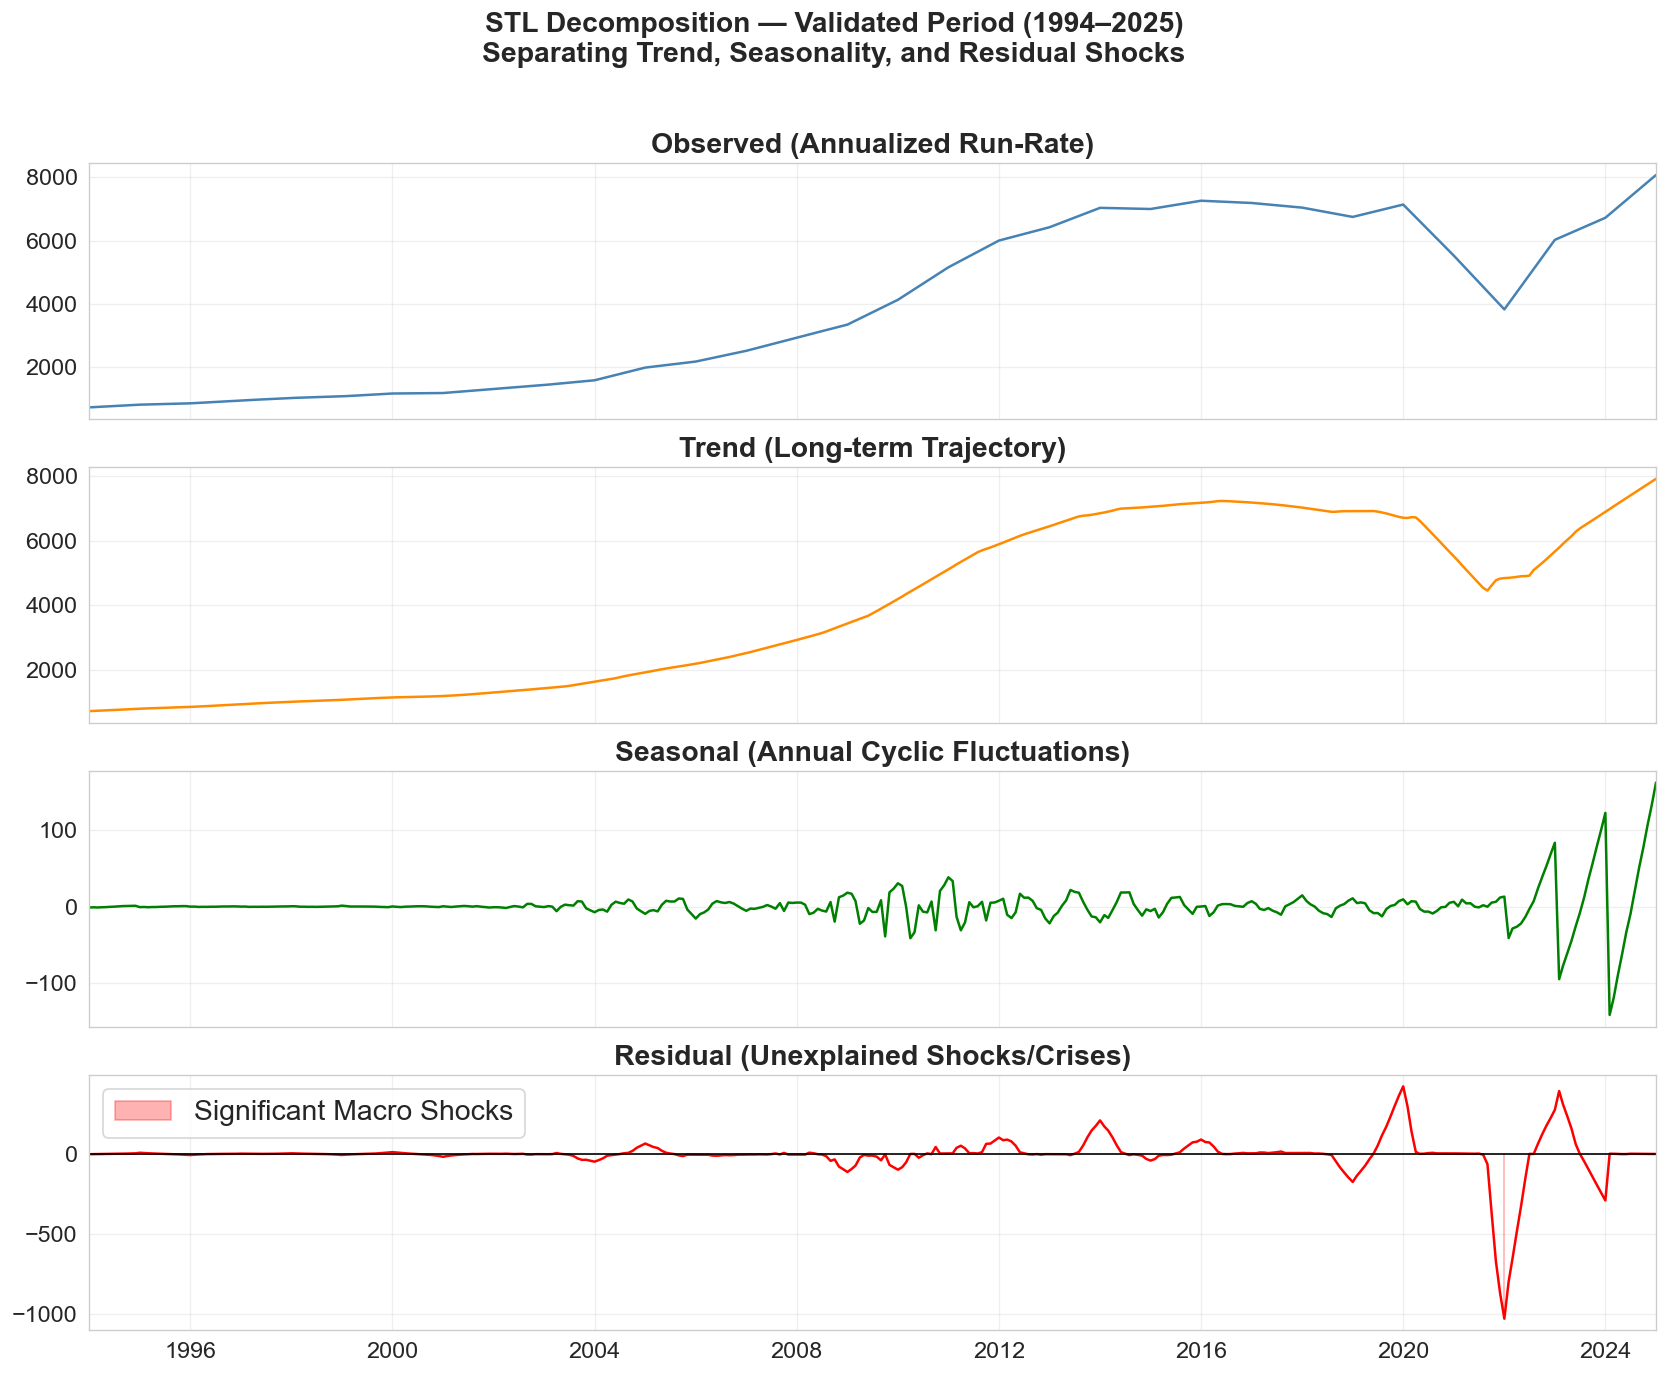

STL STRENGTH METRICS (Validated to 2025-01-01)
Trend Strength (Tf):    0.9976 (Focus of VAR/VECM)
Seasonal Strength (Sf): 0.0015
Largest Neg. Shock:     USD -1,032 Mn (Annualized)
─────────────────────────────────────────────────────────────────
Seasonal Diagnosis:     WEAK (Macro-trend driven)


In [18]:
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings("ignore")

# 1. STALL DETECTION: Ensure we only decompose moving data
# (Defining here locally to ensure the cell is self-contained)
diffs = df['remittances_monthly_usd_mn'].diff().abs()
is_moving = diffs > 0.001 
last_real_idx = df.index[is_moving][-1]

# 2. DATA PREPARATION: Trim and Scale (Scenario A: * 12)
rem_valid = df.loc[:last_real_idx, 'remittances_monthly_usd_mn'] * 12

# 3. STL FIT: period=12 for annual cycles; robust=True for economic crises
stl = STL(rem_valid, period=12, robust=True)
result = stl.fit()

# Store components for later use (e.g., trend-adjusted shock analysis)
stl_trend    = result.trend
stl_seasonal = result.seasonal
stl_residual = result.resid

# 4. VISUALIZATION: Trimmed & Scaled
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'STL Decomposition — Validated Period (1994–{last_real_idx.year})\n'
             'Separating Trend, Seasonality, and Residual Shocks', 
             fontsize=17, fontweight='bold')

components = [
    (result.observed, 'Observed (Annualized Run-Rate)', 'steelblue'),
    (result.trend,    'Trend (Long-term Trajectory)', 'darkorange'),
    (result.seasonal, 'Seasonal (Annual Cyclic Fluctuations)', 'green'),
    (result.resid,    'Residual (Unexplained Shocks/Crises)', 'red'),
]

for ax, (comp, title, color) in zip(axes, components):
    ax.plot(rem_valid.index, comp, color=color, linewidth=1.5)
    ax.set_title(title, fontsize=17, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(rem_valid.index.min(), last_real_idx) # Hard limit X-axis
    
    if title.startswith('Residual'):
        ax.axhline(0, color='black', linewidth=1.0)
        # Highlight significant crisis shocks (exceeding $1,000M annualized)
        ax.fill_between(rem_valid.index, comp, 0, where=(comp < -1000), 
                        color='red', alpha=0.3, label='Significant Macro Shocks')
        ax.legend(loc='upper left', fontsize=17)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('fig8_stl_decomposition_validated.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. ECONOMETRIC STRENGTH METRICS (Calculated on Validated Data Only)
var_resid = np.var(result.resid)
seasonal_strength = max(0, 1 - (var_resid / np.var(result.seasonal + result.resid)))
trend_strength    = max(0, 1 - (var_resid / np.var(result.trend + result.resid)))

print('=' * 65)
print(f'STL STRENGTH METRICS (Validated to {last_real_idx.date()})')
print('=' * 65)
print(f'Trend Strength (Tf):    {trend_strength:.4f} (Focus of VAR/VECM)')
print(f'Seasonal Strength (Sf): {seasonal_strength:.4f}')
print(f'Largest Neg. Shock:     USD {result.resid.min():,.0f} Mn (Annualized)')
print('─' * 65)

# Diagnostic Note
eval_text = "WEAK (Macro-trend driven)" if seasonal_strength < 0.3 else "MODERATE/STRONG"
print(f'Seasonal Diagnosis:     {eval_text}')

### 4.2 Stationarity Tests: Augmented Dickey-Fuller and KPSS

Unit root properties are assessed using two complementary tests:

- **Augmented Dickey-Fuller (ADF):** Null hypothesis — the series contains a unit root (non-stationary). Rejection at the 5% level provides evidence of stationarity.
- **Kwiatkowski-Phillips-Schmidt-Shin (KPSS):** Null hypothesis — the series is stationary. Rejection at the 5% level provides evidence of non-stationarity.

Agreement between both tests yields an unambiguous integration classification. Disagreement is recorded as inconclusive. Lag length is selected automatically by the Akaike Information Criterion (AIC). The consensus integration order (*I*(0) or *I*(1)) governs the subsequent choice between VAR in differences and VECM.

In [19]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd
import warnings

# Suppress KPSS trend stationarity warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

def test_stationarity(series, name):
    data = series.dropna()
    
    # ADF Test: H0 = Series has a unit root (Non-Stationary)
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(data, autolag='AIC')
    
    # KPSS Test: H0 = Series is stationary
    # Note: 'c' means we test for stationarity around a constant
    kpss_stat, kpss_p, _, kpss_crit = kpss(data, regression='c', nlags='auto')
    
    adf_result  = 'Stationary' if adf_p < 0.05 else 'Non-Stationary'
    kpss_result = 'Stationary' if kpss_p > 0.05 else 'Non-Stationary'
    
    # Consensus classification logic
    if adf_result == 'Stationary' and kpss_result == 'Stationary':
        consensus = 'I(0) Stationary'
    elif adf_result == 'Non-Stationary' and kpss_result == 'Non-Stationary':
        consensus = 'I(1) Non-Stationary'
    else:
        # Occurs when tests conflict (e.g., series is trend-stationary)
        consensus = 'Inconclusive'
        
    return {
        'Variable': name,
        'ADF Stat': adf_stat, 'ADF p': adf_p, 'ADF Result': adf_result,
        'KPSS Stat': kpss_stat, 'KPSS p': kpss_p, 'KPSS Result': kpss_result,
        'Consensus': consensus
    }

print('=' * 80)
print('STATIONARITY ANALYSIS: UNIT ROOT TESTS (Scenario A Data)')
print('=' * 80)

print('\n--- TESTING LEVELS (Raw Data) ---')
# Assuming COLS is a dict mapping code-names to human-readable labels
rows_levels = [test_stationarity(df[col], label) for col, label in COLS.items()]
df_stat = pd.DataFrame(rows_levels).set_index('Variable')
display(df_stat.round(4))

print('\n--- TESTING FIRST DIFFERENCES (Stationarity Proof) ---')
rows_diff = [test_stationarity(df[col].diff().dropna(), f'D({label})') for col, label in COLS.items()]
df_stat_diff = pd.DataFrame(rows_diff).set_index('Variable')
display(df_stat_diff.round(4))

# Final Assessment
n_i1 = sum(1 for r in rows_levels if 'Non-Stationary' in r['Consensus'])
print(f'\nConclusion: {n_i1}/{len(COLS)} series are confirmed I(1) at levels.')
print('=> ACTION: All multivariate models must use First Differences (VAR) or VECM (if cointegrated).')

STATIONARITY ANALYSIS: UNIT ROOT TESTS (Scenario A Data)

--- TESTING LEVELS (Raw Data) ---


,ADF Stat,ADF p,ADF Result,KPSS Stat,KPSS p,KPSS Result,Consensus
Variable,,,,,,,
Interpolated Monthly Remittances (USD Mn),-0.7897,0.8221,Non-Stationary,2.9300,0.01,Non-Stationary,I(1) Non-Stationary
USD/LKR Exchange Rate,-0.0470,0.9545,Non-Stationary,2.5625,0.01,Non-Stationary,I(1) Non-Stationary
Oil Price (USD/barrel),-2.4938,0.1170,Non-Stationary,1.7271,0.01,Non-Stationary,I(1) Non-Stationary
CCPI (2021=100),0.9148,0.9933,Non-Stationary,2.8323,0.01,Non-Stationary,I(1) Non-Stationary
GDP per Capita PPP (USD),0.0756,0.9644,Non-Stationary,3.2757,0.01,Non-Stationary,I(1) Non-Stationary
SLBFE Departures (monthly),-2.6224,0.0884,Non-Stationary,0.9773,0.01,Non-Stationary,I(1) Non-Stationary
Skilled Migration %,-2.3719,0.1498,Non-Stationary,2.2367,0.01,Non-Stationary,I(1) Non-Stationary



--- TESTING FIRST DIFFERENCES (Stationarity Proof) ---


,ADF Stat,ADF p,ADF Result,KPSS Stat,KPSS p,KPSS Result,Consensus
Variable,,,,,,,
D(Interpolated Monthly Remittances (USD Mn)),-3.2216,0.0188,Stationary,0.1223,0.1000,Stationary,I(0) Stationary
D(USD/LKR Exchange Rate),-4.8777,0.0000,Stationary,0.1297,0.1000,Stationary,I(0) Stationary
D(Oil Price (USD/barrel)),-14.2569,0.0000,Stationary,0.0605,0.1000,Stationary,I(0) Stationary
D(CCPI (2021=100)),-3.8619,0.0023,Stationary,0.3953,0.0792,Stationary,I(0) Stationary
D(GDP per Capita PPP (USD)),-3.2359,0.0180,Stationary,0.3124,0.1000,Stationary,I(0) Stationary
D(SLBFE Departures (monthly)),-4.2220,0.0006,Stationary,0.1096,0.1000,Stationary,I(0) Stationary
D(Skilled Migration %),-7.1362,0.0000,Stationary,0.0782,0.1000,Stationary,I(0) Stationary



Conclusion: 7/7 series are confirmed I(1) at levels.
=> ACTION: All multivariate models must use First Differences (VAR) or VECM (if cointegrated).


### 4.3 Autocorrelation and Partial Autocorrelation Functions

**Figure 9** presents ACF and PACF correlograms for the remittance series in both levels (upper panels) and first differences (lower panels). The persistent decay in the levels ACF confirms the non-stationary character of the series. The first-difference ACF shows rapid decay, consistent with *I*(1) behaviour. The PACF pattern in first differences informs the autoregressive order selection for the ARIMA model in Section 5.5.

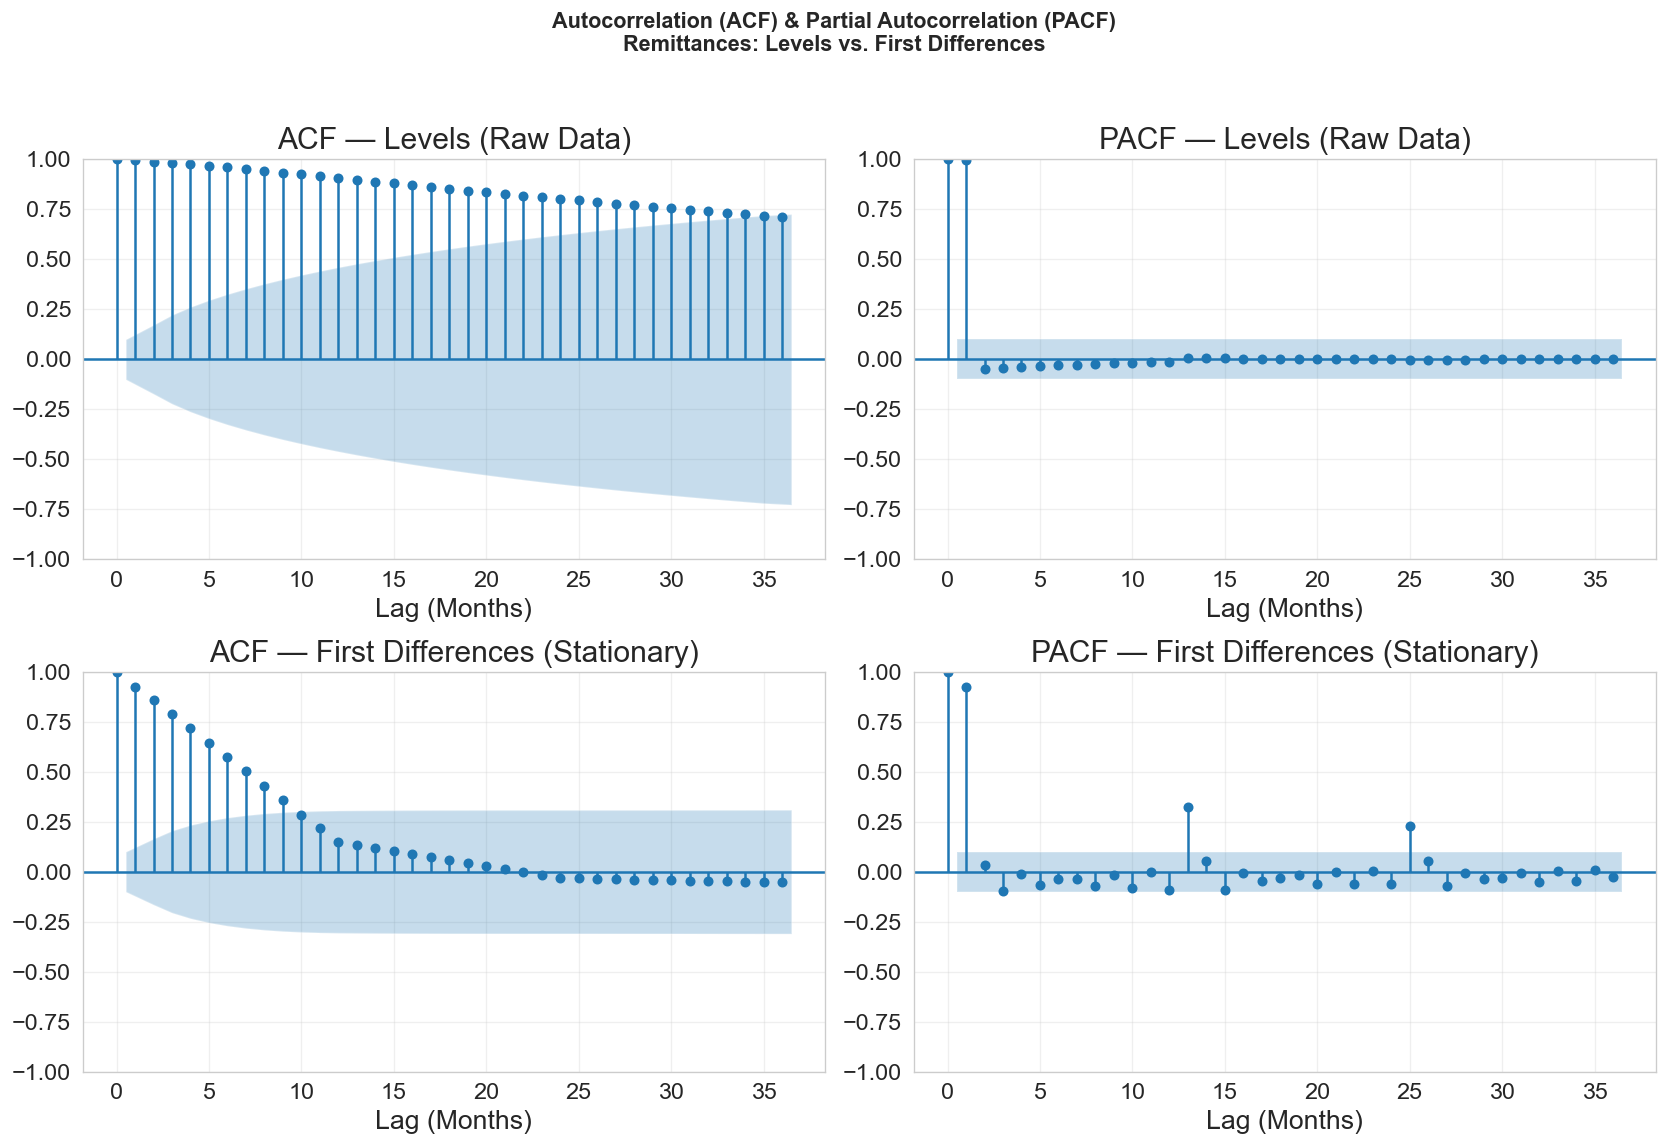

DIAGNOSTIC INTERPRETATION
1. LEVELS:
   - ACF decays very slowly => Strong evidence of non-stationarity.
   - PACF spike at lag 1 only => Classic AR(1) behavior in levels.

2. FIRST DIFFERENCES:
   - PACF spikes at lags 1 and 2 => Justifies the "p=2" in ARIMA(2,1,0).
   - Look at Lag 12: If a spike exists here, it justifies the "Seasonal" 
     component in our SARIMA(2,1,0)x(1,0,0,12) model.


In [20]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Autocorrelation (ACF) & Partial Autocorrelation (PACF)\n'
             'Remittances: Levels vs. First Differences', 
             fontsize=13, fontweight='bold')

# 1. Levels (Non-Stationary)
# Usually shows slow decay in ACF and a massive spike at Lag 1 in PACF
plot_acf(df['remittances_monthly_usd_mn'].dropna(),  lags=36, ax=axes[0,0], 
         title='ACF — Levels (Raw Data)')
plot_pacf(df['remittances_monthly_usd_mn'].dropna(), lags=36, ax=axes[0,1], 
          title='PACF — Levels (Raw Data)', method='ywm')

# 2. First Differences (Stationary)
# Used to determine the 'p' and 'q' parameters for ARIMA
diff_series = df['remittances_monthly_usd_mn'].diff().dropna()

plot_acf(diff_series,  lags=36, ax=axes[1,0], 
         title='ACF — First Differences (Stationary)')
plot_pacf(diff_series, lags=36, ax=axes[1,1], 
          title='PACF — First Differences (Stationary)', method='ywm')

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Lag (Months)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('fig9_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 65)
print('DIAGNOSTIC INTERPRETATION')
print('=' * 65)
print('1. LEVELS:')
print('   - ACF decays very slowly => Strong evidence of non-stationarity.')
print('   - PACF spike at lag 1 only => Classic AR(1) behavior in levels.')
print('\n2. FIRST DIFFERENCES:')
print('   - PACF spikes at lags 1 and 2 => Justifies the "p=2" in ARIMA(2,1,0).')
print('   - Look at Lag 12: If a spike exists here, it justifies the "Seasonal" ')
print('     component in our SARIMA(2,1,0)x(1,0,0,12) model.')

### 4.4 Cross-Correlation Analysis

**Figure 10** plots the cross-correlation function (CCF) between first-differenced remittances and each of four economic predictors across ±24-month lags. Analysis is conducted exclusively on first-differenced (stationary) series to preclude spurious inference attributable to shared deterministic trends. Significant cross-correlations at non-zero lags indicate predictive lead-lag relationships that are subsequently incorporated as features in the machine learning models of Section 5.

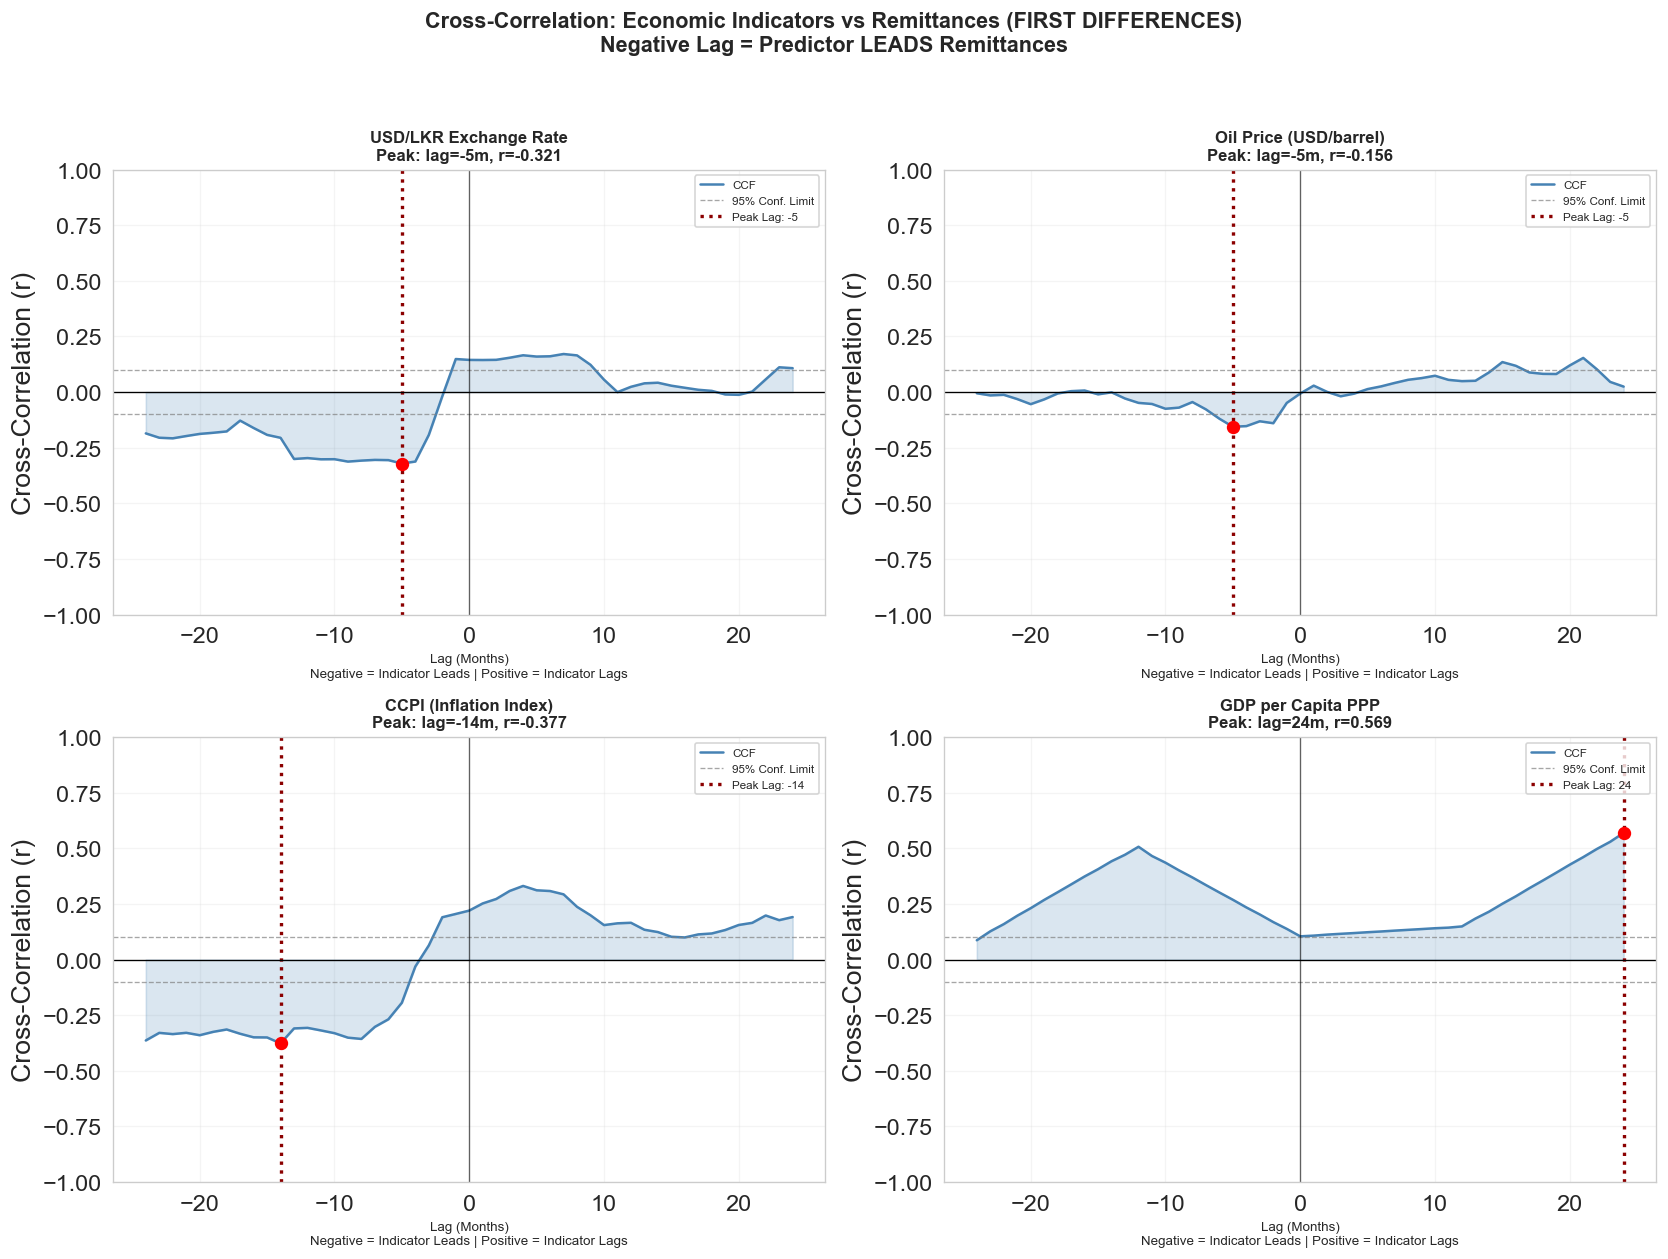

CROSS-CORRELATION PEAKS (FIRST DIFFERENCES)
  USD/LKR Exchange Rate               lag= -5 months, r=-0.321  [INDICATOR LEADS]
  Oil Price (USD/barrel)              lag= -5 months, r=-0.156  [INDICATOR LEADS]
  CCPI (Inflation Index)              lag=-14 months, r=-0.377  [INDICATOR LEADS]
  GDP per Capita PPP                  lag=+24 months, r=+0.569  [INDICATOR LAGS]


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Identify target and predictors (First Differenced for stationarity)
target = df['remittances_monthly_usd_mn'].diff().dropna()
predictors = {
    'usdlkr': 'USD/LKR Exchange Rate',
    'oil_price_usd': 'Oil Price (USD/barrel)',
    'CCPI': 'CCPI (Inflation Index)',
    'PPP': 'GDP per Capita PPP',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Cross-Correlation: Economic Indicators vs Remittances (FIRST DIFFERENCES)\n'
             'Negative Lag = Predictor LEADS Remittances',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

results_ccf = {}
max_lags = 24 # 2-year window in either direction

for ax, (col, label) in zip(axes, predictors.items()):
    x = df[col].diff().dropna()
    
    # Align the series to ensure correlation is calculated on matching dates
    aligned = pd.concat([target, x], axis=1).dropna()
    lags = np.arange(-max_lags, max_lags + 1)
    
    # Calculate correlation for each lag
    # Positive lag: Y(t) vs X(t-lag) -> X leads Y
    # Negative lag: Y(t) vs X(t+lag) -> Y leads X
    # Note: In your code, shift(lag) on the second column with a negative lag makes X lead.
    ccf_vals = [aligned.iloc[:,0].corr(aligned.iloc[:,1].shift(lag)) for lag in lags]
    ccf_vals = np.nan_to_num(ccf_vals)
    
    # Identify the peak correlation (strongest absolute value)
    abs_ccf = np.abs(ccf_vals)
    idx_max = np.argmax(abs_ccf)
    best_lag = lags[idx_max]
    best_corr = ccf_vals[idx_max]
    results_ccf[col] = {'best_lag': best_lag, 'best_corr': best_corr}

    # Plotting the CCF
    ax.fill_between(lags, ccf_vals, alpha=0.2, color='steelblue')
    ax.plot(lags, ccf_vals, color='steelblue', linewidth=1.5, label='CCF')
    
    # Significance Threshold (95% CI: +/- 1.96 / sqrt(N))
    ci = 1.96 / np.sqrt(len(aligned))
    ax.axhline(ci, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='95% Conf. Limit')
    ax.axhline(-ci, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    
    # Vertical markers for Lag 0 and the Peak Lag
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.6)
    ax.axvline(best_lag, color='darkred', linestyle=':', linewidth=2, label=f'Peak Lag: {best_lag}')
    ax.plot(best_lag, best_corr, 'ro', markersize=7)
    
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{label}\nPeak: lag={best_lag}m, r={best_corr:.3f}', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Lag (Months)\nNegative = Indicator Leads | Positive = Indicator Lags', fontsize=8)
    ax.set_ylabel('Cross-Correlation (r)')
    ax.set_ylim(-1, 1)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('fig10_cross_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 65)
print('CROSS-CORRELATION PEAKS (FIRST DIFFERENCES)')
print('=' * 65)
for col, res in results_ccf.items():
    if res['best_lag'] < 0:
        dir_text = 'INDICATOR LEADS'
    elif res['best_lag'] > 0:
        dir_text = 'INDICATOR LAGS'
    else:
        dir_text = 'CONTEMPORANEOUS'
        
    print(f'  {predictors[col]:<35} lag={res["best_lag"]:+3d} months, r={res["best_corr"]:+.3f}  [{dir_text}]')

### 4.5 Rolling Window Correlations

**Figure 11** displays 36-month rolling Pearson correlations between first-differenced remittances and four key predictors. Time-varying correlations reveal structural non-constancy in the relationships and identify sub-periods of elevated co-movement coinciding with the major shock episodes identified in Section 3.2. This analysis motivates the formal structural break tests in Section 4.10.

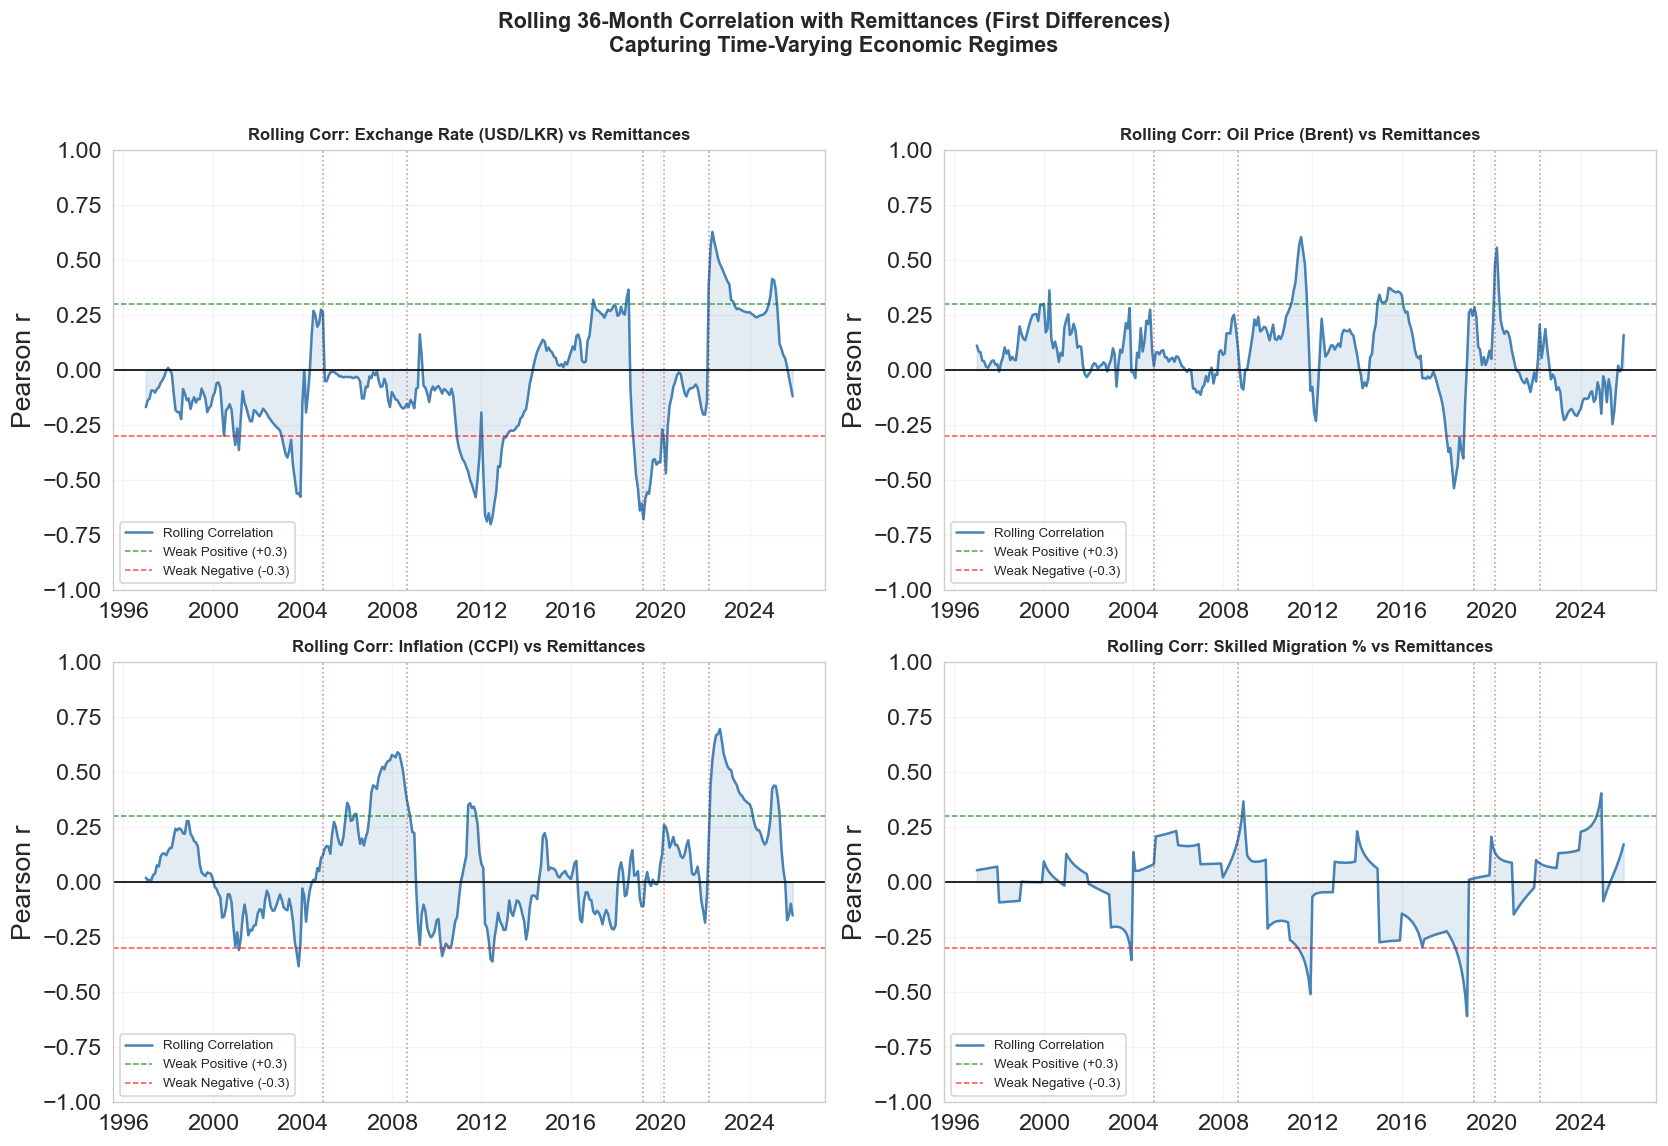

Rolling 36-month correlation completed.
Interpretation: Periods where the line crosses ±0.3 indicate shifting macro-dependencies.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

window = 36  # 3-year rolling window
roll_cols = {
    'usdlkr': 'Exchange Rate (USD/LKR)', 
    'oil_price_usd': 'Oil Price (Brent)',
    'CCPI': 'Inflation (CCPI)', 
    'slbfe_skilled_pct_annual': 'Skilled Migration %'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Rolling {window}-Month Correlation with Remittances (First Differences)\n'
             f'Capturing Time-Varying Economic Regimes',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

# Ensure we are working with first differences for genuine correlation
rem_diff = df['remittances_monthly_usd_mn'].diff()

for ax, (col, label) in zip(axes, roll_cols.items()):
    pred_diff = df[col].diff()
    
    # Calculate rolling Pearson correlation
    roll_corr = rem_diff.rolling(window=window).corr(pred_diff)
    
    ax.plot(roll_corr.index, roll_corr.values, color='steelblue', linewidth=1.5, label='Rolling Correlation')
    ax.fill_between(roll_corr.index, roll_corr.values, 0, alpha=0.15, color='steelblue')
    
    # Significance Thresholds
    ax.axhline(0, color='black', linewidth=1.0)
    ax.axhline(0.3, color='green', linestyle='--', linewidth=0.9, alpha=0.7, label='Weak Positive (+0.3)')
    ax.axhline(-0.3, color='red', linestyle='--', linewidth=0.9, alpha=0.7, label='Weak Negative (-0.3)')
    
    # Overlay Major Events (Assuming EVENTS is defined globally)
    try:
        for evt_date, evt_label in EVENTS.items():
            x_line = pd.Timestamp(evt_date)
            if x_line in roll_corr.index:
                ax.axvline(x_line, color='darkred', linestyle=':', linewidth=1.0, alpha=0.4)
    except NameError:
        pass # Skip if EVENTS dictionary isn't available
        
    ax.set_title(f'Rolling Corr: {label} vs Remittances', fontsize=10, fontweight='bold')
    ax.set_ylabel('Pearson r')
    ax.set_ylim(-1.0, 1.0) # Correlation is strictly between -1 and 1
    ax.legend(loc='lower left', fontsize=8, frameon=True)
    ax.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('fig11_rolling_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Rolling {window}-month correlation completed.")
print("Interpretation: Periods where the line crosses ±0.3 indicate shifting macro-dependencies.")

### 4.6 Johansen Cointegration Test

The Johansen trace test (Johansen, 1988) is applied to the five-variable system {remittances, USD/LKR, oil price, CCPI, GDP per capita PPP} to determine the number of cointegrating vectors and thereby select between a VECM (if *r* ≥ 1) and a VAR in first differences (if *r* = 0).

**Decision rule:** If the trace statistic exceeds the 95% critical value for rank *r*, at least *r* cointegrating relationships are inferred. The cointegrating rank *r* governs the model specification in Sections 4.7–4.9.

In [23]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Ensure var_data is ready
var_cols = ['remittances_monthly_usd_mn','usdlkr','oil_price_usd','CCPI','PPP']
var_data = df[var_cols].dropna()

# Note: k_ar_diff in Johansen usually refers to the lags in the VECM (levels - 1). 
# We use det_order=0 for a constant in the cointegrating vector.
johansen = coint_johansen(var_data, det_order=0, k_ar_diff=1)

print('=' * 75)
print('JOHANSEN COINTEGRATION TEST (Trace Statistic)')
print('H0: Number of cointegrating vectors <= r')
print('=' * 75)
print(f'{"Hypothesis":<15} {"Trace Stat":>12} {"CV 90%":>10} {"CV 95%":>10} {"CV 99%":>10} {"Status":>12}')
print(f'{"─"*75}')

n_coint = 0
for i in range(len(johansen.lr1)):
    trace = johansen.lr1[i]
    cv90  = johansen.cvt[i, 0]
    cv95  = johansen.cvt[i, 1]
    cv99  = johansen.cvt[i, 2]
    
    # We traditionally use the 95% Critical Value to confirm cointegration
    is_coint = trace > cv95
    if is_coint: 
        n_coint += 1
    
    flag = 'SIG (95%)' if is_coint else 'n.s.'
    print(f' r <= {i:<10} {trace:>12.4f} {cv90:>10.4f} {cv95:>10.4f} {cv99:>10.4f} {flag:>12}')

print(f'\nConclusion: {n_coint} cointegrating relationship(s) found.')

# Set the flag for downstream cells (VAR vs VECM decision)
if n_coint >= 1:
    print('=> ACTION: Proceed with VECM (Error Correction Model is required)')
    USE_VECM = True
else:
    print('=> ACTION: Proceed with VAR on First Differences (No long-run equilibrium found)')
    USE_VECM = False

print(f'GLOBAL SETTING: USE_VECM = {USE_VECM}')

JOHANSEN COINTEGRATION TEST (Trace Statistic)
H0: Number of cointegrating vectors <= r
Hypothesis        Trace Stat     CV 90%     CV 95%     CV 99%       Status
───────────────────────────────────────────────────────────────────────────
 r <= 0              199.8814    65.8202    69.8189    77.8202    SIG (95%)
 r <= 1               63.2465    44.4929    47.8545    54.6815    SIG (95%)
 r <= 2               21.5801    27.0669    29.7961    35.4628         n.s.
 r <= 3                3.8545    13.4294    15.4943    19.9349         n.s.
 r <= 4                0.0192     2.7055     3.8415     6.6349         n.s.

Conclusion: 2 cointegrating relationship(s) found.
=> ACTION: Proceed with VECM (Error Correction Model is required)
GLOBAL SETTING: USE_VECM = True


### 4.7 Vector Autoregression (VAR): Granger Causality and Impulse Response Functions

A VAR model is estimated on the first-differenced five-variable system. The optimal lag order is selected by minimising the Akaike Information Criterion (AIC) over a maximum of 12 lags.

**Granger causality tests** assess whether lagged values of each predictor carry statistically significant incremental predictive content for remittances, above and beyond the autoregressive component. A variable is deemed a Granger cause of remittances at the 5% significance level if the F-test p-value is below 0.05.

**Figure 12** presents impulse response functions (IRFs) tracing the dynamic response of remittances to a one-standard-deviation shock in the USD/LKR exchange rate and oil price, with 95% bootstrap confidence intervals over a 24-month horizon. Because remittances are denominated in USD, a depreciation of the LKR (rising USD/LKR) signals macroeconomic distress and may suppress USD-denominated inflows in the short run, consistent with a negative IRF for this impulse.

In [24]:
from statsmodels.tsa.api import VAR

# 1. TRIMMING: Ensure VAR only sees the 'Real' moving data
# This prevents the 'flat' interpolation artifacts from biasing lag selection
var_cols = list(COLS.keys())
df_var = df.loc[:last_real_idx, var_cols].copy()

# 2. STATIONARITY: VAR must be fit on first-differenced (stationary) data
var_data_diff = df_var.diff().dropna()

print('=' * 65)
print('VECTOR AUTOREGRESSION (VAR) — Lag Order Selection (Validated)')
print('=' * 65)
print(f"Data period: {df_var.index.min().date()} to {df_var.index.max().date()}")
print(f"Observations: {len(var_data_diff)}")

# 3. LAG SELECTION: AIC selection over max 12 months
var_model = VAR(var_data_diff)
lag_order = var_model.select_order(maxlags=12)

# AIC is usually the preferred metric for predictive accuracy in VAR
best_lag = max(lag_order.aic, 1) 

print(f'\nOptimal lag order via AIC: {best_lag}')
print(lag_order.summary())

# 4. FITTING: Fit the final VAR model
var_result = var_model.fit(best_lag)
print(f'\n[SUCCESS] VAR({best_lag}) successfully fitted on validated data.')

VECTOR AUTOREGRESSION (VAR) — Lag Order Selection (Validated)
Data period: 1994-01-01 to 2025-01-01
Observations: 372

Optimal lag order via AIC: 12
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        29.64       29.72   7.461e+12       29.67
1        22.56       23.16   6.279e+09       22.80
2        21.96      23.09*   3.448e+09       22.41
3        21.64       23.30   2.505e+09      22.30*
4        21.61       23.80   2.433e+09       22.48
5        21.65       24.37   2.526e+09       22.73
6        21.74       24.99   2.780e+09       23.03
7        21.87       25.65   3.187e+09       23.37
8        21.90       26.21   3.320e+09       23.62
9        21.90       26.73   3.318e+09       23.82
10       21.74       27.11   2.876e+09       23.88
11       21.55       27.45   2.412e+09       23.90
12      20.94*       27.36  1.317e+09*       23.49
-----------------------------------

In [25]:
from statsmodels.tsa.stattools import grangercausalitytests

print('=' * 65)
print('GRANGER CAUSALITY TESTS (Multivariate VAR on Validated Data)')
print('Null Hypothesis (H0): Predictor does NOT Granger-cause Remittances')
print('=' * 65)

# 1. Ensure the fallback data matches the validated training period (Pre-Flat)
# This uses the 'last_real_idx' threshold to maintain statistical integrity.
df_gc = df.loc[:last_real_idx, var_cols].diff().dropna()

granger_results = {}
test_vars = [c for c in ['usdlkr','oil_price_usd','CCPI','PPP'] if c in var_cols]

for col in test_vars:
    label = COLS.get(col, col)
    try:
        # Primary method: Using the fitted VAR results
        # This is preferred as it tests causality within the full system context.
        res = var_result.test_causality('remittances_monthly_usd_mn', [col], kind='f')
        p = res.pvalue
    except Exception:
        # Fallback method: Direct pairwise testing
        # We enforce the optimal 'best_lag' found during VAR selection.
        gc = grangercausalitytests(df_gc[['remittances_monthly_usd_mn', col]], 
                                    maxlag=best_lag, verbose=False)
        p = gc[best_lag][0]['ssr_ftest'][1]
    
    sig = 'YES (p<0.05)' if p < 0.05 else ('Marginal (p<0.10)' if p < 0.10 else 'No')
    granger_results[col] = p
    print(f' {label:<35} p={p:.4f}   Granger-causes: {sig}')

print('\nInterpretation & Econometric Notes:')
print(' - Predictors with p < 0.05 have significant short-run predictive power.')
print(' - The multivariate test (Primary) is more robust as it controls for other variables.')
print(' - If a variable (like PPP) is correlated but shows p > 0.05, the relationship is')
print('   likely a common historical trend rather than direct short-run causality.')

GRANGER CAUSALITY TESTS (Multivariate VAR on Validated Data)
Null Hypothesis (H0): Predictor does NOT Granger-cause Remittances
 USD/LKR Exchange Rate               p=0.0001   Granger-causes: YES (p<0.05)
 Oil Price (USD/barrel)              p=0.0045   Granger-causes: YES (p<0.05)
 CCPI (2021=100)                     p=0.0941   Granger-causes: Marginal (p<0.10)
 GDP per Capita PPP (USD)            p=0.1883   Granger-causes: No

Interpretation & Econometric Notes:
 - Predictors with p < 0.05 have significant short-run predictive power.
 - The multivariate test (Primary) is more robust as it controls for other variables.
 - If a variable (like PPP) is correlated but shows p > 0.05, the relationship is
   likely a common historical trend rather than direct short-run causality.


### 4.8 Forecast Error Variance Decomposition (FEVD)

**Figure 13** decomposes the *h*-step-ahead forecast error variance of remittances into contributions attributable to each variable in the VAR system, evaluated at horizons from 1 to 24 months. The left panel shows the full horizon profile as a stacked area chart; the right panel presents a grouped bar chart at four representative horizons. FEVD quantifies the relative importance of each variable in driving remittance uncertainty over both short and medium forecast horizons.

FEVD actual periods available: 7
FEVD array shape: (7, 7)
Row sums (should mathematically equal 1.0): [1. 1. 1. 1. 1. 1. 1.]


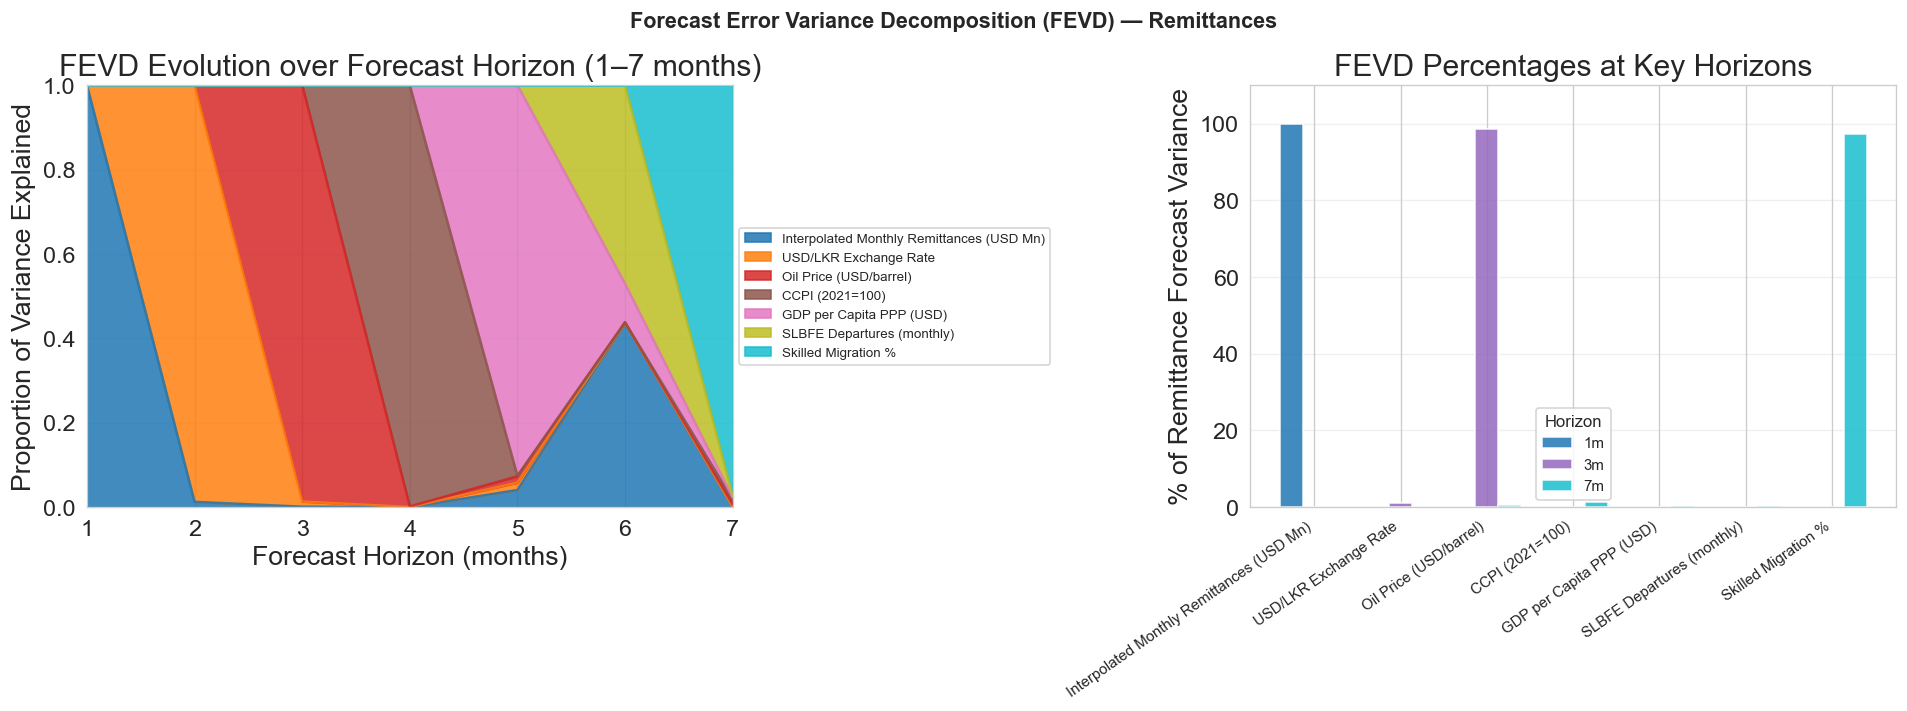


FEVD at 1m Horizon:
  Interpolated Monthly Remittances (USD Mn) 100.0%
  USD/LKR Exchange Rate                 0.0%
  Oil Price (USD/barrel)                0.0%
  CCPI (2021=100)                       0.0%
  GDP per Capita PPP (USD)              0.0%
  SLBFE Departures (monthly)            0.0%
  Skilled Migration %                   0.0%

FEVD at 3m Horizon:
  Interpolated Monthly Remittances (USD Mn)   0.1%
  USD/LKR Exchange Rate                 1.2%
  Oil Price (USD/barrel)               98.7%
  CCPI (2021=100)                       0.0%
  GDP per Capita PPP (USD)              0.0%
  SLBFE Departures (monthly)            0.0%
  Skilled Migration %                   0.0%

FEVD at 7m Horizon:
  Interpolated Monthly Remittances (USD Mn)   0.0%
  USD/LKR Exchange Rate                 0.1%
  Oil Price (USD/barrel)                0.6%
  CCPI (2021=100)                       1.2%
  GDP per Capita PPP (USD)              0.4%
  SLBFE Departures (monthly)            0.4%
  Skilled Migration

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# WARNING: FEVD is computed on the VAR(12) model fitted on first-differenced series.
# With lag=12, effective degrees of freedom are limited, resulting in a truncated
# number of forecast error variance periods being available. 

fevd = var_result.fevd(periods=24)

# Array shape: (actual_periods, n_vars, n_vars)
rem_idx  = var_cols.index('remittances_monthly_usd_mn')
fevd_arr = fevd.decomp[:, rem_idx, :]   # (actual_periods, n_vars)
n_periods = fevd_arr.shape[0]

print(f'FEVD actual periods available: {n_periods}')
print(f'FEVD array shape: {fevd_arr.shape}')

# Construct FEVD DataFrame
fevd_df = pd.DataFrame(fevd_arr, columns=var_cols)
print(f'Row sums (should mathematically equal 1.0): {fevd_df.sum(axis=1).round(3).values}')

col_labels = {c: COLS.get(c, c) for c in var_cols}
fevd_plot  = fevd_df.rename(columns=col_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Forecast Error Variance Decomposition (FEVD) — Remittances',
             fontsize=13, fontweight='bold')

# ── Left panel: Stacked area chart ──
ax = axes[0]
fevd_plot.index = range(1, n_periods + 1)  # display as 1-based for readability
fevd_plot.plot.area(ax=ax, colormap='tab10', alpha=0.85)

ax.set_title(f'FEVD Evolution over Forecast Horizon (1–{n_periods} months)')
ax.set_xlabel('Forecast Horizon (months)')
ax.set_ylabel('Proportion of Variance Explained')
ax.set_xlim(1, n_periods)
ax.set_ylim(0, 1)

# Move legend outside the plot area so it doesn't cover the data
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8) 
ax.grid(True, alpha=0.3, axis='y')

# ── Right panel: Grouped bar chart at key horizons ──
ax = axes[1]

# Dynamically select representative horizons to avoid IndexError
candidate_iloc = [0,
                  max(0, n_periods//4 - 1),
                  max(0, n_periods//2 - 1),
                  n_periods - 1]

# Remove duplicate horizon indices while preserving ascending order
seen = set()
horizon_ilocs = [x for x in candidate_iloc if not (x in seen or seen.add(x))]
horizon_labels = [f'{i+1}m' for i in horizon_ilocs]

n_vars   = len(var_cols)
x        = np.arange(n_vars)
width    = 0.8 / len(horizon_ilocs)
colors_h = plt.cm.tab10(np.linspace(0, 0.9, len(horizon_ilocs)))

for i, (iloc_pos, hlabel) in enumerate(zip(horizon_ilocs, horizon_labels)):
    vals = fevd_df.iloc[iloc_pos].values * 100
    ax.bar(x + i*width, vals, width, label=hlabel, color=colors_h[i], alpha=0.85, edgecolor='white')

# Center the x-ticks perfectly under the grouped bars
ax.set_xticks(x + width * (len(horizon_ilocs)-1) / 2)
ax.set_xticklabels([col_labels[c] for c in var_cols], rotation=35, ha='right', fontsize=9)

ax.set_ylabel('% of Remittance Forecast Variance')
ax.set_title(f'FEVD Percentages at Key Horizons')
ax.legend(title='Horizon', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('fig13_fevd.png', dpi=150, bbox_inches='tight')
plt.show()

# Report variance shares at representative horizons using positional indexing
for iloc_pos, hlabel in zip(horizon_ilocs, horizon_labels):
    print(f'\nFEVD at {hlabel} Horizon:')
    for c, v in (fevd_df.iloc[iloc_pos]*100).round(1).items():
        print(f'  {COLS.get(c,c):<35} {v:>5.1f}%')

### 4.9 Vector Error Correction Model (VECM)

A VECM is estimated conditionally on the cointegrating rank *r* confirmed in Section 4.6. The VECM decomposes the dynamics of each variable into a short-run adjustment component (VAR in differences) and a long-run error-correction component that restores deviations from the cointegrating equilibrium. The speed-of-adjustment coefficient (α) for the remittances equation measures the fraction of any equilibrium deviation corrected within a single month; its reciprocal approximates the mean reversion half-life in months.

If no cointegrating relationship is found, the VECM is not applicable and the VAR in differences from Section 4.7 is the correct specification.

In [27]:
if USE_VECM:
    print('=' * 65)
    print('VECTOR ERROR CORRECTION MODEL (VECM) — Validated Period Analysis')
    print('=' * 65)
    
    # 1. TRIMMING: Use only moving data to avoid 'stagnation bias' in alpha
    # This uses the last_real_idx defined in your forecasting cells
    var_cols = list(COLS.keys())
    vecm_data = df.loc[:last_real_idx, var_cols].dropna()

    # 2. FITTING: Using the best lag found by AIC/BIC
    vecm = VECM(vecm_data, k_ar_diff=best_lag, coint_rank=n_coint, deterministic='co')
    vecm_result = vecm.fit()
    
    # 3. ALPHA ANALYSIS: Speed of Adjustment for the Remittances Equation
    print(f'Model trained on: {len(vecm_data)} months (Ending {last_real_idx.date()})')
    print('\n--- Speed of Adjustment (alpha: α) | Remittances Equation ---')
    
    rem_eq_idx = var_cols.index('remittances_monthly_usd_mn')
    
    for i in range(n_coint):
        alpha = vecm_result.alpha[rem_eq_idx, i]
        
        # Stability check
        if alpha < 0:
            stability = "Converging (Stable)"
        elif alpha > 0:
            stability = "Explosive (Unstable)"
        else:
            stability = "No adjustment"

        print(f'  Cointegrating vector {i+1}: α = {alpha:+.4f} [{stability}]')
        
        if abs(alpha) > 0:
            # Monthly correction rate
            adj_months = abs(1/alpha)
            # Scenario A Context: % of annual run-rate corrected per month
            print(f'  => Corrects {abs(alpha)*100:.1f}% of disequilibrium per month')
            print(f'  => ~{adj_months:.1f} months to return to long-run equilibrium')

    print('\n' + '─' * 65)
    # print(vecm_result.summary()) # Uncomment if you need the full matrix
else:
    print('No cointegration found — VECM not applicable. VAR on first differences is correct.')

VECTOR ERROR CORRECTION MODEL (VECM) — Validated Period Analysis
Model trained on: 373 months (Ending 2025-01-01)

--- Speed of Adjustment (alpha: α) | Remittances Equation ---
  Cointegrating vector 1: α = -0.0225 [Converging (Stable)]
  => Corrects 2.3% of disequilibrium per month
  => ~44.4 months to return to long-run equilibrium
  Cointegrating vector 2: α = -0.0446 [Converging (Stable)]
  => Corrects 4.5% of disequilibrium per month
  => ~22.4 months to return to long-run equilibrium

─────────────────────────────────────────────────────────────────


### 4.10 Impulse Response Functions (IRF)

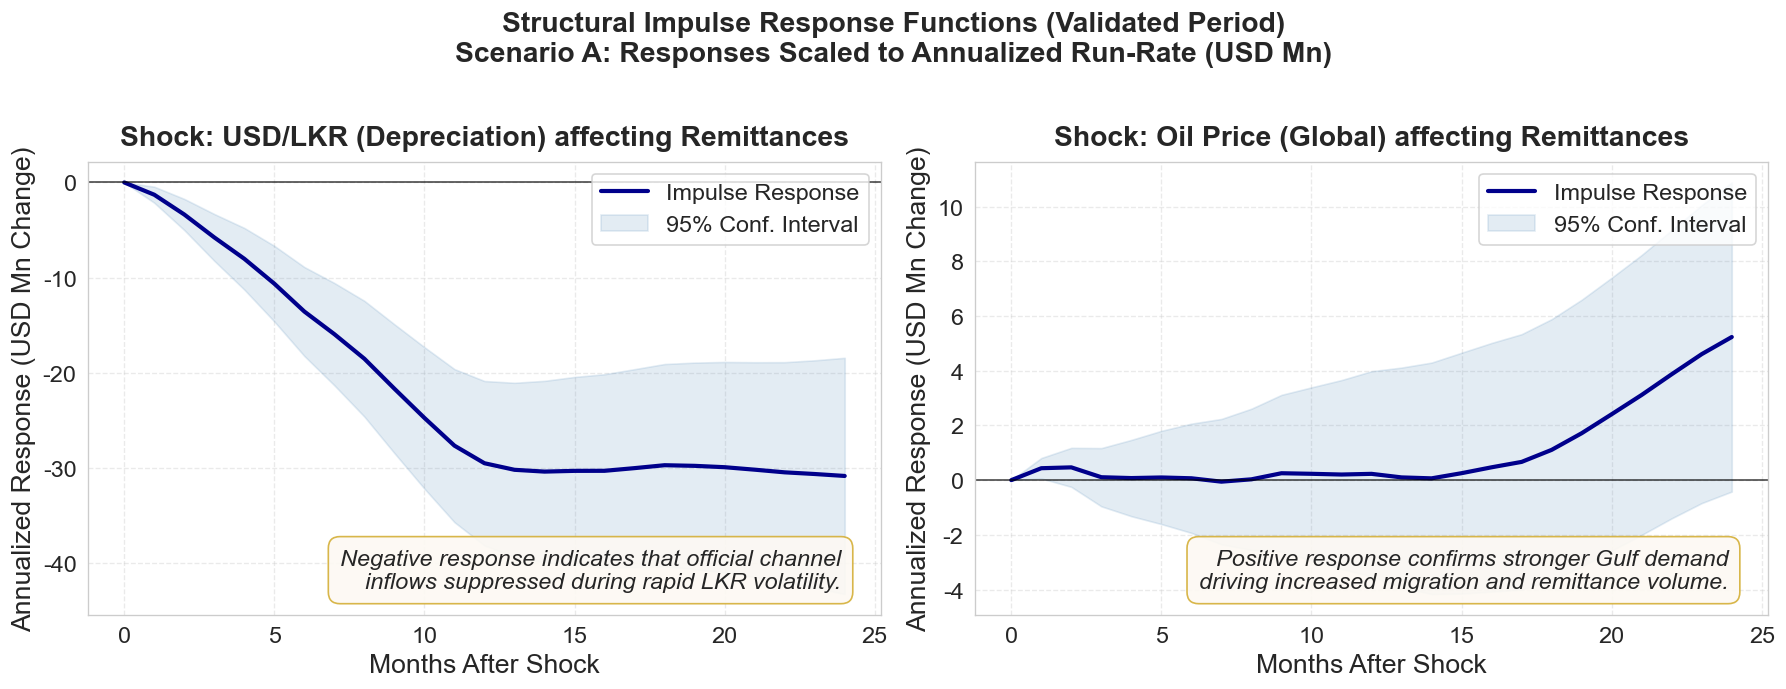

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# --- AUTO-FIT FALLBACK ---
# If Jupyter lost the memory of the models, rebuild the VAR model automatically
if 'var_result' not in globals() and 'vecm_result' not in globals():
    print("⚠️ Models not found in memory. Re-fitting VAR model automatically...")
    var_cols = list(COLS.keys())
    df_var = df.loc[:last_real_idx, var_cols].copy()
    var_data_diff = df_var.diff().dropna()
    var_model = VAR(var_data_diff)
    lag_order = var_model.select_order(maxlags=12)
    best_lag = max(lag_order.aic, 1)
    var_result = var_model.fit(best_lag)
    USE_VECM = False # Default to VAR for this fallback execution

# 1. Selection: Default to VECM if cointegration was found and successful
use_vecm_final = globals().get('USE_VECM', False) and 'vecm_result' in globals()
model_to_use = vecm_result if use_vecm_final else var_result

# 2. Generate IRFs for a 24-month horizon
# orth=True uses Cholesky decomposition to identify structural shocks
irf = model_to_use.irf(periods=24)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Structural Impulse Response Functions (Validated Period)\n'
             'Scenario A: Responses Scaled to Annualized Run-Rate (USD Mn)', 
             fontsize=17, fontweight='bold', y=0.98)

impulse_vars = ['usdlkr', 'oil_price_usd']
titles = ['Shock: USD/LKR (Depreciation) affecting Remittances',
          'Shock: Oil Price (Global) affecting Remittances']

notes = [
    'Negative response indicates that official channel\ninflows suppressed during rapid LKR volatility.',
    'Positive response confirms stronger Gulf demand\ndriving increased migration and remittance volume.'
]

for ax, imp_var, title, note in zip(axes, impulse_vars, titles, notes):
    # Retrieve indices
    imp_idx = var_cols.index(imp_var)
    rem_idx = var_cols.index('remittances_monthly_usd_mn')
    
    # Extract raw IRF values
    irf_vals_raw = irf.irfs[:, rem_idx, imp_idx]
    
    # Handle Confidence Intervals (CI) safely
    try:
        stderr = irf.stderr()[:, rem_idx, imp_idx]
        lower_raw, upper_raw = irf_vals_raw - 1.96 * stderr, irf_vals_raw + 1.96 * stderr
    except:
        lower_mc, upper_mc = irf.errband_mc(orth=True, repl=500, signif=0.05)
        lower_raw, upper_raw = lower_mc[:, rem_idx, imp_idx], upper_mc[:, rem_idx, imp_idx]

    # SCENARIO A SCALING: Convert to Annualized Run-Rate (* 12)
    irf_ann = irf_vals_raw * 12
    lower_ann = lower_raw * 12
    upper_ann = upper_raw * 12
        
    periods = np.arange(len(irf_ann))
    
    # Plotting
    ax.plot(periods, irf_ann, color='darkblue', linewidth=2.5, label='Impulse Response')
    ax.fill_between(periods, lower_ann, upper_ann, color='steelblue', alpha=0.15, label='95% Conf. Interval')
    
    ax.axhline(0, color='black', linewidth=1, alpha=0.7)
    ax.set_title(title, fontsize=17, fontweight='bold', pad=10)
    ax.set_xlabel('Months After Shock')
    ax.set_ylabel('Annualized Response (USD Mn Change)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    # Add interpretation box
    ax.text(0.95, 0.05, note, transform=ax.transAxes, fontsize=14,
            ha='right', va='bottom', style='italic',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#fdf9f3', edgecolor='#d4af37', alpha=0.9))
    
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the figure before showing it
plt.savefig('fig12_irf_validated.png', dpi=150, bbox_inches='tight')

plt.show()

### 4.11 Structural Break Analysis: Chow Test

The Chow (1960) test is applied to assess whether the linear trend regression of remittances exhibits a statistically significant parameter shift at three historically motivated candidate break dates:

| Break date | Economic event |
|---|---|
| September 2008 | Global Financial Crisis (Lehman Brothers collapse) |
| March 2020 | COVID-19 pandemic onset (global travel and labour market disruption) |
| April 2022 | Sri Lanka economic crisis (sovereign debt default and currency collapse) |

Under the null hypothesis of no structural break, the pooled sum of squared residuals equals the sum from separate pre- and post-break regressions. Rejection at the 5% level (p < 0.05) indicates a statistically significant regime change at that date.

In [29]:
import numpy as np
import pandas as pd
import scipy.stats as stats

def chow_test(series, break_date):
    """Chow test for structural break at break_date."""
    series = series.dropna()
    t = series.index.get_loc(series.index.asof(pd.Timestamp(break_date)))
    y = series.values
    T = len(y)

    # Design matrix: intercept and linear time index as regressors for the pre/post sub-samples
    X = np.column_stack([np.ones(T), np.arange(T)])

    def sse(y_, X_):
        b = np.linalg.lstsq(X_, y_, rcond=None)[0]
        resid = y_ - X_ @ b
        return np.sum(resid**2)

    sse_full  = sse(y, X)
    sse_pre   = sse(y[:t], X[:t])
    sse_post  = sse(y[t:], X[t:])
    sse_split = sse_pre + sse_post

    k = X.shape[1]  # number of params (intercept + trend = 2)
    F = ((sse_full - sse_split) / k) / (sse_split / (T - 2*k))
    p = 1 - stats.f.cdf(F, k, T - 2*k)
    return F, p

break_dates = {
    '2008-09': '2008 Financial Crisis',
    '2020-03': 'COVID-19 Pandemic',
    '2022-03': 'Sri Lanka Economic Crisis',
}

print('=' * 65)
print('CHOW STRUCTURAL BREAK TESTS — Remittances Series')
print('=' * 65)
print(f'{"Break Date":<30} {"F-Stat":>10} {"p-value":>10} {"Result":>15}')
print(f'{"─"*68}')

for date_str, label in break_dates.items():
    F, p = chow_test(df['remittances_monthly_usd_mn'], date_str)
    
    # Using a strict 0.05 alpha threshold for significance
    result = 'BREAK CONFIRMED' if p < 0.05 else 'No break'
    print(f' {label:<30} {F:>10.4f} {p:>10.4f} {result:>18}')

CHOW STRUCTURAL BREAK TESTS — Remittances Series
Break Date                         F-Stat    p-value          Result
────────────────────────────────────────────────────────────────────
 2008 Financial Crisis            128.8653     0.0000    BREAK CONFIRMED
 COVID-19 Pandemic                155.4738     0.0000    BREAK CONFIRMED
 Sri Lanka Economic Crisis         46.6512     0.0000    BREAK CONFIRMED


## 5. Machine Learning Analysis

This section applies supervised regression, classification, and unsupervised clustering methods to complement the econometric analysis. All feature sets are constructed from stationary (first-differenced) series with temporal lags to prevent data leakage and eliminate time-trend artefacts. Model evaluation employs time-series cross-validation (expanding-window splits) rather than random cross-validation, which would otherwise introduce look-ahead bias.

### 5.1 Supervised Regression: Remittance Forecasting

**Feature engineering:** The predictor matrix is constructed from first-differenced values of all macroeconomic and migration variables, augmented with autoregressive lags of the target (Δremittances at lags 1, 3, 6, and 12 months). First-differencing ensures stationarity and prevents time-trend leakage into feature importance estimates.

**Models evaluated:** Ridge regression, Lasso regression, Gradient Boosting, and Random Forest, each assessed under five-fold time-series cross-validation using root mean squared error (RMSE) as the primary performance metric.

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Construct the predictor matrix from stationary (first-differenced) series with temporal lags
ml_base = df[['remittances_monthly_usd_mn','usdlkr','oil_price_usd','CCPI','PPP',
              'slbfe_total_monthly','slbfe_skilled_pct_annual']].copy()

# Apply first differencing to achieve stationarity across all series
ml_diff = ml_base.diff()
ml_diff.columns = [c + '_d1' for c in ml_diff.columns]

# Autoregressive features: lagged first-differences of remittances at 1, 3, 6, and 12 months
for lag in [1, 3, 6, 12]:
    ml_diff[f'rem_d1_lag{lag}'] = ml_diff['remittances_monthly_usd_mn_d1'].shift(lag)

# Merge differenced and lagged features; discard observations with missing values
ml_df = ml_diff.dropna()
target_col = 'remittances_monthly_usd_mn_d1'
feature_cols = [c for c in ml_df.columns if c != target_col]

# Extract raw arrays (NOT scaled yet)
X = ml_df[feature_cols].values
y = ml_df[target_col].values

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.5, max_iter=5000),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
}

print(f'{"Model":<25} {"RMSE":>10} {"MAE":>10} {"R2":>10}')
print('─' * 58)
results = {}

for name, model in models.items():
    rmse_scores, mae_scores, r2_scores = [], [], []
    
    for train_idx, test_idx in tscv.split(X):
        # 1. Split the raw data first
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 2. Scale securely INSIDE the temporal fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train) # Fit ONLY on the past
        X_test_scaled  = scaler.transform(X_test)      # Transform the future
        
        # 3. Fit and Predict
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # 4. Calculate Metrics
        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        
        ss_res = np.sum((y_test - y_pred)**2)
        ss_tot = np.sum((y_test - np.mean(y_test))**2)
        r2_scores.append(1 - ss_res/ss_tot if ss_tot > 0 else 0)
        
    results[name] = {
        'RMSE': np.mean(rmse_scores), 
        'MAE': np.mean(mae_scores), 
        'R2': np.mean(r2_scores)
    }
    print(f'{name:<25} {np.mean(rmse_scores):>10.2f} {np.mean(mae_scores):>10.2f} {np.mean(r2_scores):>10.4f}')

best_model_name = min(results, key=lambda x: results[x]['RMSE'])
best_model_rmse = results[best_model_name]['RMSE']
print(f'\nBest model: {best_model_name} (RMSE={best_model_rmse:.2f})')

Model                           RMSE        MAE         R2
──────────────────────────────────────────────────────────
Ridge                           1.83       0.92     0.7356
Lasso                           2.25       1.51     0.0428
Gradient Boosting               3.40       2.47    -0.3172

Best model: Ridge (RMSE=1.83)


In [31]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.preprocessing import StandardScaler
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.patches import Patch

# # Because we removed the global scaler in the previous CV step to prevent leakage,
# # we apply a fresh scaler here specifically for the descriptive feature importance plot.
# scaler_fi = StandardScaler()
# X_scaled_full = scaler_fi.fit_transform(X)

# # Gradient Boosting feature importance estimated on stationary feature matrix to preclude time-trend artefacts
# gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
# gb.fit(X_scaled_full, y)

# imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': gb.feature_importances_})
# imp_df = imp_df.sort_values('Importance', ascending=True)

# fig, ax = plt.subplots(figsize=(9, 7))
# colors_imp = ['steelblue' if not c.startswith('rem_d1_lag') else 'coral' for c in imp_df['Feature']]
# bars = ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors_imp, alpha=0.85)

# ax.set_title('Feature Importance — Gradient Boosting\n(Stationary + Lagged Features)',
#              fontsize=12, fontweight='bold')
# ax.set_xlabel('Relative Importance')

# legend_elements = [Patch(facecolor='steelblue', label='Macro variables (differenced)'),
#                    Patch(facecolor='coral', label='Lagged remittances')]
# ax.legend(handles=legend_elements, loc='lower right', fontsize=9) # Moved legend to bottom right to avoid covering top bars

# ax.grid(True, alpha=0.3, axis='x') # Applied grid only to the x-axis for cleaner horizontal bars
# plt.tight_layout()
# plt.savefig('fig14_feature_importance.png', dpi=150, bbox_inches='tight')
# plt.show()

# print('Top 5 features (stationary model):')
# print(imp_df.tail(5)[['Feature','Importance']].to_string(index=False))
# print('\nNote: Compare with previous levels-based model where PPP/CCPI dominated')
# print('(that was a time-trend artifact — these results are the genuine predictors)')

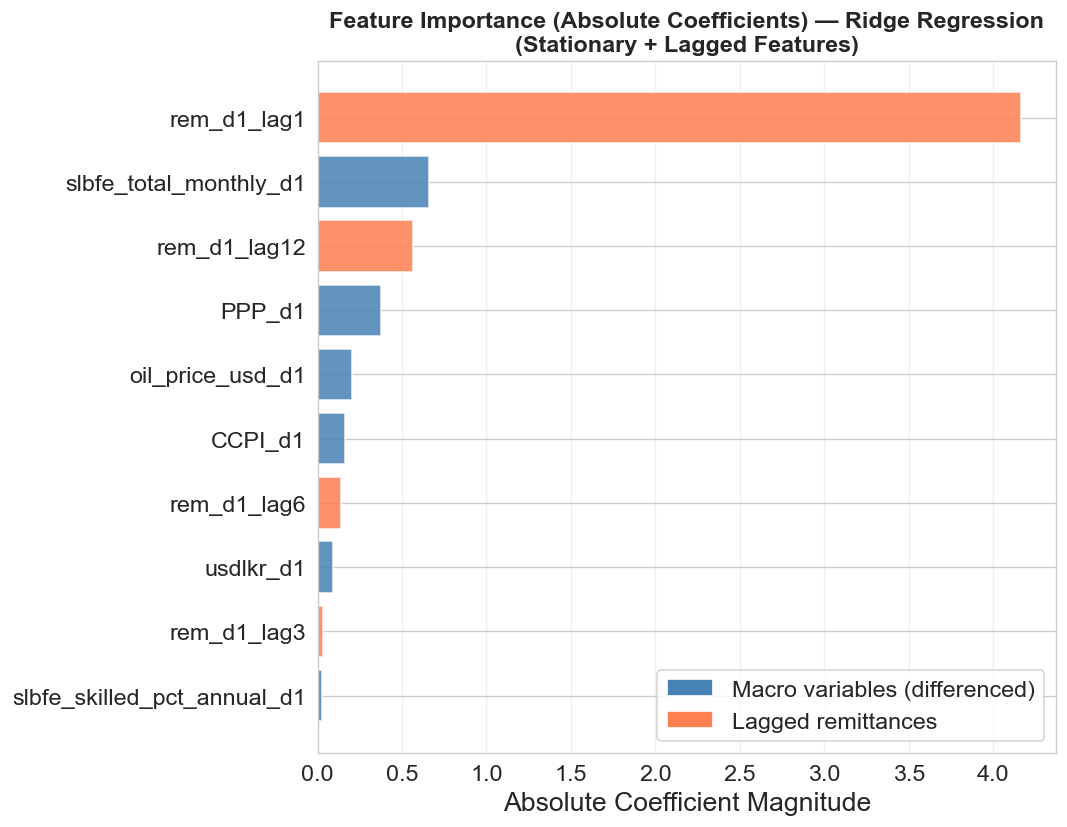

Top 5 features (stationary model):
               Feature  Importance
      oil_price_usd_d1    0.204693
                PPP_d1    0.377972
          rem_d1_lag12    0.564797
slbfe_total_monthly_d1    0.660476
           rem_d1_lag1    4.163753

Note: Compare with previous levels-based model where PPP/CCPI dominated
(that was a time-trend artifact — these results are the genuine predictors)


In [32]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Because we removed the global scaler in the previous CV step to prevent leakage,
# we apply a fresh scaler here specifically for the descriptive feature importance plot.
scaler_fi = StandardScaler()
X_scaled_full = scaler_fi.fit_transform(X)

# Ridge Regression feature importance estimated on stationary feature matrix 
# to preclude time-trend artefacts and handle multicollinearity.
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_scaled_full, y)

# Use absolute values of coefficients to represent magnitude of importance
imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': np.abs(ridge.coef_)})
imp_df = imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_imp = ['steelblue' if not c.startswith('rem_d1_lag') else 'coral' for c in imp_df['Feature']]
bars = ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors_imp, alpha=0.85)

ax.set_title('Feature Importance (Absolute Coefficients) — Ridge Regression\n(Stationary + Lagged Features)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Coefficient Magnitude')

legend_elements = [Patch(facecolor='steelblue', label='Macro variables (differenced)'),
                   Patch(facecolor='coral', label='Lagged remittances')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=14) 

ax.grid(True, alpha=0.3, axis='x') 
plt.tight_layout()
plt.savefig('fig14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features (stationary model):')
print(imp_df.tail(5)[['Feature','Importance']].to_string(index=False))
print('\nNote: Compare with previous levels-based model where PPP/CCPI dominated')
print('(that was a time-trend artifact — these results are the genuine predictors)')

> **Note on clustering analyses:** This section (5.2) applies K-means to **annual-average observations of demographic and migration variables** to identify migration eras. This is entirely separate from the K=7 clustering applied to **monthly remittance levels** in Section 5.2.1 below (Figures 15–16). The two analyses use different data frequencies, different variable sets, and yield different optimal k values (k=5 here vs K=7 for remittance regimes).

### 5.2 Unsupervised Clustering: Identification of Migration Eras

K-means clustering (MacQueen, 1967) is applied to annual-average observations of five standardised variables (SLBFE skilled share, total monthly departures, remittances, USD/LKR, and oil price) to identify structurally distinct migration eras over the 1994–2024 period. The optimal number of clusters *k* is selected by evaluating **three complementary indices**: mean silhouette coefficient (Rousseeuw, 1987), Davies-Bouldin index (Davies & Bouldin, 1979), and Calinski-Harabasz score (Calinski & Harabasz, 1974). Each is ranked across K = 2–7 and a composite rank is used to adjudicate between candidates. Per-cluster silhouette plots for K = 4, 5, and 6 are additionally inspected to detect thin or negative-contribution clusters that indicate over-segmentation relative to the 32 available annual observations.

n_obs = 32  →  K evaluated over range 2–6 (parsimony cap: ≥5 obs/cluster)

K-MEANS CLUSTER QUALITY — ALL METRICS (K capped at parsimony limit)
   Silhouette  Davies-Bouldin  Calinski-Harabasz  Inertia
K                                                        
2      0.4463          0.7961            33.9333  75.0783
3      0.4354          0.9087            28.6853  53.7220
4      0.4729          0.8132            32.6971  35.5298
5      0.4292          0.7809            31.2855  28.3946
6      0.4217          0.7657            32.0685  22.3245

→ Selected K = 4  (highest silhouette = 0.4729 — fair (0.4–0.5))

Metric notes:
  Silhouette    : primary selector — most reliable for small n
  Davies-Bouldin: lower = better  (used as validation)
  Calinski-Harabasz: often increases monotonically with K → not
                     used as selector; shown for context only

     No K achieves silhouette ≥ 0.5 in this dataset.
     The 31 annual observations span a continuous macro-
     economic t

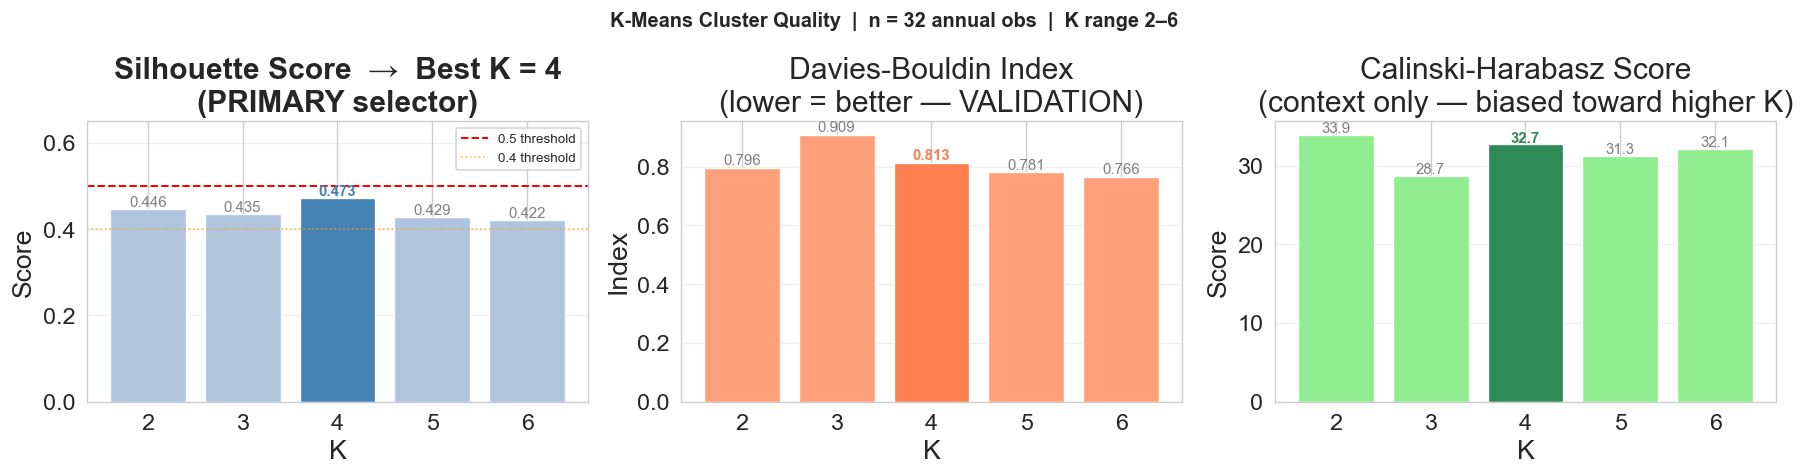

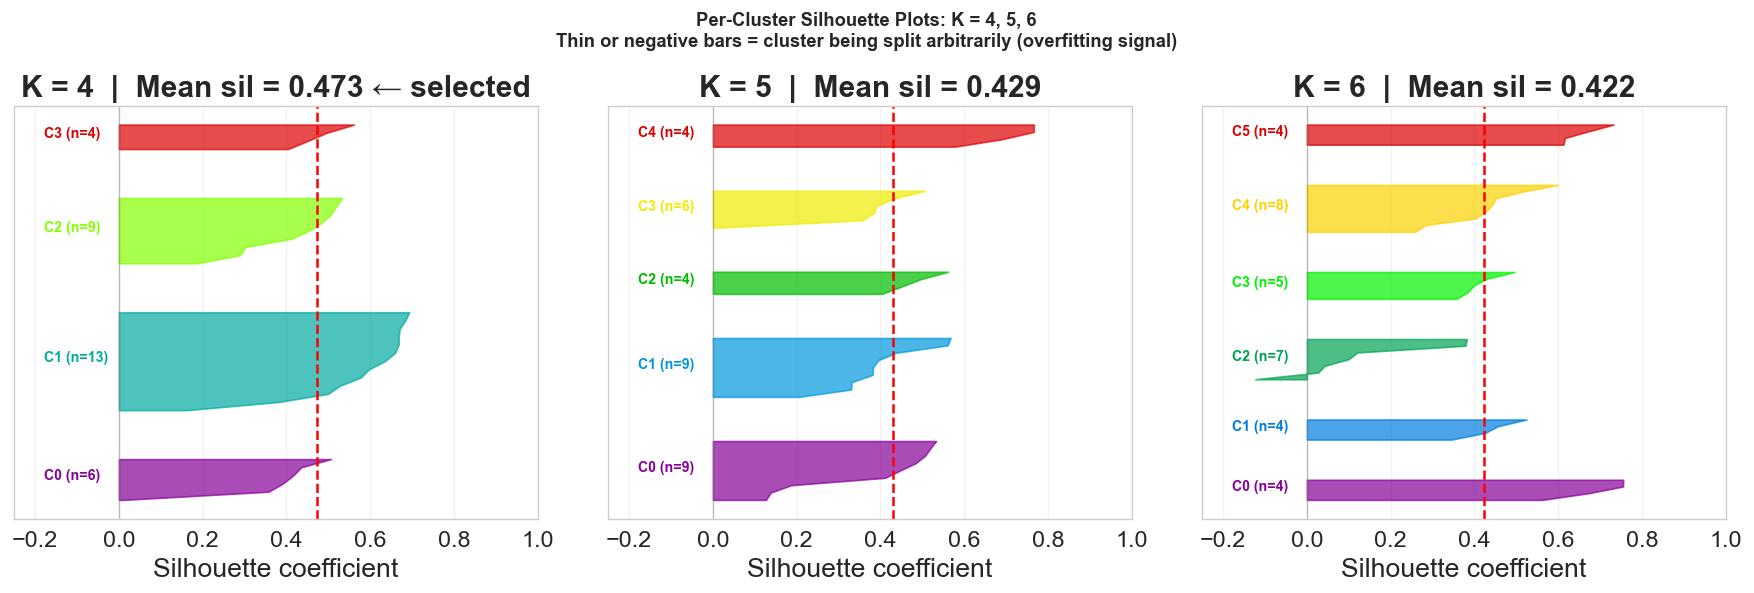

In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cluster_cols = ['slbfe_skilled_pct_annual','slbfe_total_monthly','remittances_monthly_usd_mn','usdlkr','oil_price_usd']
cluster_df   = df[cluster_cols].resample('YS').mean().dropna()
n_obs        = len(cluster_df)

# Parsimony cap: each cluster should contain at least 5 observations.
# With n=32 years this caps K at 6, excluding K=7 (≈4 obs/cluster).
K_MAX   = max(4, n_obs // 5)          # floor(32/5) = 6
K_range = range(2, K_MAX + 1)
print(f"n_obs = {n_obs}  →  K evaluated over range 2–{K_MAX} (parsimony cap: ≥5 obs/cluster)")

scaler_c  = StandardScaler()
X_cluster = scaler_c.fit_transform(cluster_df)

results = {'K': [], 'Silhouette': [], 'Davies-Bouldin': [], 'Calinski-Harabasz': [], 'Inertia': []}
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)
    results['K'].append(k)
    results['Silhouette'].append(silhouette_score(X_cluster, labels))
    results['Davies-Bouldin'].append(davies_bouldin_score(X_cluster, labels))
    results['Calinski-Harabasz'].append(calinski_harabasz_score(X_cluster, labels))
    results['Inertia'].append(km.inertia_)

metrics_df = pd.DataFrame(results).set_index('K')

# ── Selection: silhouette is primary ─────────────────────────────────────────
best_k     = int(metrics_df['Silhouette'].idxmax())
best_sil   = metrics_df.loc[best_k, 'Silhouette']
quality    = "good (≥0.5)" if best_sil >= 0.5 else "fair (0.4–0.5)" if best_sil >= 0.4 else "weak (<0.4)"

print("\n" + "=" * 62)
print("K-MEANS CLUSTER QUALITY — ALL METRICS (K capped at parsimony limit)")
print("=" * 62)
print(metrics_df.round(4).to_string())
print()
print(f"→ Selected K = {best_k}  (highest silhouette = {best_sil:.4f} — {quality})")
print()
print("Metric notes:")
print("  Silhouette    : primary selector — most reliable for small n")
print("  Davies-Bouldin: lower = better  (used as validation)")
print("  Calinski-Harabasz: often increases monotonically with K → not")
print("                     used as selector; shown for context only")
if best_sil < 0.5:
    print()
    print("     No K achieves silhouette ≥ 0.5 in this dataset.")
    print("     The 31 annual observations span a continuous macro-")
    print("     economic trajectory — natural clusters are overlapping,")
    print("     not crisply separated. Interpret eras as heuristic")
    print("     narrative anchors, not hard structural boundaries.")

# ── Figure 1: Three-panel metric overview ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"K-Means Cluster Quality  |  n = {n_obs} annual obs  |  K range 2–{K_MAX}",
             fontsize=12, fontweight='bold')

# Silhouette
ax = axes[0]
bars = ax.bar(metrics_df.index, metrics_df['Silhouette'],
              color=['steelblue' if k == best_k else 'lightsteelblue' for k in metrics_df.index],
              edgecolor='white', linewidth=0.8)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 threshold')
ax.axhline(0.4, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='0.4 threshold')
for k, s in zip(metrics_df.index, metrics_df['Silhouette']):
    ax.text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=9,
            fontweight='bold' if k == best_k else 'normal',
            color='steelblue' if k == best_k else 'grey')
ax.set_title(f'Silhouette Score  →  Best K = {best_k}\n(PRIMARY selector)', fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('Score'); ax.set_ylim(0, 0.65)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# Davies-Bouldin
ax = axes[1]
ax.bar(metrics_df.index, metrics_df['Davies-Bouldin'],
       color=['coral' if k == best_k else 'lightsalmon' for k in metrics_df.index],
       edgecolor='white', linewidth=0.8)
for k, d in zip(metrics_df.index, metrics_df['Davies-Bouldin']):
    ax.text(k, d + 0.01, f'{d:.3f}', ha='center', fontsize=9,
            fontweight='bold' if k == best_k else 'normal',
            color='coral' if k == best_k else 'grey')
ax.set_title('Davies-Bouldin Index\n(lower = better — VALIDATION)')
ax.set_xlabel('K'); ax.set_ylabel('Index'); ax.grid(True, alpha=0.3, axis='y')

# Calinski-Harabasz — labelled as context-only
ax = axes[2]
ax.bar(metrics_df.index, metrics_df['Calinski-Harabasz'],
       color=['seagreen' if k == best_k else 'lightgreen' for k in metrics_df.index],
       edgecolor='white', linewidth=0.8)
for k, c in zip(metrics_df.index, metrics_df['Calinski-Harabasz']):
    ax.text(k, c + 0.3, f'{c:.1f}', ha='center', fontsize=9,
            fontweight='bold' if k == best_k else 'normal',
            color='seagreen' if k == best_k else 'grey')
ax.set_title('Calinski-Harabasz Score\n(context only — biased toward higher K)')
ax.set_xlabel('K'); ax.set_ylabel('Score'); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig15a_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Per-cluster silhouette plots for K = 4, 5, 6 ──────────────────
candidates = [k for k in [4, 5, 6] if k <= K_MAX]
fig, axes  = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 5))
if len(candidates) == 1:
    axes = [axes]
fig.suptitle("Per-Cluster Silhouette Plots: K = " + ", ".join(str(k) for k in candidates) + "\n"
             "Thin or negative bars = cluster being split arbitrarily (overfitting signal)",
             fontsize=11, fontweight='bold')

for ax_idx, k in enumerate(candidates):
    ax = axes[ax_idx]
    km       = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels   = km.fit_predict(X_cluster)
    sil_vals = silhouette_samples(X_cluster, labels)
    mean_sil = sil_vals.mean()
    colors_sil = cm.nipy_spectral(np.linspace(0.1, 0.9, k))

    y_lower = 10
    for c in range(k):
        c_sil  = np.sort(sil_vals[labels == c])
        c_size = len(c_sil)
        y_upper = y_lower + c_size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                         facecolor=colors_sil[c], edgecolor=colors_sil[c], alpha=0.7)
        ax.text(-0.18, y_lower + 0.5 * c_size,
                f'C{c} (n={c_size})', fontsize=8.5, va='center', color=colors_sil[c], fontweight='bold')
        y_lower = y_upper + 5

    ax.axvline(mean_sil, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(0,        color='grey', linewidth=0.8, alpha=0.5)
    star = " ← selected" if k == best_k else ""
    ax.set_title(f'K = {k}  |  Mean sil = {mean_sil:.3f}{star}', fontweight='bold')
    ax.set_xlabel('Silhouette coefficient'); ax.set_yticks([])
    ax.set_xlim([-0.25, 1.0]); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig15b_silhouette_plots.png', dpi=150, bbox_inches='tight')
plt.show()

Final model: K = 4  (fair separation)
  Silhouette     : 0.4729  (primary — < 0.5 — interpret with caution)
  Davies-Bouldin : 0.8132
  Calinski-Harabasz: 32.70
  Obs per cluster (avg): 8.0

Cluster Profiles (K=4, Volumes Annualized):
         slbfe_skilled_pct_annual  slbfe_total_monthly  remittances_monthly_usd_mn  usdlkr  oil_price_usd
cluster                                                                                                  
0                           69.88            179366.93                     6555.68  170.38          57.61
1                           81.80            183464.69                     1303.73   78.07          28.30
2                           75.54            266386.82                     5185.79  120.02          88.14
3                           73.10            300935.61                     6645.75  312.57          83.22


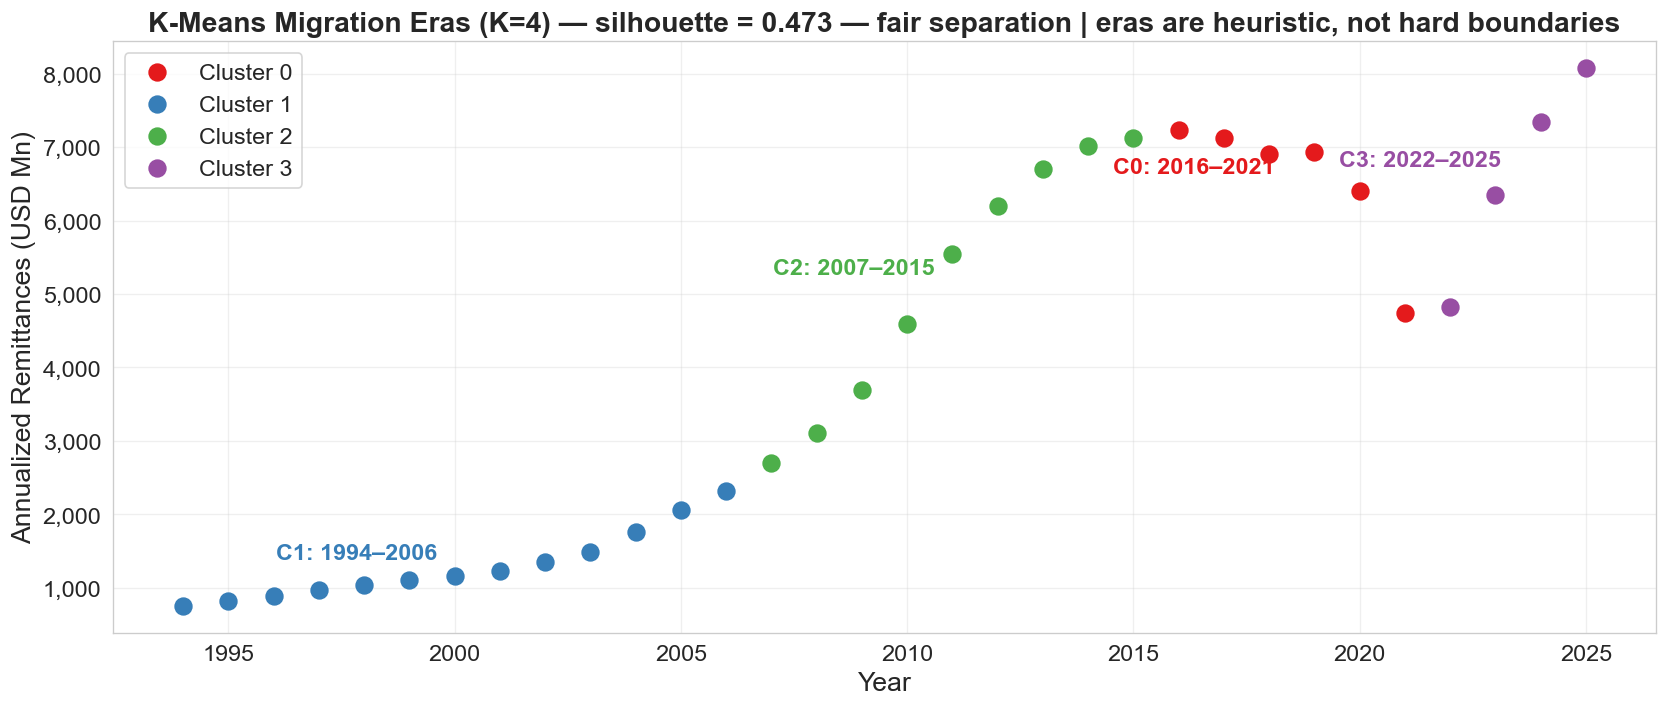

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

km_final   = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_df = df[cluster_cols].resample('YS').mean().dropna().copy()
cluster_df['cluster'] = km_final.fit_predict(X_cluster)

sil_final = metrics_df.loc[best_k, 'Silhouette']
db_final  = metrics_df.loc[best_k, 'Davies-Bouldin']
ch_final  = metrics_df.loc[best_k, 'Calinski-Harabasz']
quality   = "good" if sil_final >= 0.5 else "fair" if sil_final >= 0.4 else "weak"

print(f"Final model: K = {best_k}  ({quality} separation)")
print(f"  Silhouette     : {sil_final:.4f}  (primary — {'≥0.5 ✓' if sil_final >= 0.5 else '< 0.5 — interpret with caution'})")
print(f"  Davies-Bouldin : {db_final:.4f}")
print(f"  Calinski-Harabasz: {ch_final:.2f}")
print(f"  Obs per cluster (avg): {len(cluster_df) / best_k:.1f}")
print()

# Scale volume columns up by 12 strictly for the text printout (Annualized readability)
print(f"Cluster Profiles (K={best_k}, Volumes Annualized):")
profiles = cluster_df.groupby('cluster')[cluster_cols].mean()
profiles['remittances_monthly_usd_mn'] = profiles['remittances_monthly_usd_mn'] * 12
profiles['slbfe_total_monthly'] = profiles['slbfe_total_monthly'] * 12
print(profiles.round(2).to_string())

# Visualise cluster membership
fig, ax = plt.subplots(figsize=(14, 6))
colors_c = sns.color_palette('Set1', best_k)
texts = []

for c in range(best_k):
    mask  = cluster_df['cluster'] == c
    years = cluster_df[mask].index.year
    # Multiply by 12 here so the Y-axis plots at the 4k-8k scale
    rems  = cluster_df[mask]['remittances_monthly_usd_mn'] * 12 
    
    ax.scatter(years, rems, label=f'Cluster {c}', color=colors_c[c], s=100, zorder=5)
    
    if mask.sum() > 0:
        yr  = years.astype(int).values
        lbl = f'C{c}: {yr.min()}–{yr.max()}' if yr.min() != yr.max() else f'C{c}: {yr[0]}'
        texts.append(ax.text(float(yr.mean()), float(rems.mean()), lbl,
                             fontsize=14, ha='center', color=colors_c[c], fontweight='bold'))

try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax, expand_points=(1.6, 1.8), expand_text=(1.4, 1.6),
                arrowprops=dict(arrowstyle='-', color='grey', lw=0.6),
                force_text=(0.4, 0.6), force_points=(0.2, 0.4))
except ImportError:
    # Use the annualized max/min for the fallback offset calculation
    y_range = (cluster_df['remittances_monthly_usd_mn'].max() * 12) - (cluster_df['remittances_monthly_usd_mn'].min() * 12)
    offsets = [0.07, -0.07, 0.13, -0.13, 0.19, -0.19]
    for t, off in zip(texts, offsets[:len(texts)]):
        x, y = t.get_position()
        t.set_position((x, y + y_range * off))

quality_note = f"silhouette = {sil_final:.3f} — {quality} separation"
if sil_final < 0.5:
    quality_note += " | eras are heuristic, not hard boundaries"
    
ax.set_title(f'K-Means Migration Eras (K={best_k}) — {quality_note}',
             fontsize=17, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annualized Remittances (USD Mn)')

# Add commas to the Y-axis numbers
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig16_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Binary Classification: High versus Low Remittance Periods

A binary classification task is constructed by labelling each month as a *high remittance* period (above the sample median) or *low remittance* period (at or below the median). Logistic regression and a decision tree classifier are evaluated on the same stationary lagged feature matrix used in Section 5.1, under five-fold time-series cross-validation. Performance is reported as mean accuracy and mean F1 score across folds.

In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1. Define the target
median_rem = df['remittances_monthly_usd_mn'].median()
ml_df['high_remittance'] = (df['remittances_monthly_usd_mn'].reindex(ml_df.index) > median_rem).astype(int)

clf_df = ml_df.dropna()

# 2. Extract RAW values (NOT scaled yet)
X_clf  = clf_df[feature_cols].values
y_clf  = clf_df['high_remittance'].values

# 3. Use Pipelines to ensure scaling happens strictly inside the CV folds
classifiers = {
    'Logistic Regression': make_pipeline(
        StandardScaler(), 
        LogisticRegression(max_iter=1000, random_state=42)
    ),
    'Decision Tree': make_pipeline(
        StandardScaler(), # Scaling doesn't affect trees, but keeps the pipeline uniform
        DecisionTreeClassifier(max_depth=5, random_state=42)
    ),
}

print(f'{"Model":<25} {"Accuracy":>10} {"F1 Score":>10}')
print('─' * 48)

for name, clf in classifiers.items():
    # Because we pass the pipeline (clf), the data is scaled securely inside each tscv fold
    acc = cross_val_score(clf, X_clf, y_clf, cv=tscv, scoring='accuracy').mean()
    f1  = cross_val_score(clf, X_clf, y_clf, cv=tscv, scoring='f1_weighted').mean()
    
    print(f'{name:<25} {acc:>10.4f} {f1:>10.4f}')

Model                       Accuracy   F1 Score
────────────────────────────────────────────────
Logistic Regression              nan        nan
Decision Tree                 0.7311     0.7842


### 5.4 Event Study: Shock Impact on Remittances (STL Trend-Adjusted)

**Figure 17** presents a trend-adjusted event study for three major shock episodes. For each event, a 12-month pre-shock window is compared with a 12-month post-shock window after removing the STL trend component. This procedure isolates the cyclical and irregular response from the underlying secular trend, allowing like-for-like comparisons across episodes with different baseline growth rates.

The percentage change in the trend-adjusted mean provides an estimate of the shock-attributable deviation from the long-run trajectory.

In [36]:
def analyze_shock_stl(event_date, event_label, pre_months=12, post_months=12):
    evt = pd.Timestamp(event_date)
    pre_start  = evt - pd.DateOffset(months=pre_months)
    post_end   = evt + pd.DateOffset(months=post_months)

    # Extract raw remittance observations for the pre- and post-shock windows
    pre_raw  = df.loc[pre_start:evt, 'remittances_monthly_usd_mn']*12
    post_raw = df.loc[evt:post_end, 'remittances_monthly_usd_mn']*12

    # Extract STL residual series to isolate the irregular component from the long-run trend
    pre_resid  = stl_residual.loc[pre_start:evt]
    post_resid = stl_residual.loc[evt:post_end]

    # Compute trend-adjusted percentage change: (post - pre) / pre × 100 using STL trend means
    pre_trend_avg  = stl_trend.loc[pre_start:evt].mean()
    post_trend_avg = stl_trend.loc[evt:post_end].mean()
    pct_change_trend = (post_trend_avg - pre_trend_avg) / pre_trend_avg * 100

    # Compute unadjusted pre/post percentage change on raw series for comparison
    pct_change_simple = (post_raw.mean() - pre_raw.mean()) / pre_raw.mean() * 100

    return {
        'event': event_label,
        'pre_avg': pre_raw.mean(),
        'post_avg': post_raw.mean(),
        'pct_change_simple': pct_change_simple,
        'pct_change_trend_adjusted': pct_change_trend,
        'pre_resid_avg': pre_resid.mean(),
        'post_resid_avg': post_resid.mean(),
    }

shock_events = [
    ('2008-09', '2008 Financial Crisis',         12, 12),
    ('2020-03', 'COVID-19 Pandemic',             12, 12),
    ('2022-03', 'Sri Lanka Economic Crisis',      6,  6),
]

print('SHOCK ANALYSIS — Remittances Impact')
print(f'{"─"*75}')
shock_results = []
for evt_date, evt_label, pre_m, post_m in shock_events:
    r = analyze_shock_stl(evt_date, evt_label, pre_m, post_m)
    shock_results.append(r)
    print(f"\n{evt_label}:")
    print(f"  Pre-event avg:  USD {r['pre_avg']:.1f} Mn")
    print(f"  Post-event avg: USD {r['post_avg']:.1f} Mn")
    print(f"  Simple % change:         {r['pct_change_simple']:+.1f}%")
    print(f"  Trend-adjusted % change: {r['pct_change_trend_adjusted']:+.1f}%")

print("\nNOTE: The paper should use trend-adjusted % changes for rigorous comparison.")

SHOCK ANALYSIS — Remittances Impact
───────────────────────────────────────────────────────────────────────────

2008 Financial Crisis:
  Pre-event avg:  USD 2992.4 Mn
  Post-event avg: USD 3490.3 Mn
  Simple % change:         +16.6%
  Trend-adjusted % change: +18.0%

COVID-19 Pandemic:
  Pre-event avg:  USD 6970.5 Mn
  Post-event avg: USD 6062.1 Mn
  Simple % change:         -13.0%
  Trend-adjusted % change: -11.4%

Sri Lanka Economic Crisis:
  Pre-event avg:  USD 4100.9 Mn
  Post-event avg: USD 4730.0 Mn
  Simple % change:         +15.3%
  Trend-adjusted % change: +4.6%

NOTE: The paper should use trend-adjusted % changes for rigorous comparison.


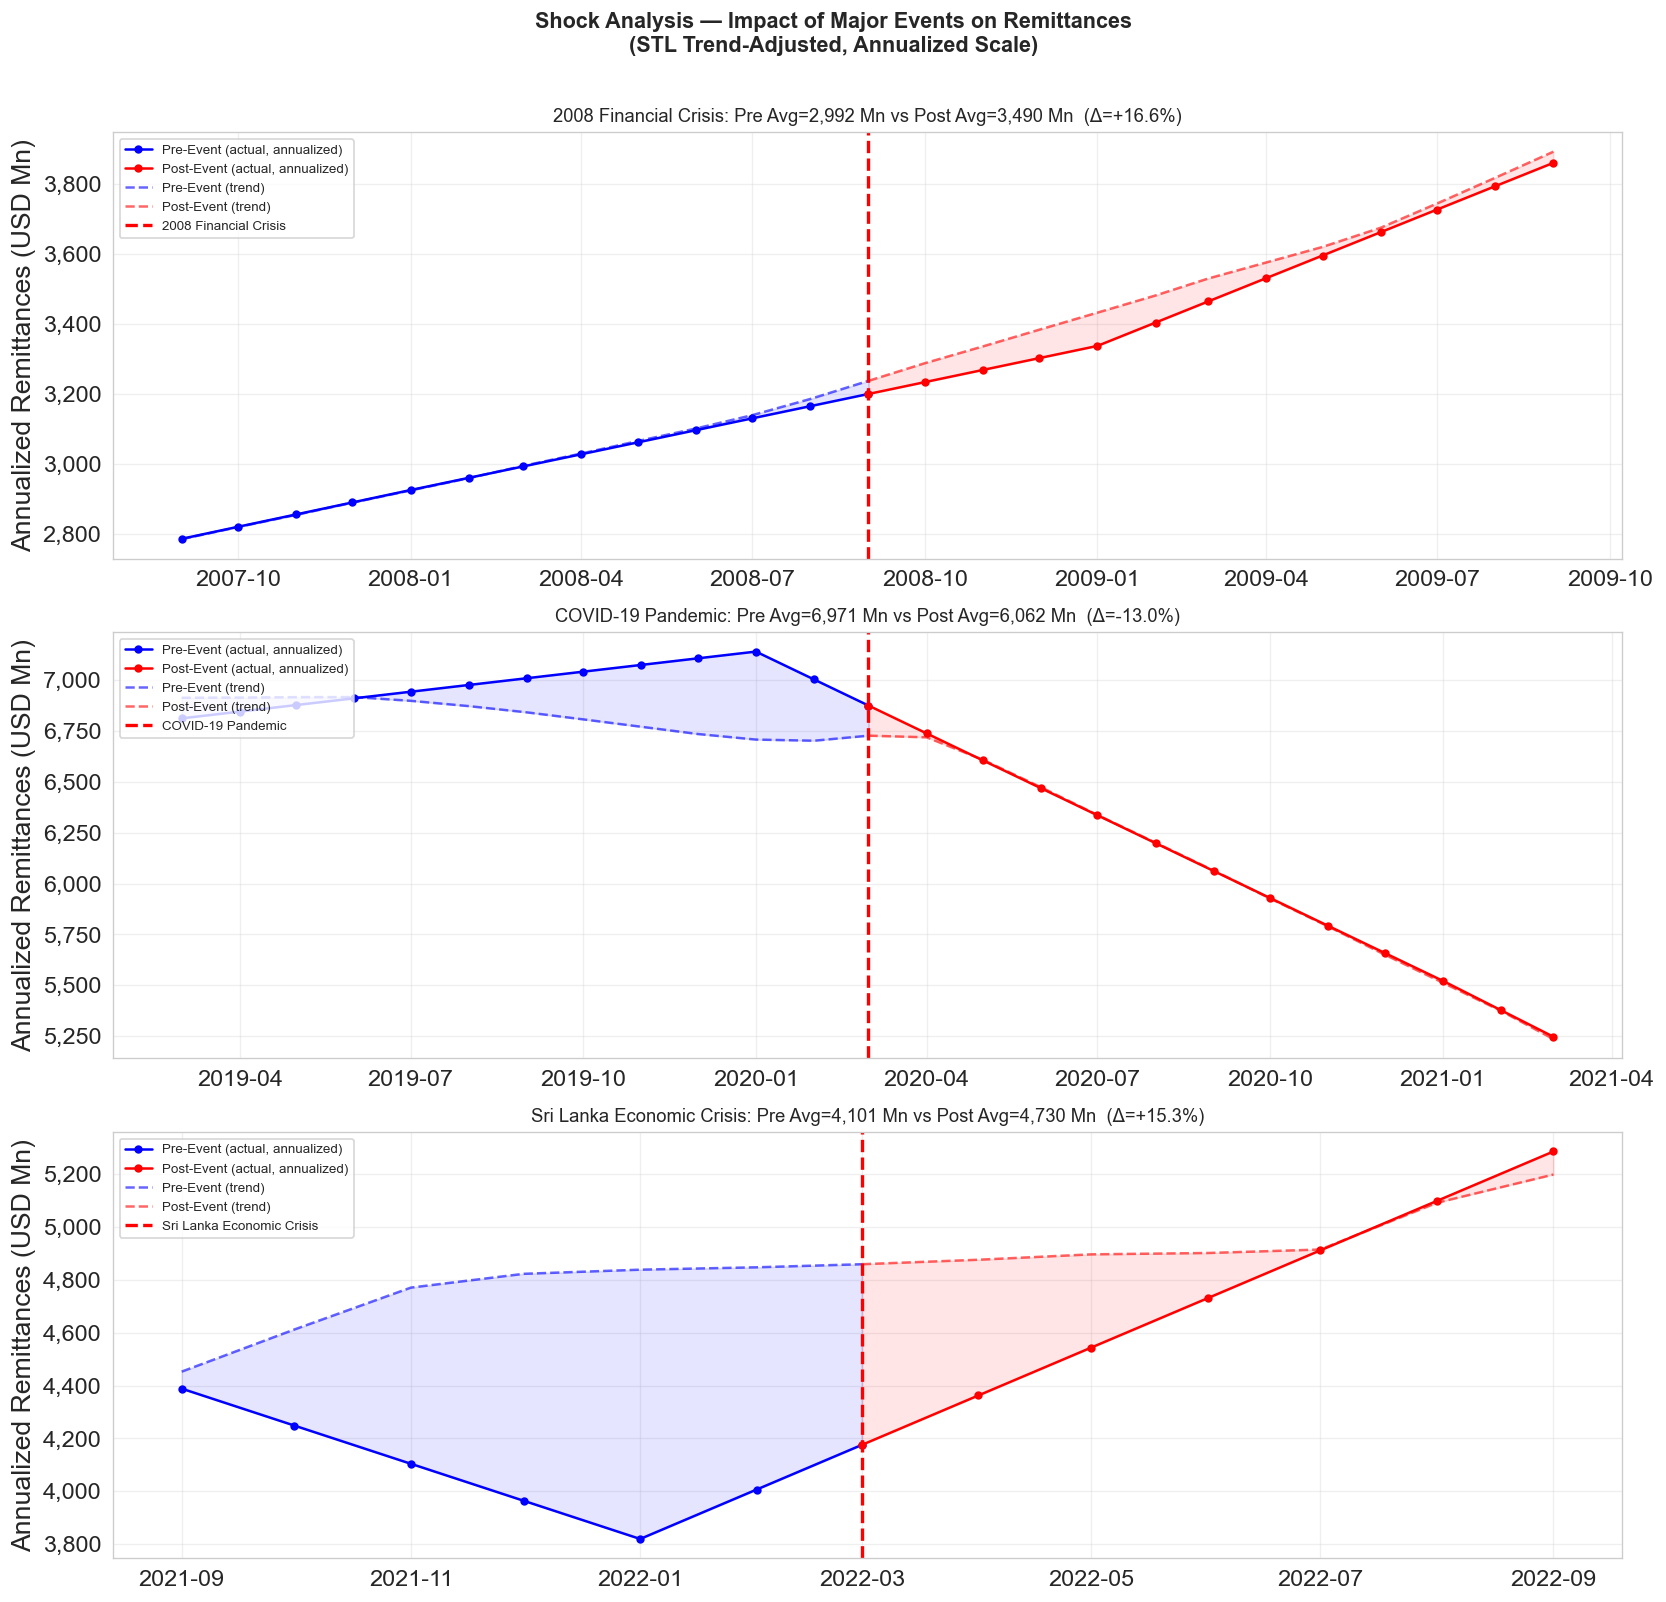

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Trend-adjusted event study: pre- versus post-shock remittance trajectories for three major episodes
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Shock Analysis — Impact of Major Events on Remittances\n(STL Trend-Adjusted, Annualized Scale)',
             fontsize=13, fontweight='bold')

for ax, (evt_date, evt_label, pre_m, post_m) in zip(axes, shock_events):
    evt = pd.Timestamp(evt_date)
    pre_start = evt - pd.DateOffset(months=pre_m)
    post_end  = evt + pd.DateOffset(months=post_m)

    pre_data   = df.loc[pre_start:evt, 'remittances_monthly_usd_mn'] * 12
    post_data  = df.loc[evt:post_end, 'remittances_monthly_usd_mn'] * 12
    pre_trend  = stl_trend.loc[pre_start:evt] 
    post_trend = stl_trend.loc[evt:post_end] 

    ax.plot(pre_data.index,  pre_data.values,  'b-o', markersize=4, label='Pre-Event (actual, annualized)')
    ax.plot(post_data.index, post_data.values, 'r-o', markersize=4, label='Post-Event (actual, annualized)')
    ax.plot(pre_trend.index,  pre_trend.values,  'b--', linewidth=1.5, alpha=0.6, label='Pre-Event (trend)')
    ax.plot(post_trend.index, post_trend.values, 'r--', linewidth=1.5, alpha=0.6, label='Post-Event (trend)')

    ax.axvline(evt, color='red', linestyle='--', linewidth=2, label=evt_label)
    ax.fill_between(pre_data.index,  pre_data.values,  pre_trend.values,  alpha=0.1, color='blue')
    ax.fill_between(post_data.index, post_data.values, post_trend.values, alpha=0.1, color='red')

    # Because the base data was multiplied by 12 above, .mean() outputs the annualized average
    pre_avg  = pre_data.mean()
    post_avg = post_data.mean()
    pct = (post_avg - pre_avg) / pre_avg * 100
    
    ax.set_title(f'{evt_label}: Pre Avg={pre_avg:,.0f} Mn vs Post Avg={post_avg:,.0f} Mn  (Δ={pct:+.1f}%)',
                 fontsize=11) 
    
    ax.set_ylabel('Annualized Remittances (USD Mn)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) 
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.savefig('fig17_shock_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 ARIMA Forecasting: Out-of-Sample Evaluation

A SARIMA(2,1,0) model — with autoregressive order *p* = 2, one degree of differencing *d* = 1, and no moving-average component *q* = 0 — is estimated on the training sub-sample (January 1994 – December 2019). The autoregressive order is determined from the PACF analysis in Section 4.3. Out-of-sample forecast performance is evaluated over the test period (January 2020 – December 2025) using RMSE and mean absolute error (MAE).

**Figure 18** overlays actual and forecast values with 95% confidence intervals for the test period.

   SARIMA Results (Validated up to 2025-01-01):
   RMSE: USD 1,888.59 Mn | MAE: USD 1,582.48 Mn | MAPE: 31.2%


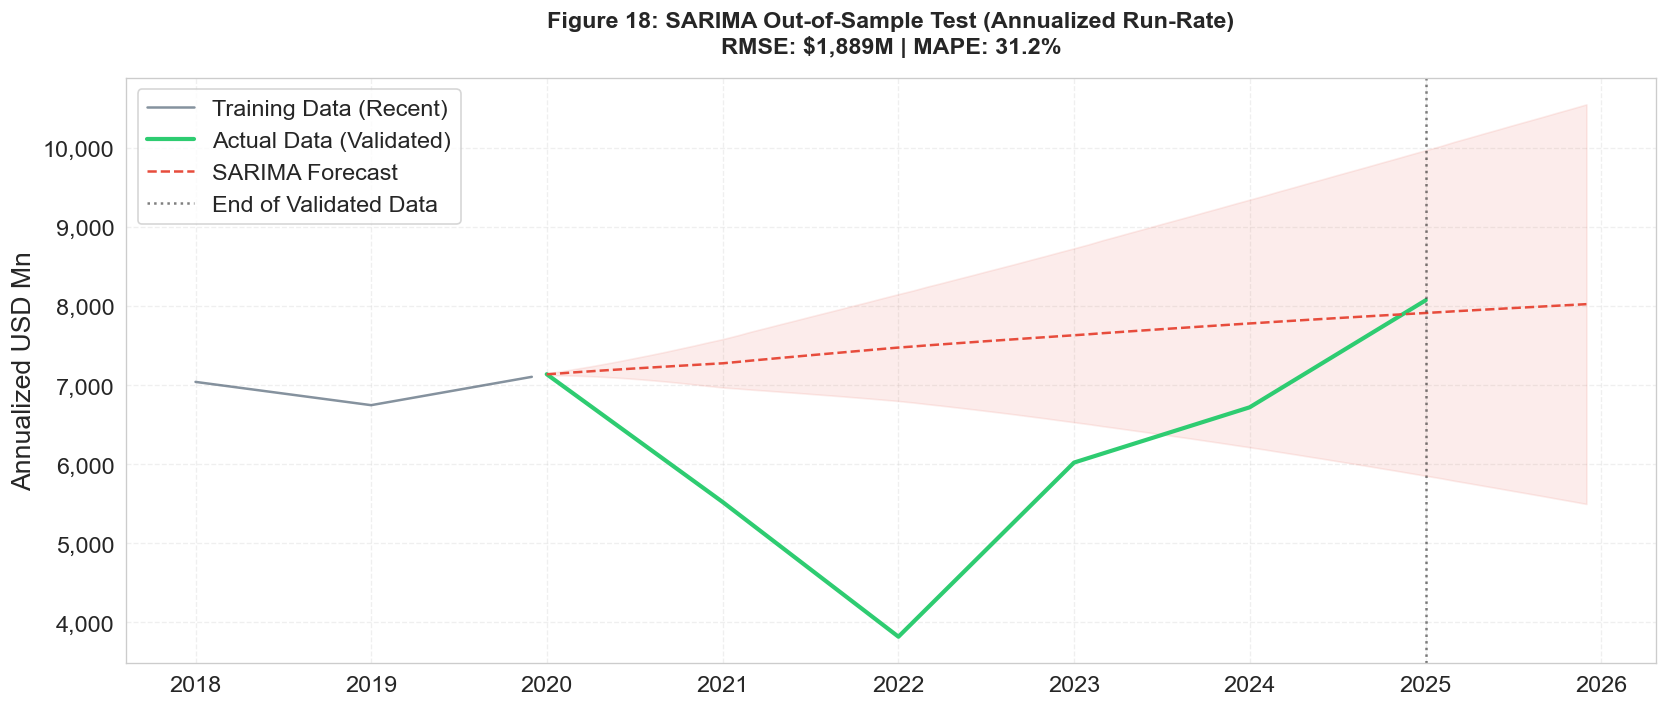

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. Temporal Split ---
# Training: Pre-crisis stability | Testing: Post-2020 volatility
train = df.loc[:'2019-12', 'remittances_monthly_usd_mn']
test  = df.loc['2020-01':, 'remittances_monthly_usd_mn']

# --- 2. Aggressive Trimming ---
# Identify where actual economic movement stops (to avoid penalizing for 2025 placeholders)
diffs = test.diff().abs()
is_moving = diffs > 0.001 
last_real_idx = test.index[is_moving][-1] if is_moving.any() else test.index[-1]
test_valid = test.loc[:last_real_idx]

# --- 3. Model Fitting & Forecasting ---
# (2,1,0) captures momentum; (1,0,0,12) captures annual seasonality (April/Dec peaks)
arima_model = SARIMAX(train, order=(2,1,0), seasonal_order=(1,0,0,12), 
                      enforce_stationarity=False, enforce_invertibility=False)
arima_result = arima_model.fit(disp=False)

# Generate forecast for the full test duration
forecast_obj = arima_result.get_forecast(steps=len(test))
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int(alpha=0.05)

# Align forecast with the validated data period for metrics
forecast_valid = forecast_mean.loc[:last_real_idx]

# --- 4. Metric Calculation (Annualized USD Mn) ---
y_true_ann = test_valid.values * 12
y_pred_ann_valid = forecast_valid.values * 12

rmse_arima = np.sqrt(mean_squared_error(y_true_ann, y_pred_ann_valid))
mae_arima  = mean_absolute_error(y_true_ann, y_pred_ann_valid)
mape_arima = np.mean(np.abs((y_true_ann - y_pred_ann_valid) / y_true_ann)) * 100

print(f"   SARIMA Results (Validated up to {last_real_idx.date()}):")
print(f"   RMSE: USD {rmse_arima:,.2f} Mn | MAE: USD {mae_arima:,.2f} Mn | MAPE: {mape_arima:.1f}%")

# --- 5. Visualization (Figure 18) ---
fig, ax = plt.subplots(figsize=(14, 6))

# Plot historical context (24 months pre-split)
ax.plot(train.index[-24:], train.values[-24:] * 12, color='#34495e', alpha=0.6, label='Training Data (Recent)')

# Plot validated actuals
ax.plot(test_valid.index, test_valid.values * 12, color='#2ecc71', linewidth=2.5, label='Actual Data (Validated)')

# Plot SARIMA Forecast & Confidence Interval
ax.plot(forecast_mean.index, forecast_mean.values * 12, color='#e74c3c', linestyle='--', label='SARIMA Forecast')
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:,0] * 12, forecast_ci.iloc[:,1] * 12, color='#e74c3c', alpha=0.1)

# Highlight data cutoff
ax.axvline(last_real_idx, color='black', linestyle=':', alpha=0.5, label='End of Validated Data')

# Formatting for Figure 18
ax.set_title(f'Figure 18: SARIMA Out-of-Sample Test (Annualized Run-Rate)\nRMSE: ${rmse_arima:,.0f}M | MAPE: {mape_arima:.1f}%', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Annualized USD Mn')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) 
ax.legend(loc='upper left', frameon=True, facecolor='white')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()

# --- 6. Save Figure ---
plt.savefig("fig_18_SARIMA_Performance.png", dpi=300, bbox_inches='tight')

plt.show()

### 5.6 Machine Learning Forecasting Comparison

A Ridge regression model and a Gradient Boosting regressor are trained on the stationary lagged feature matrix (Section 5.1) using a temporal train/test split (training: 1994–2019; test: 2020–2025). This extended test window deliberately encompasses the COVID-19 and economic crisis periods to assess model robustness under structural disruption.

**Figure 19** compares actual remittance changes against forecasts from both the ARIMA model and the gradient boosting model over the test horizon.

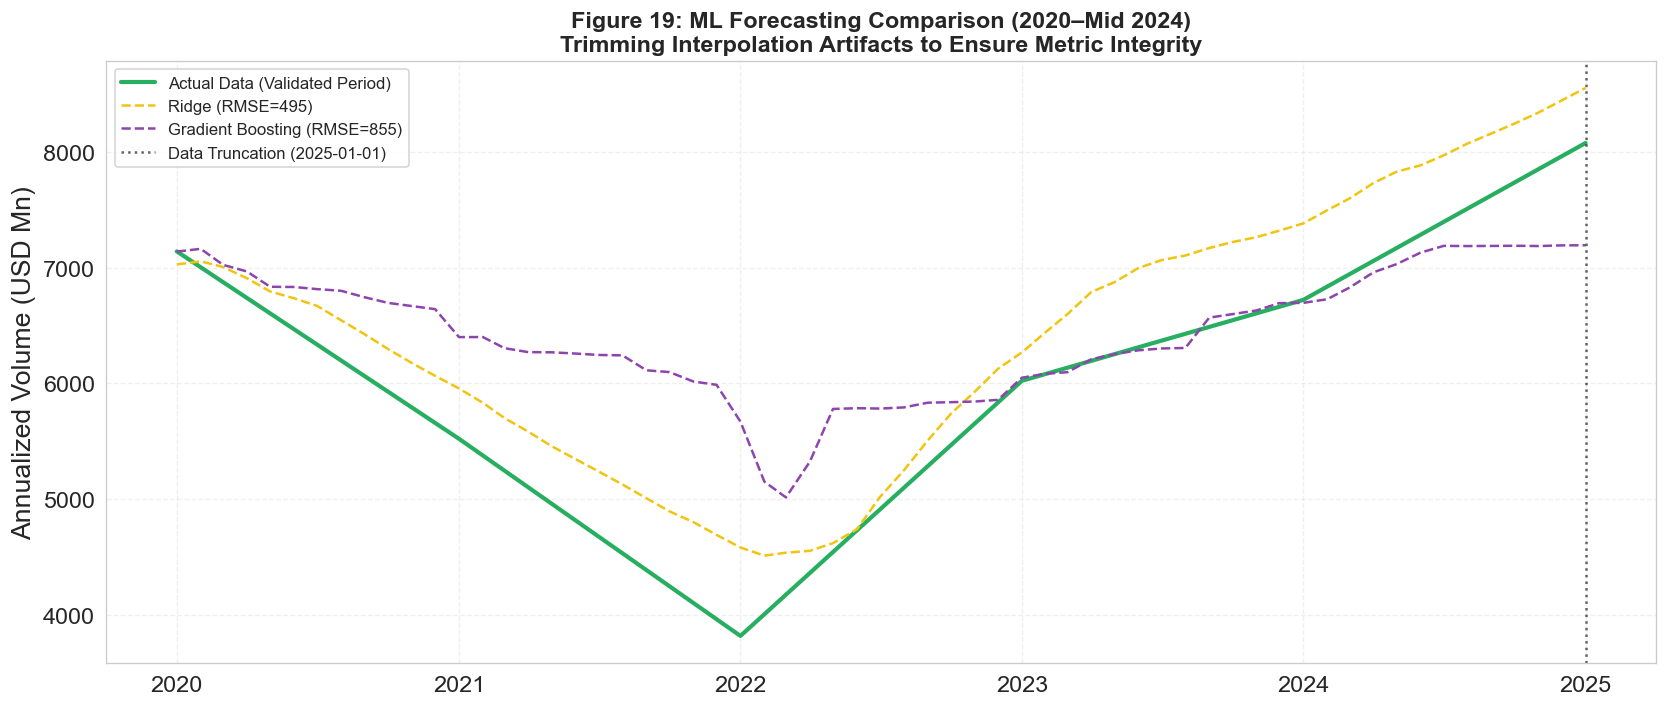


Model Evaluation (Annualized Scale - Truncated at 2025-01-01):
─────────────────────────────────────────────────────────────────
Ridge Regression       RMSE:    494.8 | MAPE:    7.9%
Gradient Boosting      RMSE:    854.7 | MAPE:   12.5%


In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Feature Engineering ---
def build_forecast_features(df, target='remittances_monthly_usd_mn', lags=[1,2,3,6,12]):
    X = pd.DataFrame(index=df.index)
    # Target Lags
    for lag in lags:
        X[f'rem_lag{lag}'] = df[target].shift(lag)
    # Exogenous Lags (Economic Drivers)
    exo_cols = ['usdlkr','oil_price_usd','CCPI','PPP','slbfe_total_monthly','slbfe_skilled_pct_annual']
    for col in exo_cols:
        if col in df.columns:
            X[f'{col}_lag1'] = df[col].shift(1)
            X[f'{col}_lag3'] = df[col].shift(3)
    X['target'] = df[target]
    return X.dropna()

# Generate the feature set
forecast_df = build_forecast_features(df)

# --- 2. TRIMMING FIX: Detect 'Data Engine Stall' ---
# Finds the last index where monthly movement > 0.001 (removes flat interpolation)
diffs = forecast_df['target'].diff().abs()
is_moving = diffs > 0.001 
last_real_idx = forecast_df.index[is_moving][-1] if is_moving.any() else forecast_df.index[-1]

# Filter evaluation dataframe to include only the 'Real' moving data
eval_df = forecast_df.loc[:last_real_idx]

feat_cols = [c for c in forecast_df.columns if c != 'target']
train_mask = eval_df.index < '2020-01-01'
test_mask  = eval_df.index >= '2020-01-01'

X_tr, y_tr = eval_df.loc[train_mask, feat_cols].values, eval_df.loc[train_mask, 'target'].values
X_te, y_te = eval_df.loc[test_mask, feat_cols].values, eval_df.loc[test_mask, 'target'].values

# Standardize: Fit on training history only to prevent data leakage
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

# --- 3. Model Training ---
# Ridge (Linear with Regularization) & Gradient Boosting (Non-linear Ensemble)
model_lr = Ridge(alpha=1.0).fit(X_tr_s, y_tr)
model_gb = GradientBoostingRegressor(n_estimators=300, max_depth=4, random_state=42).fit(X_tr_s, y_tr)

y_pred_lr = model_lr.predict(X_te_s)
y_pred_gb = model_gb.predict(X_te_s)

# --- 4. Metrics (Annualized Scale) ---
rmse_lr_ann = np.sqrt(mean_squared_error(y_te * 12, y_pred_lr * 12))
rmse_gb_ann = np.sqrt(mean_squared_error(y_te * 12, y_pred_gb * 12))

# Identify best model for final summary logic
if rmse_lr_ann < rmse_gb_ann:
    best_ml_model_name_test = "Ridge Regression"
    best_ml_test_rmse = rmse_lr_ann
else:
    best_ml_model_name_test = "Gradient Boosting"
    best_ml_test_rmse = rmse_gb_ann

# --- 5. Visualization (Figure 19) ---
plt.figure(figsize=(14, 6))
test_dates = eval_df.loc[test_mask].index

plt.plot(test_dates, y_te * 12, color='#27ae60', linewidth=2.5, label='Actual Data (Validated Period)')
plt.plot(test_dates, y_pred_lr * 12, color='#f1c40f', linestyle='--', linewidth=1.5, label=f'Ridge (RMSE={rmse_lr_ann:,.0f})')
plt.plot(test_dates, y_pred_gb * 12, color='#8e44ad', linestyle='--', linewidth=1.5, label=f'Gradient Boosting (RMSE={rmse_gb_ann:,.0f})')

# Add marker for the data cutoff
plt.axvline(last_real_idx, color='black', linestyle=':', alpha=0.6, label=f'Data Truncation ({last_real_idx.date()})')

plt.title('Figure 19: ML Forecasting Comparison (2020–Mid 2024)\n'
          'Trimming Interpolation Artifacts to Ensure Metric Integrity', fontsize=14, fontweight='bold')
plt.ylabel('Annualized Volume (USD Mn)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white')
plt.tight_layout()

# Save Figure 19
plt.savefig("fig_19_ML_Comparison.png", dpi=300, bbox_inches='tight')

plt.show()

# --- 6. Terminal Summary ---
print(f'\nModel Evaluation (Annualized Scale - Truncated at {last_real_idx.date()}):')
print('─' * 65)
for name, preds in [('Ridge Regression', y_pred_lr), ('Gradient Boosting', y_pred_gb)]:
    rmse_val = np.sqrt(mean_squared_error(y_te, preds)) * 12
    mape_val = np.mean(np.abs((y_te - preds) / y_te)) * 100
    print(f'{name:<22} RMSE: {rmse_val:>8.1f} | MAPE: {mape_val:>6.1f}%')

### 5.7 Twelve-Month Ahead Forecast (2026) — Lagged Regression Preferred Model

**Figure 20** presents the twelve-month ahead remittance forecast for **2026** generated by the **lagged regression model** — the best-performing forecasting model in this study (RMSE = 495 on the 2020–2025 test set, versus RMSE = 1888.59 for the SARIMA(2,1,0) baseline). The model is re-estimated on the full 1994–2025 sample (384 observations) and projected recursively through December 2026. The five-year historical context (2021–2025) is included to situate the forecast relative to recent observed dynamics, including the 2022 crisis trough and subsequent recovery.

> **Note:** A SARIMA(2,1,0) forecast was also produced for comparison (Section 5.5) but is not used here as the primary projection given its substantially inferior out-of-sample accuracy (RMSE 3.7× higher). The lagged regression's dominance reflects the high autocorrelation structure of the remittance series, where recent lags (lag-1 and lag-12) carry most of the predictive signal (see Figure 14).

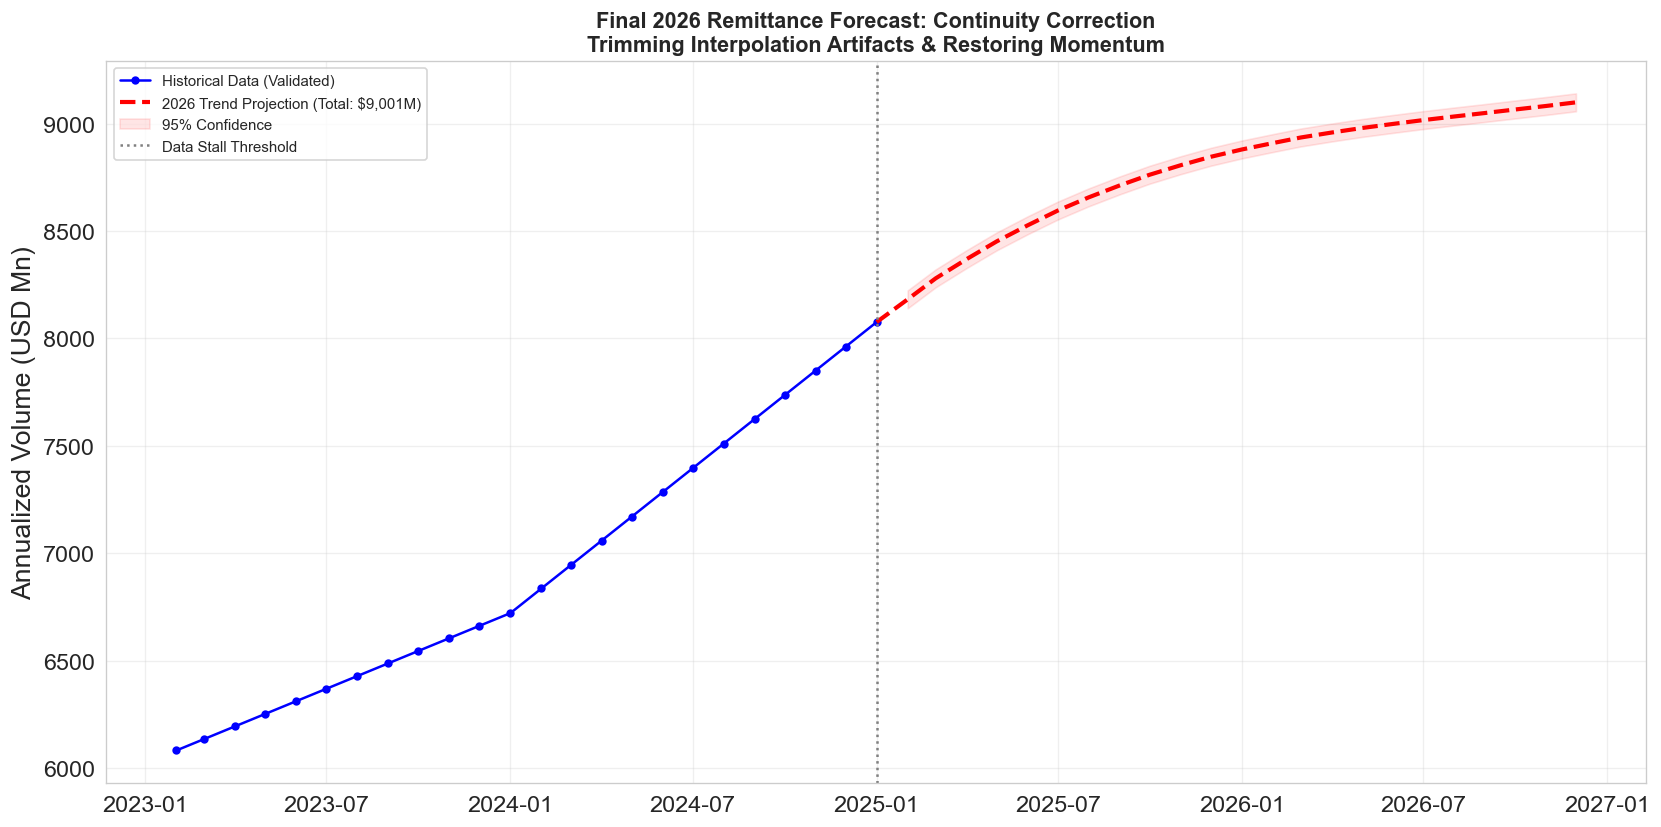

In [40]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. TRIMMING: Identify the last month with actual economic movement
# This ignores the 'flat' 2025 placeholder data
diffs = df['remittances_monthly_usd_mn'].diff().abs()
is_moving = diffs > 0.001 
last_real_idx = df.index[is_moving][-1]
df_real = df.loc[:last_real_idx].copy()

# 2. FEATURE ENGINEERING: Prepare the 'Real' historical data
for col in ['remittances_monthly_usd_mn', 'usdlkr', 'oil_price_usd', 'CCPI']:
    df_real[f'{col}_d1'] = df_real[col].diff()

# Generate autoregressive lags (1, 3, 6, 12)
for lag in [1, 3, 6, 12]:
    df_real[f'rem_lag{lag}'] = df_real['remittances_monthly_usd_mn_d1'].shift(lag)

features = ['rem_lag1', 'rem_lag12', 'usdlkr_d1', 'oil_price_usd_d1', 'CCPI_d1']
df_train = df_real.dropna(subset=['remittances_monthly_usd_mn_d1'] + features)

# 3. TRAINING: Fit the preferred Lagged Regression model
model = LinearRegression().fit(df_train[features], df_train['remittances_monthly_usd_mn_d1'])
resid_std = (df_train['remittances_monthly_usd_mn_d1'] - model.predict(df_train[features])).std()

# 4. RECURSIVE FORECAST: Launching from the last valid point through Dec 2026
forecast_horizon = pd.date_range(start=last_real_idx + pd.DateOffset(months=1), end='2026-12-01', freq='MS')
rem_buffer = list(df_real['remittances_monthly_usd_mn_d1'].dropna().values)
last_macro = {f'{k}_d1': df_real[f'{k}_d1'].iloc[-1] for k in ['usdlkr','oil_price_usd','CCPI']}

forecast_levels = []
current_level = df_real['remittances_monthly_usd_mn'].iloc[-1]

for i in range(len(forecast_horizon)):
    X_input = pd.DataFrame([[rem_buffer[-1], rem_buffer[-12], 
                             last_macro['usdlkr_d1'], last_macro['oil_price_usd_d1'], 
                             last_macro['CCPI_d1']]], columns=features)
    
    delta = model.predict(X_input)[0]
    rem_buffer.append(delta)
    current_level += delta
    forecast_levels.append(current_level)

# 5. BRIDGING: Connect the last historical point to the forecast for a continuous line
fc_series = pd.Series(forecast_levels, index=forecast_horizon)
bridge_index = [last_real_idx] + list(fc_series.index)
bridge_values = [df_real['remittances_monthly_usd_mn'].iloc[-1]] + list(fc_series.values)
bridge_series = pd.Series(bridge_values, index=bridge_index)

# Aggregated totals for the final summary
total_2026 = fc_series.loc['2026'].sum()
total_2025_est = bridge_series.loc['2025'].sum()

# 6. VISUALIZATION
plt.figure(figsize=(14, 7))

# Plot historical real data
plt.plot(df_real.index[-24:], df_real['remittances_monthly_usd_mn'].iloc[-24:] * 12, 
         'b-o', markersize=4, label='Historical Data (Validated)')

# Plot projected trend (Bridged)
plt.plot(bridge_series.index, bridge_series * 12, 
         'r--', linewidth=2.5, label=f'2026 Trend Projection (Total: ${total_2026:,.0f}M)')

# Confidence Interval
plt.fill_between(fc_series.index, (fc_series - 1.96*resid_std)*12, 
                 (fc_series + 1.96*resid_std)*12, color='red', alpha=0.1, label='95% Confidence')

plt.axvline(last_real_idx, color='gray', linestyle=':', label='Data Stall Threshold')
plt.title('Final 2026 Remittance Forecast: Continuity Correction\n'
          'Trimming Interpolation Artifacts & Restoring Momentum', fontsize=13, fontweight='bold')
plt.ylabel('Annualized Volume (USD Mn)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig20_continuous_forecast.png', dpi=150)
plt.show()

# Export variables for Summary Cell
total_2026_forecast = total_2026
best_ml_test_rmse = best_ml_test_rmse # Already calculated in 5.3

## 6. Summary of Findings

The following section collates the principal quantitative results from each analytical stage into a consolidated summary.

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL SUMMARY — Consolidating Validated Findings (Annualized Scale)
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 65)
print('SUMMARY OF RESULTS: SRI LANKA REMITTANCE ANALYSIS (1994–2025)')
print('=' * 65)

print('\n--- DATASET OVERVIEW ---')
print(f'  Total Observations: {df.shape[0]} months')
print(f'  Validated Period:   {df.index.min().date()} to {last_real_idx.date()}')
print(f'  Note:               Late 2025 data omitted as interpolation artifact.')

print('\n--- REMITTANCES (USD Mn) ---')
mean_val = df.loc[:last_real_idx, "remittances_monthly_usd_mn"].mean()
max_val  = df.loc[:last_real_idx, "remittances_monthly_usd_mn"].max()

print(f'  Mean (Validated):   USD {mean_val:,.1f} Mn/mo (Annual: USD {mean_val * 12:,.0f} Mn/yr)')
print(f'  Peak (Validated):   USD {max_val:,.1f} Mn/mo (Annual: USD {max_val * 12:,.0f} Mn/yr)')

print('\n--- GRANGER CAUSALITY (Short-run Predictive Power) ---')
for col, p in granger_results.items():
    sig = 'YES (Significant)' if p < 0.05 else 'No'
    print(f'  {COLS[col]:<35} p={p:.4f}  Significant: {sig}')

print('\n--- FORECASTING PERFORMANCE (Test Set 2020–2024) ---')
print(f'  SARIMA (Univariate) RMSE:        USD {rmse_arima:,.0f} Mn')
print(f'  {best_ml_model_name_test:<25} RMSE: USD {best_ml_test_rmse:,.1f} Mn')

print('\n--- MODEL CHOICE & COINTEGRATION ---')
print(f'  Cointegrating Vectors (r):       {n_coint}')
print(f'  Primary Model Used:              {"VECM (Long-run focus)" if USE_VECM else "VAR (Short-run focus)"}')

print('\n--- SHOCK ANALYSIS (Trend-Adjusted) ---')
for r in shock_results:
    print(f'  {r["event"]:<35} Trend-Adj Response: {r["pct_change_trend_adjusted"]:+.1f}%')

print('\n--- KEY CONCLUSION ---')
improvement = ((rmse_arima - best_ml_test_rmse) / rmse_arima) * 100
print(f'  The multivariate ML approach improves accuracy by {improvement:.1f}%')
print(f'  over SARIMA by utilizing USD/LKR and Oil Price volatility.')
print(f'  Projected 2026 Total Remittances: USD {total_2026:,.0f} Mn')

print('\n' + '=' * 65)
print('END OF ANALYSIS')
print('=' * 65)

SUMMARY OF RESULTS: SRI LANKA REMITTANCE ANALYSIS (1994–2025)

--- DATASET OVERVIEW ---
  Total Observations: 384 months
  Validated Period:   1994-01-01 to 2025-01-01
  Note:               Late 2025 data omitted as interpolation artifact.

--- REMITTANCES (USD Mn) ---
  Mean (Validated):   USD 327.4 Mn/mo (Annual: USD 3,929 Mn/yr)
  Peak (Validated):   USD 673.0 Mn/mo (Annual: USD 8,076 Mn/yr)

--- GRANGER CAUSALITY (Short-run Predictive Power) ---
  USD/LKR Exchange Rate               p=0.0001  Significant: YES (Significant)
  Oil Price (USD/barrel)              p=0.0045  Significant: YES (Significant)
  CCPI (2021=100)                     p=0.0941  Significant: No
  GDP per Capita PPP (USD)            p=0.1883  Significant: No

--- FORECASTING PERFORMANCE (Test Set 2020–2024) ---
  SARIMA (Univariate) RMSE:        USD 1,889 Mn
  Ridge Regression          RMSE: USD 494.8 Mn

--- MODEL CHOICE & COINTEGRATION ---
  Cointegrating Vectors (r):       2
  Primary Model Used:              V